In [1]:
print('导入所需的库')
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import sys
import gc
import rasterio
import geopandas as gpd
import netCDF4 as nc
from matplotlib.colors import BoundaryNorm, ListedColormap
from rasterio.enums import Resampling
import numpy as np
import matplotlib.font_manager as fm
from rasterio.features import geometry_mask
from rasterio.mask import mask
import pandas as pd
from scipy.stats import pearsonr
import threading
from tqdm import tqdm
import xarray as xr
from rasterio import Affine
from rasterio.crs import CRS
from scipy.stats import linregress
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import seaborn as sns
import statsmodels.api as sm
from scipy.signal import detrend
from statsmodels.tsa.stattools import adfuller
from osgeo import gdal
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
from matplotlib.cm import ScalarMappable
from scipy.stats import f
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from scipy.ndimage import zoom
import os
from pyhdf.SD import SD, SDC
import numpy as np
import rioxarray
import h5py

# 设置新罗马字体
plt.rcParams['font.family'] = 'Times New Roman'
%matplotlib tk

导入所需的库


In [2]:
print('导入自定义函数')
def generate_year_sequence(start_year, end_year):  #输入开始年，结束年，生成年度的序列
    year_sequence = []
    for year in range(start_year, end_year + 1):
        year_sequence.append(year)
    number_sequence = np.asarray(year_sequence)
    return number_sequence

def generate_date_sequence(start_year, start_month, end_year, end_month):  #输入开始的年份，月份，结束年份，月份，生成月度的序列
    start_date = pd.to_datetime(f"{start_year}-{start_month:02d}-01")
    end_date = pd.to_datetime(f"{end_year}-{end_month:02d}-01")
    next_month = end_date + pd.DateOffset(months=1)
    date_sequence = pd.date_range(start=start_date, end=next_month, freq='M')
    date_sequence=date_sequence.to_numpy()
    return date_sequence

def apply_boolean_mask(arr, mask):  #应用掩膜
    arr2 = arr.copy()  # 创建副本。防止arr原数组被篡改
    arr2[~mask] = np.nan 
    return arr2

def save_ok(array, file_name):  ## 保存函数。注意！！，这里一定要运行后面的读取LAI数据的代码，不然这里无法调用LAI的空间参考信息
    base_path = r'D:\BaiduSyncdisk\结果' #本地保存的基本路径
    output_path = f"{base_path}\\{file_name}.tif" # 绝对路径=基本路径+文件名+tiff后缀
    
    height, width = array.shape
    crs = LAI_year_025.rio.crs # 需要指定一个空间参考信息，这里使用了后面的LAI数据的空间参考信息
    transform = LAI_year_025.rio.transform()

    meta = {
        'driver': 'GTiff',
        'dtype': 'float32',
        'count': 1,
        'width': width,
        'height': height,
        'transform': transform,
        'crs': crs
    }

    with rasterio.open(output_path, 'w', **meta) as dst:
        dst.write(array, 1)
    print(f"{file_name}.tif 导出完成啦")

def swap_360_720(weidu,jingdu): #输入纬度，经度，转换为格网点坐标
    x=2*(90-weidu)
    y=2*(180+jingdu)
    return x,y

def swap_720_1440(weidu,jingdu): #输入纬度，经度，转换为格网点坐标
    x=4*(90-weidu)
    y=4*(180+jingdu)
    return x,y
def cal_MB(x):  # 计算一个变量的占用内存大小，单位是MB
    a=sys.getsizeof(x)/ (1024 * 1024) 
    return a
def moving_average(X, Y, window_size):    #分段平均函数,window_size是窗口大小
    # 确保输入的数列长度相同
    assert len(X) == len(Y), "X 和 Y 数列长度不一致"
    # 计算移动平均值
    averages_X = []
    averages_Y = []
    for i in range(0, len(X) - window_size + 1, window_size):
        window_X = X[i:i+window_size]
        window_Y = Y[i:i+window_size]
        average_X = sum(window_X) / window_size
        average_Y = sum(window_Y) / window_size
        averages_X.append(average_X)
        averages_Y.append(average_Y)
    return np.array(averages_X), np.array(averages_Y)

def jinhua(array1, array2): # 净化函数，只保留array1和array2中都有数值的地方。要求array1和array2都是一维数列
    result_array1 = np.where(np.isnan(array1) | np.isnan(array2), np.nan, array1)
    result_array2 = np.where(np.isnan(array1) | np.isnan(array2), np.nan, array2)
    result_array11 = result_array1[~np.isnan(result_array1)]
    result_array22 = result_array2[~np.isnan(result_array2)]
    return result_array11, result_array22

def sort_by_A(A, B): # 根据A的从小到大顺序，对B也进行排序，排序之前要使用净化函数！！！！！
    # 将数列 A 和 B 组合成元组列表，并按照 A 的值进行排序
    combined = sorted(zip(A, B), key=lambda x: x[0])
    # 解压排序后的元组列表，得到排序后的数列 A 和 B
    sorted_A, sorted_B = zip(*combined)
    return sorted_A, sorted_B

def split_array(arr):   #将一个数组一份为二,按照中位数一分为二
    mid = len(arr) // 2
    first_half = arr[:mid]
    second_half = arr[mid:]
    return first_half, second_half
def split_array_sorted(arr):    #将一个数组先进行排序，再按照中位数一分为二
    sorted_arr = sorted(arr)
    # 找到中位数的位置
    mid = len(sorted_arr) // 2
    # 将排序后的数组一分为二
    first_half = sorted_arr[:mid]
    second_half = sorted_arr[mid:]
    return first_half, second_half
def split_arrays_pro(A, B,filename):  # 选择单点，不分段平均，计算三种AI指标并绘图，有画图功能
    x1,y1=jinhua(A,B)
    X,Y=sort_by_A(x1, y1)
    mid_X = len(X) // 2
    x1 = X[:mid_X]
    x2 = X[mid_X:]
    # 找到Y数组的中位数位置
    mid_Y = len(Y) // 2
    y1 = Y[:mid_Y]
    y2 = Y[mid_Y:]
    slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
    slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
    slope3, intercept3 , r_value3, p_value3, std_err3 = linregress(X, Y)
    positive=np.max(y1)-np.mean(y1)
    negeative=np.mean(y1)-np.min(y1)
    
    # 确保 x1 x2,X 都是 NumPy 数组
    x1 = np.array(x1)
    x2 = np.array(x2)
    X = np.array(X)
    
    y1_new=x1*slope1+intercept1
    y2_new=x2*slope2+intercept2
    new_Y=X*slope3+intercept3
    
    A1=(slope2-slope1)/(slope2+slope1)
    B2=(r_value2-r_value1)/(r_value2+r_value1)
    C3=(positive-negeative)/(positive+negeative)
    
    fig, ax = plt.subplots()
    ax.scatter(x1, y1,s=200, alpha=0.25, color='#E64B35FF')
    ax.scatter(x2, y2, s=200, alpha=0.25, color='#4DBBD5FF')
    ax.plot(x1,y1_new, color='#E64B35FF',label=f'Arid slope:{slope1:.2f}   p_value: { p_value1:.2f} ')
    ax.plot(x2, y2_new, color='#4DBBD5FF',label=f'Humid slope:{slope2:.2f}   p_value: { p_value2:.2f}')
    ax.text( 0.06, 0.7, f'AI_slope: {A1:.2f}', transform=ax.transAxes)
    ax.text( 0.06, 0.6, f'AI_r: {B2:.2f}', transform=ax.transAxes)
    ax.text( 0.06, 0.5, f'AI_extreme: {C3:.2f}', transform=ax.transAxes)
    
    ax.set_title( f"{filename}")
    ax.set_xlabel('SAI_PR')
    ax.set_ylabel('SAI_NDVI')
    ax.legend(loc='upper left')
    plt.show()    
    return slope1,slope2, slope3

def split_arrays_ultra(A, B,filename):  # 选择8邻域，分段平均，计算三种AI指标并绘图，有画图功能
    x1,y1=jinhua(A,B)
    X,Y=sort_by_A(x1, y1)
    X,Y=moving_average(X,Y,len(X)//40)
    # 找到X数组的中位数位置
    mid_X = len(X) // 2
    x1 = X[:mid_X]
    x2 = X[mid_X:]

    # 找到Y数组的中位数位置
    mid_Y = len(Y) // 2
    y1 = Y[:mid_Y]
    y2 = Y[mid_Y:]
    
    slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
    slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
    slope3, intercept3 , r_value3, p_value3, std_err3 = linregress(X, Y)
    
    # 确保 x1 x2,X 都是 NumPy 数组
    x1 = np.array(x1)
    x2 = np.array(x2)
    X = np.array(X)
    
    y1_new=x1*slope1+intercept1
    y2_new=x2*slope2+intercept2
    new_Y=X*slope3+intercept3
    
    AI=(slope2-slope1)/(slope2+slope1)
    
    fig, ax = plt.subplots()
    ax.scatter(x1, y1,s=200, alpha=0.25, color='#E64B35FF')
    ax.scatter(x2, y2, s=200, alpha=0.25, color='#4DBBD5FF')
    ax.plot(x1,y1_new, color='#E64B35FF',label=f'Drought  slope:{slope1:.2f} p_value: { p_value1:.2f} ')
    ax.plot(x2, y2_new, color='#4DBBD5FF',label=f'Wet slope:{slope2:.2f} p_value: { p_value2:.2f}\nAI_slope:{AI:.2f}')

    ax.set_title( f"{filename}")
    ax.set_xlabel('SAI_pr', fontsize=14, fontweight='bold')
    ax.set_ylabel('SAI_veg', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left')
    plt.show()    
    return slope1,slope2, slope3

def split_arrays_standard(A, B):  # 选择8邻域，分段平均，计算三种AI指标，没有画图功能
    x1,y1=jinhua(A,B)
    X,Y=sort_by_A(x1, y1)
    mid_X = len(X) // 2
    x1 = X[:mid_X]
    x2 = X[mid_X:]

    # 找到Y数组的中位数位置
    mid_Y = len(Y) // 2
    y1 = Y[:mid_Y]
    y2 = Y[mid_Y:]
    
    slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
    slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
    #开始条件判断
    if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 : # 如果干湿月都积极响应且线性显著
        AI_slope_010[i, j] = (slope2 - slope1) / (slope2 + slope1)
        AI_r_010[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
        AI_extreme_010[i,j]=(positive-negeative)/(positive+negeative)

    elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1: # 如果干旱月积极响应且线性显著，但是湿润月显著消极响应
        AI_slope_010[i, j]=-1
        AI_r_010[i, j]=-1
        AI_extreme_010[i, j]=-1
    elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 > 0.1:  # 如果干旱月积极响应且线性显著，但是湿润月没有线性显著
        AI_slope_010[i, j]=-1
        AI_r_010[i, j]=-1
        AI_extreme_010[i, j]= -1
    elif slope1 < 0 or p_value1 > 0.1: #如果干旱月都不响应，就直接不要做了
        AI_slope_010[i, j] = np.nan
        AI_r_010[i, j] = np.nan
        AI_extreme_010[i, j]= np.nan  
    return AI_slope_010

def resample_numpy_array(arr, new_heightt , new_widthh):  # 重采样代码，默认重采样到360*720，0.5°空间分辨率
    """
    重采样numpy数组到指定大小
    :param arr: 输入numpy数组
    :param new_height: 重采样后的高度
    :param new_width: 重采样后的宽度
    :return: 重采样后的numpy数组
    """
    new_height = new_heightt
    new_width = new_widthh
    # 获取输入数组的高度和宽度
    original_height, original_width = arr.shape
    
    # 计算缩放因子
    zoom_factor_y = new_height / original_height
    zoom_factor_x = new_width / original_width
    
    # 使用scipy.ndimage的zoom函数进行重采样
    resampled_arr = zoom(arr, (zoom_factor_y, zoom_factor_x), order=1)  # order=1表示双线性插值
    return resampled_arr



def calculate_averages(arr_b, arr_c, breakpoints): # 输入排序号的b和C数组，还有断点数组
    #断点有3个，就会分成4个区间
    # 初始化结果列表
    averages_b = []
    averages_c = []
    
    # 保证断点是从小到大排序过的
    breakpoints = sorted(breakpoints)
    breakpoints = [float('-inf')] + breakpoints + [float('inf')]
    
    # 遍历每个区间并计算平均值
    start_index = 0
    for breakpoint in breakpoints[1:]:
        # 找到当前断点对应的结束索引
        end_index = next((i for i, x in enumerate(arr_b) if x > breakpoint), len(arr_b))
        
        # 计算 B 数组的子数组
        sub_array_b = arr_b[start_index:end_index]
        # 如果子数组不为空，则计算平均值；否则平均值为0
        if sub_array_b:
            average_b = sum(sub_array_b) / len(sub_array_b)
        else:
            average_b = np.nan
        averages_b.append(average_b)

        # 计算 C 数组的子数组
        sub_array_c = arr_c[start_index:end_index]
        # 如果子数组不为空，则计算平均值；否则平均值为0
        if sub_array_c:
            average_c = sum(sub_array_c) / len(sub_array_c)
        else:
            average_c = np.nan
        averages_c.append(average_c)

        start_index = end_index

    return averages_b, averages_c

def veg_ganzaodu(n,array):  # 这个函数需要搭配上面一个函数使用
    breakpoints=np.arange(0.05, 2, 0.4)#这个是分断点，也就是干燥度的分点,从0.05开始，一直到2结束，间隔为0.4
    mask_lin=(veg == n)   # 这里需要输入对应的植被类型的编号
    #提取干燥度值,并且转换成一维数组
    masked_qihou_lin2 = ganshi_raw[mask_lin]
    masked_qihou_lin1=masked_qihou_lin2.flatten()
    #提取AI的值,并且转换成一维数组
    masked_AI_slope_lin2 = array[mask_lin]
    masked_AI_slope_lin1=masked_AI_slope_lin2.flatten()
    #先净化，再进行排序
    qihou_lin_jinhua,AI_slope_lin_jinhua=jinhua(masked_qihou_lin1, masked_AI_slope_lin1)
    masked_qihou_lin_sort,masked_veg_lin_sort=sort_by_A(qihou_lin_jinhua, AI_slope_lin_jinhua)
    masked_qihou_lin_sort=np.array(masked_qihou_lin_sort)
    masked_veg_lin_sort=np.array(masked_veg_lin_sort)
    
    masked_qihou_lin_sort_list = masked_qihou_lin_sort.tolist()
    masked_veg_lin_sort_list = masked_veg_lin_sort.tolist()
    lin_qihou,lin_veg=calculate_averages(masked_qihou_lin_sort_list, masked_veg_lin_sort_list, breakpoints)
    lin=np.array(lin_veg)
    return lin #返回一个东西，就是AI指标

def calculate_non_nan_percentage(data_array):  # 用来统计一个数组里面有多少地方是非NaN值的，我建议先计算气候区的，然后再计算区域
    #例如calculate_non_nan_percentage(ganshi_025),calculate_non_nan_percentage(AI_slope_CRU_025_1)。然后二者相除
    #如果我想计算AI指标存在有效值的区域是多少，就需要计算出
    # 将列表转换为NumPy数组
    np_array = np.array(data_array, dtype=float)  # 确保数组的数据类型可以容纳NaN值
    non_nan_count = np.count_nonzero(~np.isnan(np_array))
    total_count = np_array.size
    percentage = (non_nan_count / total_count) * 100
    # 返回结果
    return percentage

def filter_nan_values(matrix1, matrix2):
    """
    过滤两个矩阵中对应位置的 NaN 值，只保留对应位置都不是 NaN 的值。
    
    参数：
        matrix1 (numpy.ndarray): 第一个矩阵
        matrix2 (numpy.ndarray): 第二个矩阵
        
    返回：
        filtered_matrix1 (numpy.ndarray): 处理后的第一个矩阵
        filtered_matrix2 (numpy.ndarray): 处理后的第二个矩阵
    """
    # 确保输入矩阵是 NumPy 数组
    matrix1 = np.array(matrix1)
    matrix2 = np.array(matrix2)

    # 找到两个矩阵中对应位置都不是 NaN 的布尔掩码
    mask = ~np.isnan(matrix1) & ~np.isnan(matrix2)

    # 使用布尔掩码过滤矩阵，仅保留非 NaN 的位置，其他位置填充为 NaN
    filtered_matrix1 = np.where(mask, matrix1, np.nan)
    filtered_matrix2 = np.where(mask, matrix2, np.nan)

    return filtered_matrix1, filtered_matrix2

导入自定义函数


In [3]:
# NDVI数据，每年24个数据，从1982-2022年，一共41年，总共是984个数据
inpath =r'D:/JYQ_data/JYQ/long_data/NDVI/' # 需要改成自己的绝对路径
start_year = 1982
end_year = 2022
start_month = 1
end_month = 12
all_data_ndvi_050 = []
all_data_ndvi_025 = []

for year in range(start_year, end_year + 1):
    for month in range(start_month, end_month + 1):
        for half_month in range(1, 3):  # 半月循环，因为每个月有两个数据
            # 构建文件名
            prefix = 'PKU_GIMMS_NDVI_V1.2_'
            inname = f'{inpath}{prefix}{year}{month:02d}{half_month:02d}.tif'

            # 读取数据
            data = rioxarray.open_rasterio(inname)
            data_ndvi = data[0,:, :].astype(float) #取出NDVI，如果设置1就是取出质量控制波段
            data_ndvi = np.where(data_ndvi == 65535, np.nan, data_ndvi)#去除无效值
            data_ndvi *= 0.001 #代入比例因子
            resampled_array_050 = resample_numpy_array(data_ndvi,360, 720)  #重采样到0.5°空间分辨率，规格为360*720
            resampled_array_025 = resample_numpy_array(data_ndvi, 720, 1440)  #重采样到0.25°空间分辨率，规格为720*1440
            all_data_ndvi_050.append(resampled_array_050)
            all_data_ndvi_025.append(resampled_array_025)
            
final_array_025 = np.array(all_data_ndvi_025)  # 将列表格式转换成数组
NDVI_yue=final_array_025.copy()
final_array_050 = np.array(all_data_ndvi_050)  # 将列表格式转换成数组
del all_data_ndvi_050,all_data_ndvi_025
gc.collect() # 这里可以删除all_data_ndvi，然后释放内存

NDVI_year_025=np.nanmean(final_array_025.reshape(41,24,720,1440),axis=1)
NDVI_year_050=np.nanmean(final_array_050.reshape(41,24,360,720),axis=1)

del final_array_025,final_array_050# 可以释放内存了
gc.collect()
print('NDVI_year_025的规格：',NDVI_year_025.shape)
print('NDVI_year_050的规格：',NDVI_year_050.shape)
print('NDVI_yue的规格：',NDVI_yue.shape)
#--------------------------------------------------------------------------------------------------------------------------------------
#LAI数据,时间是从1982-2021年，年尺度的数据
LAI= r'D:\JYQ_data\JYQ\long_data\lai\LAI2.tif'  # 需要改成自己的绝对路径                                                
LAI_year_025= rioxarray.open_rasterio(LAI , default_name='LAI', lock=threading.Lock())  
print('LAI_year_025的规格：',LAI_year_025.shape)

C:\Users\JYQ\AppData\Local\Temp\ipykernel_212376\4075614791.py:33: RuntimeWarning: Mean of empty slice
  NDVI_year_025=np.nanmean(final_array_025.reshape(41,24,720,1440),axis=1)
C:\Users\JYQ\AppData\Local\Temp\ipykernel_212376\4075614791.py:34: RuntimeWarning: Mean of empty slice
  NDVI_year_050=np.nanmean(final_array_050.reshape(41,24,360,720),axis=1)


NDVI_year_025的规格： (41, 720, 1440)
NDVI_year_050的规格： (41, 360, 720)
NDVI_yue的规格： (984, 720, 1440)
LAI_year_025的规格： (40, 720, 1440)


In [5]:
pr_raw = r'D:\JYQ_data\JYQ\long_data\pr\Terra\Terra.tif' # 记得改成自己的绝对路径                                                 
pr_year= rioxarray.open_rasterio(pr_raw , default_name='pr_raw ', lock=threading.Lock())  
Terra_yue= pr_year.values
Terra_year=np.sum(Terra_yue.reshape(41,12,360,720),axis=1)
Terra_year = Terra_year.astype(float)  #滤除掉海面上的区域
Terra_year[Terra_year == 0] = np.nan

Terra_year_025=np.empty((41,720, 1440), dtype=float)
for i in range(41):  
    Terra_year_025[i,:,:]= resample_numpy_array(Terra_year[i], 720, 1440)
Terra_year_050=Terra_year     

Terra_yue = Terra_yue.astype(float)  #滤除掉海面上的区域
Terra_yue[Terra_yue == 0] = np.nan
Terra_yue_025=np.empty((492,720, 1440), dtype=float)
for i in range(492):  
    Terra_yue_025[i,:,:]= resample_numpy_array(Terra_yue[i], 720, 1440)
print('Terra_year_025的规格:',Terra_year_025.shape)
print('Terra_year_050的规格:',Terra_year_050.shape)
##---------------------------------------------------------------------------------------------------------------------------------
CRU_1981_1990_raw = nc.Dataset('D:\JYQ_data\JYQ\long_data\pr\CRU\cru_ts4.07.1981.1990.pre.dat.nc', 'r')  
CRU_1991_2000_raw = nc.Dataset('D:\JYQ_data\JYQ\long_data\pr\CRU\cru_ts4.07.1991.2000.pre.dat.nc', 'r')  
CRU_2001_2010_raw = nc.Dataset('D:\JYQ_data\JYQ\long_data\pr\CRU\cru_ts4.07.2001.2010.pre.dat.nc', 'r')  
CRU_2011_2020_raw= nc.Dataset('D:\JYQ_data\JYQ\long_data\pr\CRU\cru_ts4.07.2011.2020.pre.dat.nc', 'r')  
CRU_2021_2022_raw = nc.Dataset('D:\JYQ_data\JYQ\long_data\pr\CRU\cru_ts4.07.2021.2022.pre.dat.nc', 'r')  
CRU_1981_1990=CRU_1981_1990_raw['pre'] #取出降水变量
CRU_1991_2000=CRU_1991_2000_raw['pre']
CRU_2001_2010=CRU_2001_2010_raw['pre']
CRU_2011_2020=CRU_2011_2020_raw['pre']
CRU_2021_2022=CRU_2021_2022_raw['pre']
CRU_1981_2022 = np.concatenate((CRU_1981_1990, CRU_1991_2000,CRU_2001_2010, CRU_2011_2020,CRU_2021_2022), axis=0) # 组合起来
CRU_1982_2022=CRU_1981_2022[12:,:,:] # 只要1982年开始的就行了
CRU_year=np.sum(CRU_1982_2022.reshape(41,12,360,720),axis=1)
CRU_year_025=np.empty((41,720, 1440), dtype=float)
for i in range(41):  #这里要进行翻转
    CRU_year[i]=np.flip(CRU_year[i], axis=0)
    CRU_year_025[i,:,:]= resample_numpy_array(CRU_year[i], 720, 1440)

CRU_year_050=CRU_year  # CRU_year原本就是CRU_year_050，所以直接赋值
CRU_year_mean=np.nanmean(CRU_year_025,axis=0)
# 采样到720*1440的规格
print("CRU_year_050的规格：",CRU_year_050.shape)
print("CRU_year_025的规格：",CRU_year_025.shape)



Terra_year_025的规格: (41, 720, 1440)
Terra_year_050的规格: (41, 360, 720)
CRU_year_050的规格： (41, 360, 720)
CRU_year_025的规格： (41, 720, 1440)


In [4]:
# 读入ganshi_raw，这是没有重分类的数据，可以用来做梯度图，ganshi是重分类之后的图
out= r'D:\JYQ_data\JYQ\AI\Global-AI_ET0_annual_v3\Global-AI_ET0_v3_annual\ai_v3_yr.tif' 
ganshi_fenqu = rioxarray.open_rasterio(out , default_name='out', lock=threading.Lock()) 
ganshi_fenqu2=ganshi_fenqu[0]
ganshi_fenqu_re_050=resample_numpy_array(ganshi_fenqu2, 360 , 720)
ganshi_fenqu_re_025=resample_numpy_array(ganshi_fenqu2, 720 , 1440)
ganshi_raw_050=ganshi_fenqu_re_050/10000
ganshi_raw_025=ganshi_fenqu_re_025/10000

#将干燥区内NDVI平均值小于0.1的部分都剔除掉，因为这些地方基本上没有任何植被了，都是戈壁和沙漠
NDVI_mean_025=np.nanmean(NDVI_year_025,axis=0)
mask_025 = NDVI_mean_025 >= 0.1
ganshi_raw_025 = np.where(mask_025, ganshi_raw_025, np.nan)

NDVI_mean_050=np.nanmean(NDVI_year_050,axis=0)
mask_050 = NDVI_mean_050 >= 0.1
ganshi_raw_050 = np.where(mask_050, ganshi_raw_050, np.nan)

# 开始重分类
conditions_050 = [
    ganshi_raw_050 <= 0 ,#无效值
    (ganshi_raw_050 > 0) & (ganshi_raw_050 < 0.03), #极端干旱
    (ganshi_raw_050 >= 0.03) & (ganshi_raw_050 <= 0.2), #干旱
    (ganshi_raw_050 > 0.2) & (ganshi_raw_050 <= 0.5), #半干旱
    (ganshi_raw_050 > 0.5) & (ganshi_raw_050 <= 0.65), #半湿润
    ganshi_raw_050 > 0.65  #湿润
]

conditions_025 = [
    ganshi_raw_025 <= 0, #无效值
    (ganshi_raw_025 > 0) & (ganshi_raw_025 < 0.03), #极端干旱
    (ganshi_raw_025 >= 0.03) & (ganshi_raw_025 <= 0.2), #干旱
    (ganshi_raw_025 > 0.2) & (ganshi_raw_025 <= 0.5), #半干旱
    (ganshi_raw_025 > 0.5) & (ganshi_raw_025 <= 0.65), #半湿润
    ganshi_raw_025 > 0.65  #湿润
]


# 定义条件对应的值
choices = [
    0,
    1,  # 小于0.03的值替换为1
    2,  # 0.03到0.2之间的值替换为2
    3,  # 0.2到0.5之间的值替换为3
    4,  # 0.5到0.65之间的值替换为4
    5   # 大于0.65的值替换为5
]
# 使用np.select进行条件选择和替换
ganshi_050 = np.select(conditions_050, choices, default=np.nan)
ganshi_025 = np.select(conditions_025, choices, default=np.nan)

print('ganshi_050的规格：',ganshi_050.shape)
print('ganshi_raw_050的规格：',ganshi_raw_050.shape)
print('ganshi_025的规格：',ganshi_025.shape)
print('ganshi_raw_050的规格：',ganshi_raw_050.shape)

ganshi_050的规格： (360, 720)
ganshi_raw_050的规格： (360, 720)
ganshi_025的规格： (720, 1440)
ganshi_raw_050的规格： (360, 720)


C:\Users\JYQ\AppData\Local\Temp\ipykernel_212376\1977937367.py:11: RuntimeWarning: Mean of empty slice
  NDVI_mean_025=np.nanmean(NDVI_year_025,axis=0)
C:\Users\JYQ\AppData\Local\Temp\ipykernel_212376\1977937367.py:15: RuntimeWarning: Mean of empty slice
  NDVI_mean_050=np.nanmean(NDVI_year_050,axis=0)


In [6]:
# 以下是植被分区数据.灌木的标签是6,草原的标签是10
out= r'D:\JYQ_data\JYQ\IGBP\IGBP.tif' 
veg_re = rioxarray.open_rasterio(out , default_name='out', lock=threading.Lock()) 
veg_re2=veg_re[0]
veg=resample_numpy_array(veg_re2, 720 , 1440)
veg[veg == 7] = 6 # 合并开阔和封闭灌木类型
veg[veg == 9] = 8  # 合并木质稀树草原和稀树草原
veg[veg == 14] = 12 # 合并农田和天然农田
veg[veg== 17] = 0 #我不想要水体，太丑了 
print('植被覆盖类型veg的规格',veg.shape)
fig, ax = plt.subplots()
plt.imshow(veg) 
plt.show()


植被覆盖类型veg的规格 (720, 1440)


In [7]:
print('函数1：3种AI指标，单邻域，分段平均40段，自适应空间分辨率')
print('函数2：3种AI指标，8邻域，分段平均40段，自适应空间分辨率')
print('函数3：3种AI指标，24邻域，分段平均40段，自适应空间分辨率')
def calculate_AI_1(pr_yichang, NDVI_yichang,n): # 单邻域，输入n，自适应三种空间分辨率
    # 定义空变量存放结果
    AI_slope_050= np.empty((360, 720), dtype=float)
    AI_r_050=  np.empty((360, 720), dtype=float)
    AI_extreme_050=  np.empty((360, 720), dtype=float)
    AI_slope_050_all= np.empty((360, 720), dtype=float)
    AI_r_050_all=  np.empty((360, 720), dtype=float)
    AI_extreme_050_all=  np.empty((360, 720), dtype=float)
    AI_slope_025= np.empty((720, 1440), dtype=float)
    AI_r_025=  np.empty((720, 1440), dtype=float)
    AI_extreme_025=  np.empty((720, 1440), dtype=float)
    AI_slope_025_all= np.empty((720, 1440), dtype=float)
    AI_r_025_all=  np.empty((720, 1440), dtype=float)
    AI_extreme_025_all=  np.empty((720, 1440), dtype=float)
    AI_slope_010= np.empty((1800,3600), dtype=float)
    AI_r_010=  np.empty((1800,3600), dtype=float)
    AI_extreme_010=  np.empty((1800,3600), dtype=float)
    AI_slope_010_all= np.empty((1800,3600), dtype=float)
    AI_r_010_all=  np.empty((1800,3600), dtype=float)
    AI_extreme_010_all=  np.empty((1800,3600), dtype=float)
    
    
    if n==0.5:   # （360，720）规格
        for i in range(360):
            for j in range(720):
                if np.all(np.isnan(pr_yichang[:,i,j])) or np.all(np.isnan(NDVI_yichang[:,i,j])): #如果两个中心像元全是NaN序列
                    AI_slope_050[i,j]=np.nan
                    AI_r_050[i,j]=np.nan
                    AI_extreme_050[i,j]=np.nan
                    AI_slope_050_all[i,j]=np.nan
                    AI_r_050_all[i,j]=np.nan
                    AI_extreme_050_all[i,j]=np.nan
                else: # 保证了中心像元不是NaN序列，至少要有一个真值
                    test1=pr_yichang[:,i,j].flatten()
                    test2=NDVI_yichang[:,i,j].flatten() #无需取出邻域
                    pr_jinhua,NDVI_jinhua=jinhua(test1, test2) #净化两个数组
                    if np.all(np.isnan(test1)) or np.all(np.isnan(test2)): # 净化之后必须要检查，因为可能净化之后，两个全都是NaN值了
                        AI_slope_050[i,j]=np.nan
                        AI_r_050[i,j]=np.nan
                        AI_extreme_050[i,j]=np.nan
                        AI_slope_050_all[i,j]=np.nan
                        AI_r_050_all[i,j]=np.nan
                        AI_extreme_050_all[i,j]=np.nan
                    else:
                        pr_sort,NDVI_sort=sort_by_A(pr_jinhua,NDVI_jinhua) #上面净化之后，现在需要排序，按照水分从低到高进行排序
                        mid=len(pr_sort)// 2 # 按照中位数进行划分，确保左右两端都有20个样本
                        x1=pr_sort[0:mid] 
                        y1=NDVI_sort[0:mid]
                        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
                        x2=pr_sort[mid:] 
                        y2=NDVI_sort[mid:]
                        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
                        max_NDVI=np.mean(NDVI_sort[-5:]) #取出最大降水年份对应的NDVI值，最后5个
                        min_NDVI=np.mean(NDVI_sort[:5]) #取出最大降水年份对应的NDVI值，最后5个
                        mean_NDVI=np.mean(NDVI_sort) # 计算整个序列的平均值
                        positive=(max_NDVI-mean_NDVI) 
                        negeative=(mean_NDVI-min_NDVI) 
                        
                        #如果不看显著性，直接做
                        AI_slope_050_all[i, j] = (slope2 - slope1) / (slope2 + slope1)
                        AI_r_050_all[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                        AI_extreme_050_all[i,j]=(positive-negeative)/(positive+negeative)
                        
                        #开始条件判断
                        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 : # 如果干湿年都积极响应且线性显著
                            AI_slope_050[i, j] = (slope2 - slope1) / (slope2 + slope1)
                            AI_r_050[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                            AI_extreme_050[i,j]=(positive-negeative)/(positive+negeative)
                            
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1: # 如果干旱年积极响应且线性显著，但是湿润年显著消极响应
                            AI_slope_050[i, j]=-1
                            AI_r_050[i, j]=-1
                            AI_extreme_050[i, j]=-1
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 > 0.1:  # 如果干旱年积极响应且线性显著，但是湿润年没有线性显著
                            AI_slope_050[i, j]=-1
                            AI_r_050[i, j]=-1
                            AI_extreme_050[i, j]= -1
                        elif slope1 < 0 or p_value1 > 0.1: #如果干旱年都不响应，就直接不要做了
                            AI_slope_050[i, j] = np.nan
                            AI_r_050[i, j] = np.nan
                            AI_extreme_050[i, j]= np.nan
        return  AI_slope_050, AI_r_050,AI_extreme_050,AI_slope_050_all, AI_r_050_all,AI_extreme_050_all  

    elif n==0.25: # （720，1440）规格
        for i in range(720):
            for j in range(1440):
                if np.all(np.isnan(pr_yichang[:,i,j])) or np.all(np.isnan(NDVI_yichang[:,i,j])):
                    AI_slope_025[i,j]=np.nan
                    AI_r_025[i,j]=np.nan
                    AI_extreme_025[i,j]=np.nan
                    AI_slope_025_all[i,j]=np.nan
                    AI_r_025_all[i,j]=np.nan
                    AI_extreme_025_all[i,j]=np.nan
                
                else: # 保证了中心像元不是NaN序列，至少要有一个真值
                    test1=pr_yichang[:,i,j].flatten()
                    test2=NDVI_yichang[:,i,j].flatten() #无需取出邻域
                    pr_jinhua,NDVI_jinhua=jinhua(test1, test2) #净化两个数组
                    if np.all(np.isnan(test1)) or np.all(np.isnan(test2)): # 净化之后必须要检查，因为可能净化之后，两个全都是NaN值了
                        AI_slope_025[i,j]=np.nan
                        AI_r_025[i,j]=np.nan
                        AI_extreme_025[i,j]=np.nan
                        AI_slope_025_all[i,j]=np.nan
                        AI_r_025_all[i,j]=np.nan
                        AI_extreme_025_all[i,j]=np.nan
                    else:
                        pr_sort,NDVI_sort=sort_by_A(pr_jinhua,NDVI_jinhua) #上面净化之后，现在需要排序，按照水分从低到高进行排序
                        mid=len(pr_sort)// 2 # 按照中位数进行划分，确保左右两端都有20个样本
                        x1=pr_sort[0:mid] 
                        y1=NDVI_sort[0:mid]
                        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
                        x2=pr_sort[mid:] 
                        y2=NDVI_sort[mid:]
                        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
                        max_NDVI=np.mean(NDVI_sort[-5:]) #取出最大降水年份对应的NDVI值，最后5个
                        min_NDVI=np.mean(NDVI_sort[:5]) #取出最大降水年份对应的NDVI值，最后5个
                        mean_NDVI=np.mean(NDVI_sort) # 计算整个序列的平均值
                        positive=(max_NDVI-mean_NDVI) 
                        negeative=(mean_NDVI-min_NDVI) 

                        #如果不看显著性，直接做
                        AI_slope_025_all[i, j] = (slope2 - slope1) / (slope2 + slope1)
                        AI_r_025_all[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                        AI_extreme_025_all[i,j]=(positive-negeative)/(positive+negeative)

                        #开始条件判断
                        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 : # 如果干湿年都积极响应且线性显著
                            AI_slope_025[i, j] = (slope2 - slope1) / (slope2 + slope1)
                            AI_r_025[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                            AI_extreme_025[i,j]=(positive-negeative)/(positive+negeative)

                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1: # 如果干旱年积极响应且线性显著，但是湿润年显著消极响应
                            AI_slope_025[i, j]=-1
                            AI_r_025[i, j]=-1
                            AI_extreme_025[i, j]=-1
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 > 0.1:  # 如果干旱年积极响应且线性显著，但是湿润年没有线性显著
                            AI_slope_025[i, j]=-1
                            AI_r_025[i, j]=-1
                            AI_extreme_025[i, j]= -1
                        elif slope1 < 0 or p_value1 > 0.1: #如果干旱年都不响应，就直接不要做了
                            AI_slope_025[i, j] = np.nan
                            AI_r_025[i, j] = np.nan
                            AI_extreme_025[i, j]= np.nan                        
        return  AI_slope_025, AI_r_025,AI_extreme_025,AI_slope_025_all, AI_r_025_all,AI_extreme_025_all   
                            
                            
    elif n==0.1:  # （1800，3600）规格
        for i in range(1800):
            for j in range(3600):
                if np.all(np.isnan(pr_yichang[:,i,j])) or np.all(np.isnan(NDVI_yichang[:,i,j])):
                    AI_slope_010[i,j]=np.nan
                    AI_r_010[i,j]=np.nan
                    AI_extreme_010[i,j]=np.nan
                    AI_slope_010_all[i,j]=np.nan
                    AI_r_010_all[i,j]=np.nan
                    AI_extreme_010_all[i,j]=np.nan
                
                else: # 保证了中心像元不是NaN序列，至少要有一个真值
                    test1=pr_yichang[:,i,j].flatten()
                    test2=NDVI_yichang[:,i,j].flatten() #无需取出邻域
                    pr_jinhua,NDVI_jinhua=jinhua(test1, test2) #净化两个数组
                    if np.all(np.isnan(test1)) or np.all(np.isnan(test2)): # 净化之后必须要检查，因为可能净化之后，两个全都是NaN值了
                        AI_slope_010[i,j]=np.nan
                        AI_r_010[i,j]=np.nan
                        AI_extreme_010[i,j]=np.nan
                        AI_slope_010_all[i,j]=np.nan
                        AI_r_010_all[i,j]=np.nan
                        AI_extreme_010_all[i,j]=np.nan
                    else:
                        pr_sort,NDVI_sort=sort_by_A(pr_jinhua,NDVI_jinhua) #上面净化之后，现在需要排序，按照水分从低到高进行排序
                        mid=len(pr_sort)// 2 # 按照中位数进行划分，确保左右两端都有20个样本
                        x1=pr_sort[0:mid] 
                        y1=NDVI_sort[0:mid]
                        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
                        x2=pr_sort[mid:] 
                        y2=NDVI_sort[mid:]
                        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
                        max_NDVI=np.mean(NDVI_sort[-5:]) #取出最大降水年份对应的NDVI值，最后5个
                        min_NDVI=np.mean(NDVI_sort[:5]) #取出最大降水年份对应的NDVI值，最后5个
                        mean_NDVI=np.mean(NDVI_sort) # 计算整个序列的平均值
                        positive=(max_NDVI-mean_NDVI) 
                        negeative=(mean_NDVI-min_NDVI) 

                        #如果不看显著性，直接做
                        AI_slope_010_all[i, j] = (slope2 - slope1) / (slope2 + slope1)
                        AI_r_010_all[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                        AI_extreme_010_all[i,j]=(positive-negeative)/(positive+negeative)

                        #开始条件判断
                        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 : # 如果干湿年都积极响应且线性显著
                            AI_slope_010[i, j] = (slope2 - slope1) / (slope2 + slope1)
                            AI_r_010[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                            AI_extreme_010[i,j]=(positive-negeative)/(positive+negeative)

                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1: # 如果干旱年积极响应且线性显著，但是湿润年显著消极响应
                            AI_slope_010[i, j]=-1
                            AI_r_010[i, j]=-1
                            AI_extreme_010[i, j]=-1
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 > 0.1:  # 如果干旱年积极响应且线性显著，但是湿润年没有线性显著
                            AI_slope_010[i, j]=-1
                            AI_r_010[i, j]=-1
                            AI_extreme_010[i, j]= -1
                        elif slope1 < 0 or p_value1 > 0.1: #如果干旱年都不响应，就直接不要做了
                            AI_slope_010[i, j] = np.nan
                            AI_r_010[i, j] = np.nan
                            AI_extreme_010[i, j]= np.nan                        
        return  AI_slope_010, AI_r_010,AI_extreme_010,AI_slope_010_all, AI_r_010_all,AI_extreme_010_all         
                       


def calculate_AI_8(pr_yichang, NDVI_yichang,n): # 8邻域，输入n，自适应三种空间分辨率
    # 定义空变量存放结果
    AI_slope_050= np.empty((360, 720), dtype=float)
    AI_r_050=  np.empty((360, 720), dtype=float)
    AI_extreme_050=  np.empty((360, 720), dtype=float)
    AI_slope_050_all= np.empty((360, 720), dtype=float)
    AI_r_050_all=  np.empty((360, 720), dtype=float)
    AI_extreme_050_all=  np.empty((360, 720), dtype=float)
    AI_slope_025= np.empty((720, 1440), dtype=float)
    AI_r_025=  np.empty((720, 1440), dtype=float)
    AI_extreme_025=  np.empty((720, 1440), dtype=float)
    AI_slope_025_all= np.empty((720, 1440), dtype=float)
    AI_r_025_all=  np.empty((720, 1440), dtype=float)
    AI_extreme_025_all=  np.empty((720, 1440), dtype=float)
    AI_slope_010= np.empty((1800,3600), dtype=float)
    AI_r_010=  np.empty((1800,3600), dtype=float)
    AI_extreme_010=  np.empty((1800,3600), dtype=float)
    AI_slope_010_all= np.empty((1800,3600), dtype=float)
    AI_r_010_all=  np.empty((1800,3600), dtype=float)
    AI_extreme_010_all=  np.empty((1800,3600), dtype=float)
    
    
    if n==0.5:   # （360，720）规格
        for i in range(360):
            for j in range(720):
                if np.all(np.isnan(pr_yichang[:,i,j])) or np.all(np.isnan(NDVI_yichang[:,i,j])): #如果两个中心像元全是NaN序列
                    AI_slope_050[i,j]=np.nan
                    AI_r_050[i,j]=np.nan
                    AI_extreme_050[i,j]=np.nan
                    AI_slope_050_all[i,j]=np.nan
                    AI_r_050_all[i,j]=np.nan
                    AI_extreme_050_all[i,j]=np.nan
                else: # 保证了中心像元不是NaN序列，至少要有一个真值
                    test1=pr_yichang[:,i-1:i+2,j-1:j+2].flatten()
                    test2=NDVI_yichang[:,i-1:i+2,j-1:j+2].flatten() #无需取出邻域
                    pr_jinhua,NDVI_jinhua=jinhua(test1, test2) #净化两个数组
                    if np.all(np.isnan(test1)) or np.all(np.isnan(test2)): # 净化之后必须要检查，因为可能净化之后，两个全都是NaN值了
                        AI_slope_050[i,j]=np.nan
                        AI_r_050[i,j]=np.nan
                        AI_extreme_050[i,j]=np.nan
                        AI_slope_050_all[i,j]=np.nan
                        AI_r_050_all[i,j]=np.nan
                        AI_extreme_050_all[i,j]=np.nan
                    else:
                        pr_sort,NDVI_sort=sort_by_A(pr_jinhua,NDVI_jinhua) #上面净化之后，现在需要排序，按照水分从低到高进行排序
                        mid=len(pr_sort)// 2 # 按照中位数进行划分，确保左右两端都有20个样本
                        x1=pr_sort[0:mid] 
                        y1=NDVI_sort[0:mid]
                        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
                        x2=pr_sort[mid:] 
                        y2=NDVI_sort[mid:]
                        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
                        max_NDVI=np.mean(NDVI_sort[-5:]) #取出最大降水年份对应的NDVI值，最后5个
                        min_NDVI=np.mean(NDVI_sort[:5]) #取出最大降水年份对应的NDVI值，最后5个
                        mean_NDVI=np.mean(NDVI_sort) # 计算整个序列的平均值
                        positive=(max_NDVI-mean_NDVI) 
                        negeative=(mean_NDVI-min_NDVI) 
                        
                        #如果不看显著性，直接做
                        AI_slope_050_all[i, j] = (slope2 - slope1) / (slope2 + slope1)
                        AI_r_050_all[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                        AI_extreme_050_all[i,j]=(positive-negeative)/(positive+negeative)
                        
                        #开始条件判断
                        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 : # 如果干湿年都积极响应且线性显著
                            AI_slope_050[i, j] = (slope2 - slope1) / (slope2 + slope1)
                            AI_r_050[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                            AI_extreme_050[i,j]=(positive-negeative)/(positive+negeative)
                            
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1: # 如果干旱年积极响应且线性显著，但是湿润年显著消极响应
                            AI_slope_050[i, j]=-1
                            AI_r_050[i, j]=-1
                            AI_extreme_050[i, j]=-1
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 > 0.1:  # 如果干旱年积极响应且线性显著，但是湿润年没有线性显著
                            AI_slope_050[i, j]=-1
                            AI_r_050[i, j]=-1
                            AI_extreme_050[i, j]= -1
                        elif slope1 < 0 or p_value1 > 0.1: #如果干旱年都不响应，就直接不要做了
                            AI_slope_050[i, j] = np.nan
                            AI_r_050[i, j] = np.nan
                            AI_extreme_050[i, j]= np.nan
        return  AI_slope_050, AI_r_050,AI_extreme_050,AI_slope_050_all, AI_r_050_all,AI_extreme_050_all  

    elif n==0.25: # （720，1440）规格
        for i in range(720):
            for j in range(1440):
                if np.all(np.isnan(pr_yichang[:,i,j])) or np.all(np.isnan(NDVI_yichang[:,i,j])):
                    AI_slope_025[i,j]=np.nan
                    AI_r_025[i,j]=np.nan
                    AI_extreme_025[i,j]=np.nan
                    AI_slope_025_all[i,j]=np.nan
                    AI_r_025_all[i,j]=np.nan
                    AI_extreme_025_all[i,j]=np.nan
                
                else: # 保证了中心像元不是NaN序列，至少要有一个真值
                    test1=pr_yichang[:,i-1:i+2,j-1:j+2].flatten()
                    test2=NDVI_yichang[:,i-1:i+2,j-1:j+2].flatten() #无需取出邻域
                    pr_jinhua,NDVI_jinhua=jinhua(test1, test2) #净化两个数组
                    if np.all(np.isnan(test1)) or np.all(np.isnan(test2)): # 净化之后必须要检查，因为可能净化之后，两个全都是NaN值了
                        AI_slope_025[i,j]=np.nan
                        AI_r_025[i,j]=np.nan
                        AI_extreme_025[i,j]=np.nan
                        AI_slope_025_all[i,j]=np.nan
                        AI_r_025_all[i,j]=np.nan
                        AI_extreme_025_all[i,j]=np.nan
                    else:
                        pr_sort,NDVI_sort=sort_by_A(pr_jinhua,NDVI_jinhua) #上面净化之后，现在需要排序，按照水分从低到高进行排序
                        mid=len(pr_sort)// 2 # 按照中位数进行划分，确保左右两端都有20个样本
                        x1=pr_sort[0:mid] 
                        y1=NDVI_sort[0:mid]
                        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
                        x2=pr_sort[mid:] 
                        y2=NDVI_sort[mid:]
                        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
                        max_NDVI=np.mean(NDVI_sort[-5:]) #取出最大降水年份对应的NDVI值，最后5个
                        min_NDVI=np.mean(NDVI_sort[:5]) #取出最大降水年份对应的NDVI值，最后5个
                        mean_NDVI=np.mean(NDVI_sort) # 计算整个序列的平均值
                        positive=(max_NDVI-mean_NDVI) 
                        negeative=(mean_NDVI-min_NDVI) 

                        #如果不看显著性，直接做
                        AI_slope_025_all[i, j] = (slope2 - slope1) / (slope2 + slope1)
                        AI_r_025_all[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                        AI_extreme_025_all[i,j]=(positive-negeative)/(positive+negeative)

                        #开始条件判断
                        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 : # 如果干湿年都积极响应且线性显著
                            AI_slope_025[i, j] = (slope2 - slope1) / (slope2 + slope1)
                            AI_r_025[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                            AI_extreme_025[i,j]=(positive-negeative)/(positive+negeative)

                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1: # 如果干旱年积极响应且线性显著，但是湿润年显著消极响应
                            AI_slope_025[i, j]=-1
                            AI_r_025[i, j]=-1
                            AI_extreme_025[i, j]=-1
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 > 0.1:  # 如果干旱年积极响应且线性显著，但是湿润年没有线性显著
                            AI_slope_025[i, j]=-1
                            AI_r_025[i, j]=-1
                            AI_extreme_025[i, j]= -1
                        elif slope1 < 0 or p_value1 > 0.1: #如果干旱年都不响应，就直接不要做了
                            AI_slope_025[i, j] = np.nan
                            AI_r_025[i, j] = np.nan
                            AI_extreme_025[i, j]= np.nan                        
        return  AI_slope_025, AI_r_025,AI_extreme_025,AI_slope_025_all, AI_r_025_all,AI_extreme_025_all   
                            
                            
    elif n==0.1:  # （1800，3600）规格
        for i in range(1800):
            for j in range(3600):
                if np.all(np.isnan(pr_yichang[:,i,j])) or np.all(np.isnan(NDVI_yichang[:,i,j])):
                    AI_slope_010[i,j]=np.nan
                    AI_r_010[i,j]=np.nan
                    AI_extreme_010[i,j]=np.nan
                    AI_slope_010_all[i,j]=np.nan
                    AI_r_010_all[i,j]=np.nan
                    AI_extreme_010_all[i,j]=np.nan
                
                else: # 保证了中心像元不是NaN序列，至少要有一个真值
                    test1=pr_yichang[:,i-1:i+2,j-1:j+2].flatten()
                    test2=NDVI_yichang[:,i-1:i+2,j-1:j+2].flatten() #无需取出邻域
                    pr_jinhua,NDVI_jinhua=jinhua(test1, test2) #净化两个数组
                    if np.all(np.isnan(test1)) or np.all(np.isnan(test2)): # 净化之后必须要检查，因为可能净化之后，两个全都是NaN值了
                        AI_slope_010[i,j]=np.nan
                        AI_r_010[i,j]=np.nan
                        AI_extreme_010[i,j]=np.nan
                        AI_slope_010_all[i,j]=np.nan
                        AI_r_010_all[i,j]=np.nan
                        AI_extreme_010_all[i,j]=np.nan
                    else:
                        pr_sort,NDVI_sort=sort_by_A(pr_jinhua,NDVI_jinhua) #上面净化之后，现在需要排序，按照水分从低到高进行排序
                        pr_sort,NDVI_sort=moving_average(pr_sort,NDVI_sort,len(pr_sort)//40)
                        mid=len(pr_sort)// 2 # 按照中位数进行划分，确保左右两端都有20个样本
                        x1=pr_sort[0:mid] 
                        y1=NDVI_sort[0:mid]
                        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
                        x2=pr_sort[mid:] 
                        y2=NDVI_sort[mid:]
                        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
                        max_NDVI=np.mean(NDVI_sort[-5:]) #取出最大降水年份对应的NDVI值，最后5个
                        min_NDVI=np.mean(NDVI_sort[:5]) #取出最大降水年份对应的NDVI值，最后5个
                        mean_NDVI=np.mean(NDVI_sort) # 计算整个序列的平均值
                        positive=(max_NDVI-mean_NDVI) 
                        negeative=(mean_NDVI-min_NDVI) 

                        #如果不看显著性，直接做
                        AI_slope_010_all[i, j] = (slope2 - slope1) / (slope2 + slope1)
                        AI_r_010_all[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                        AI_extreme_010_all[i,j]=(positive-negeative)/(positive+negeative)

                        #开始条件判断
                        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 : # 如果干湿年都积极响应且线性显著
                            AI_slope_010[i, j] = (slope2 - slope1) / (slope2 + slope1)
                            AI_r_010[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                            AI_extreme_010[i,j]=(positive-negeative)/(positive+negeative)

                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1: # 如果干旱年积极响应且线性显著，但是湿润年显著消极响应
                            AI_slope_010[i, j]=-1
                            AI_r_010[i, j]=-1
                            AI_extreme_010[i, j]=-1
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 > 0.1:  # 如果干旱年积极响应且线性显著，但是湿润年没有线性显著
                            AI_slope_010[i, j]=-1
                            AI_r_010[i, j]=-1
                            AI_extreme_010[i, j]= -1
                        elif slope1 < 0 or p_value1 > 0.1: #如果干旱年都不响应，就直接不要做了
                            AI_slope_010[i, j] = np.nan
                            AI_r_010[i, j] = np.nan
                            AI_extreme_010[i, j]= np.nan                        
        return  AI_slope_010, AI_r_010,AI_extreme_010,AI_slope_010_all, AI_r_010_all,AI_extreme_010_all 

def calculate_AI_24(pr_yichang, NDVI_yichang,n): # 24邻域，输入n，自适应三种空间分辨率
    # 定义空变量存放结果
    AI_slope_050= np.empty((360, 720), dtype=float)
    AI_r_050=  np.empty((360, 720), dtype=float)
    AI_extreme_050=  np.empty((360, 720), dtype=float)
    AI_slope_050_all= np.empty((360, 720), dtype=float)
    AI_r_050_all=  np.empty((360, 720), dtype=float)
    AI_extreme_050_all=  np.empty((360, 720), dtype=float)
    AI_slope_025= np.empty((720, 1440), dtype=float)
    AI_r_025=  np.empty((720, 1440), dtype=float)
    AI_extreme_025=  np.empty((720, 1440), dtype=float)
    AI_slope_025_all= np.empty((720, 1440), dtype=float)
    AI_r_025_all=  np.empty((720, 1440), dtype=float)
    AI_extreme_025_all=  np.empty((720, 1440), dtype=float)
    AI_slope_010= np.empty((1800,3600), dtype=float)
    AI_r_010=  np.empty((1800,3600), dtype=float)
    AI_extreme_010=  np.empty((1800,3600), dtype=float)
    AI_slope_010_all= np.empty((1800,3600), dtype=float)
    AI_r_010_all=  np.empty((1800,3600), dtype=float)
    AI_extreme_010_all=  np.empty((1800,3600), dtype=float)
    
    
    if n==0.5:   # （360，720）规格
        for i in range(360):
            for j in range(720):
                if np.all(np.isnan(pr_yichang[:,i,j])) or np.all(np.isnan(NDVI_yichang[:,i,j])): #如果两个中心像元全是NaN序列
                    AI_slope_050[i,j]=np.nan
                    AI_r_050[i,j]=np.nan
                    AI_extreme_050[i,j]=np.nan
                    AI_slope_050_all[i,j]=np.nan
                    AI_r_050_all[i,j]=np.nan
                    AI_extreme_050_all[i,j]=np.nan
                else: # 保证了中心像元不是NaN序列，至少要有一个真值
                    test1=pr_yichang[:,i-2:i+3,j-2:j+3].flatten()
                    test2=NDVI_yichang[:,i-2:i+3,j-2:j+3].flatten() #无需取出邻域
                    pr_jinhua,NDVI_jinhua=jinhua(test1, test2) #净化两个数组
                    if np.all(np.isnan(test1)) or np.all(np.isnan(test2)): # 净化之后必须要检查，因为可能净化之后，两个全都是NaN值了
                        AI_slope_050[i,j]=np.nan
                        AI_r_050[i,j]=np.nan
                        AI_extreme_050[i,j]=np.nan
                        AI_slope_050_all[i,j]=np.nan
                        AI_r_050_all[i,j]=np.nan
                        AI_extreme_050_all[i,j]=np.nan
                    else:
                        pr_sort,NDVI_sort=sort_by_A(pr_jinhua,NDVI_jinhua) #上面净化之后，现在需要排序，按照水分从低到高进行排序
                        pr_sort,NDVI_sort=moving_average(pr_sort,NDVI_sort,len(pr_sort)//40)
                        mid=len(pr_sort)// 2 # 按照中位数进行划分，确保左右两端都有20个样本
                        x1=pr_sort[0:mid] 
                        y1=NDVI_sort[0:mid]
                        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
                        x2=pr_sort[mid:] 
                        y2=NDVI_sort[mid:]
                        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
                        max_NDVI=np.mean(NDVI_sort[-5:]) #取出最大降水年份对应的NDVI值，最后5个
                        min_NDVI=np.mean(NDVI_sort[:5]) #取出最大降水年份对应的NDVI值，最后5个
                        mean_NDVI=np.mean(NDVI_sort) # 计算整个序列的平均值
                        positive=(max_NDVI-mean_NDVI) 
                        negeative=(mean_NDVI-min_NDVI) 
                        
                        #如果不看显著性，直接做
                        AI_slope_050_all[i, j] = (slope2 - slope1) / (slope2 + slope1)
                        AI_r_050_all[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                        AI_extreme_050_all[i,j]=(positive-negeative)/(positive+negeative)
                        
                        #开始条件判断
                        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 : # 如果干湿年都积极响应且线性显著
                            AI_slope_050[i, j] = (slope2 - slope1) / (slope2 + slope1)
                            AI_r_050[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                            AI_extreme_050[i,j]=(positive-negeative)/(positive+negeative)
                            
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1: # 如果干旱年积极响应且线性显著，但是湿润年显著消极响应
                            AI_slope_050[i, j]=-1
                            AI_r_050[i, j]=-1
                            AI_extreme_050[i, j]=-1
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 > 0.1:  # 如果干旱年积极响应且线性显著，但是湿润年没有线性显著
                            AI_slope_050[i, j]=-1
                            AI_r_050[i, j]=-1
                            AI_extreme_050[i, j]= -1
                        elif slope1 < 0 or p_value1 > 0.1: #如果干旱年都不响应，就直接不要做了
                            AI_slope_050[i, j] = np.nan
                            AI_r_050[i, j] = np.nan
                            AI_extreme_050[i, j]= np.nan
        return  AI_slope_050, AI_r_050,AI_extreme_050,AI_slope_050_all, AI_r_050_all,AI_extreme_050_all  

    elif n==0.25: # （720，1440）规格
        for i in range(720):
            for j in range(1440):
                if np.all(np.isnan(pr_yichang[:,i,j])) or np.all(np.isnan(NDVI_yichang[:,i,j])):
                    AI_slope_025[i,j]=np.nan
                    AI_r_025[i,j]=np.nan
                    AI_extreme_025[i,j]=np.nan
                    AI_slope_025_all[i,j]=np.nan
                    AI_r_025_all[i,j]=np.nan
                    AI_extreme_025_all[i,j]=np.nan
                
                else: # 保证了中心像元不是NaN序列，至少要有一个真值
                    test1=pr_yichang[:,i-2:i+3,j-2:j+3].flatten()
                    test2=NDVI_yichang[:,i-2:i+3,j-2:j+3].flatten() #无需取出邻域
                    pr_jinhua,NDVI_jinhua=jinhua(test1, test2) #净化两个数组
                    if np.all(np.isnan(test1)) or np.all(np.isnan(test2)): # 净化之后必须要检查，因为可能净化之后，两个全都是NaN值了
                        AI_slope_025[i,j]=np.nan
                        AI_r_025[i,j]=np.nan
                        AI_extreme_025[i,j]=np.nan
                        AI_slope_025_all[i,j]=np.nan
                        AI_r_025_all[i,j]=np.nan
                        AI_extreme_025_all[i,j]=np.nan
                    else:
                        pr_sort,NDVI_sort=sort_by_A(pr_jinhua,NDVI_jinhua) #上面净化之后，现在需要排序，按照水分从低到高进行排序
                        mid=len(pr_sort)// 2 # 按照中位数进行划分，确保左右两端都有20个样本
                        x1=pr_sort[0:mid] 
                        y1=NDVI_sort[0:mid]
                        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
                        x2=pr_sort[mid:] 
                        y2=NDVI_sort[mid:]
                        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
                        max_NDVI=np.mean(NDVI_sort[-5:]) #取出最大降水年份对应的NDVI值，最后5个
                        min_NDVI=np.mean(NDVI_sort[:5]) #取出最大降水年份对应的NDVI值，最后5个
                        mean_NDVI=np.mean(NDVI_sort) # 计算整个序列的平均值
                        positive=(max_NDVI-mean_NDVI) 
                        negeative=(mean_NDVI-min_NDVI) 

                        #如果不看显著性，直接做
                        AI_slope_025_all[i, j] = (slope2 - slope1) / (slope2 + slope1)
                        AI_r_025_all[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                        AI_extreme_025_all[i,j]=(positive-negeative)/(positive+negeative)

                        #开始条件判断
                        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 : # 如果干湿年都积极响应且线性显著
                            AI_slope_025[i, j] = (slope2 - slope1) / (slope2 + slope1)
                            AI_r_025[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                            AI_extreme_025[i,j]=(positive-negeative)/(positive+negeative)

                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1: # 如果干旱年积极响应且线性显著，但是湿润年显著消极响应
                            AI_slope_025[i, j]=-1
                            AI_r_025[i, j]=-1
                            AI_extreme_025[i, j]=-1
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 > 0.1:  # 如果干旱年积极响应且线性显著，但是湿润年没有线性显著
                            AI_slope_025[i, j]=-1
                            AI_r_025[i, j]=-1
                            AI_extreme_025[i, j]= -1
                        elif slope1 < 0 or p_value1 > 0.1: #如果干旱年都不响应，就直接不要做了
                            AI_slope_025[i, j] = np.nan
                            AI_r_025[i, j] = np.nan
                            AI_extreme_025[i, j]= np.nan                        
        return  AI_slope_025, AI_r_025,AI_extreme_025,AI_slope_025_all, AI_r_025_all,AI_extreme_025_all   
                            
                            
    elif n==0.1:  # （1800，3600）规格
        for i in range(1800):
            for j in range(3600):
                if np.all(np.isnan(pr_yichang[:,i,j])) or np.all(np.isnan(NDVI_yichang[:,i,j])):
                    AI_slope_010[i,j]=np.nan
                    AI_r_010[i,j]=np.nan
                    AI_extreme_010[i,j]=np.nan
                    AI_slope_010_all[i,j]=np.nan
                    AI_r_010_all[i,j]=np.nan
                    AI_extreme_010_all[i,j]=np.nan
                
                else: # 保证了中心像元不是NaN序列，至少要有一个真值
                    test1=pr_yichang[:,i-2:i+3,j-2:j+3].flatten()
                    test2=NDVI_yichang[:,i-2:i+3,j-2:j+3].flatten() #无需取出邻域
                    pr_jinhua,NDVI_jinhua=jinhua(test1, test2) #净化两个数组
                    if np.all(np.isnan(test1)) or np.all(np.isnan(test2)): # 净化之后必须要检查，因为可能净化之后，两个全都是NaN值了
                        AI_slope_010[i,j]=np.nan
                        AI_r_010[i,j]=np.nan
                        AI_extreme_010[i,j]=np.nan
                        AI_slope_010_all[i,j]=np.nan
                        AI_r_010_all[i,j]=np.nan
                        AI_extreme_010_all[i,j]=np.nan
                    else:
                        pr_sort,NDVI_sort=sort_by_A(pr_jinhua,NDVI_jinhua) #上面净化之后，现在需要排序，按照水分从低到高进行排序
                        mid=len(pr_sort)// 2 # 按照中位数进行划分，确保左右两端都有20个样本
                        x1=pr_sort[0:mid] 
                        y1=NDVI_sort[0:mid]
                        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
                        x2=pr_sort[mid:] 
                        y2=NDVI_sort[mid:]
                        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
                        max_NDVI=np.mean(NDVI_sort[-5:]) #取出最大降水年份对应的NDVI值，最后5个
                        min_NDVI=np.mean(NDVI_sort[:5]) #取出最大降水年份对应的NDVI值，最后5个
                        mean_NDVI=np.mean(NDVI_sort) # 计算整个序列的平均值
                        positive=(max_NDVI-mean_NDVI) 
                        negeative=(mean_NDVI-min_NDVI) 

                        #如果不看显著性，直接做
                        AI_slope_010_all[i, j] = (slope2 - slope1) / (slope2 + slope1)
                        AI_r_010_all[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                        AI_extreme_010_all[i,j]=(positive-negeative)/(positive+negeative)

                        #开始条件判断
                        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 : # 如果干湿年都积极响应且线性显著
                            AI_slope_010[i, j] = (slope2 - slope1) / (slope2 + slope1)
                            AI_r_010[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                            AI_extreme_010[i,j]=(positive-negeative)/(positive+negeative)

                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1: # 如果干旱年积极响应且线性显著，但是湿润年显著消极响应
                            AI_slope_010[i, j]=-1
                            AI_r_010[i, j]=-1
                            AI_extreme_010[i, j]=-1
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 > 0.1:  # 如果干旱年积极响应且线性显著，但是湿润年没有线性显著
                            AI_slope_010[i, j]=-1
                            AI_r_010[i, j]=-1
                            AI_extreme_010[i, j]= -1
                        elif slope1 < 0 or p_value1 > 0.1: #如果干旱年都不响应，就直接不要做了
                            AI_slope_010[i, j] = np.nan
                            AI_r_010[i, j] = np.nan
                            AI_extreme_010[i, j]= np.nan                        
        return  AI_slope_010, AI_r_010,AI_extreme_010,AI_slope_010_all, AI_r_010_all,AI_extreme_010_all 

函数1：3种AI指标，单邻域，分段平均40段，自适应空间分辨率
函数2：3种AI指标，8邻域，分段平均40段，自适应空间分辨率
函数3：3种AI指标，24邻域，分段平均40段，自适应空间分辨率


In [8]:
print('步骤1：计算水分异常，NDVI异常，并且去除各自年际的趋势')
NDVI_yichang_025=np.empty((41,720,1440))
for i in range(720):
    for j in range(1440):
        if np.isnan(NDVI_year_025[:,i,j]).any():  #确保NDVI序列不能有空值
            NDVI_yichang_025[:,i,j]=np.nan
        else:
            y=NDVI_year_025[:,i,j]
            x=np.arange(len(y))
            
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            y_pred = slope * x + intercept
            y_detrended = y - y_pred   # 去除掉简单的线性趋势
            
            a=y_detrended
            b=np.mean(a)    # 这里开始计算异常值，NDVI也转换成异常值，和其余指标统一起来
            c=np.std(a)
            d=(a-b)/c
            NDVI_yichang_025[:,i,j]=d

LAI_yichang_025=np.empty((40,720,1440))
for i in range(720):
    for j in range(1440):
        if np.isnan(LAI_year_025[:,i,j]).any():  #确保LAI序列不能有空值
            LAI_yichang_025[:,i,j]=np.nan
        else:
            y=LAI_year_025[:,i,j]
            x=np.arange(len(y))
            
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            y_pred = slope * x + intercept
            y_detrended = y - y_pred   # 去除掉简单的线性趋势
            
            a=y_detrended
            b=np.mean(a)    # 这里开始计算异常值，LAI也转换成异常值，和其余指标统一起来
            c=np.std(a)
            d=(a-b)/c
            LAI_yichang_025[:,i,j]=d
            
NDVI_yichang_050=np.empty((41,360,720))
for i in range(360):
    for j in range(720):
        if np.isnan(NDVI_year_050[:,i,j]).any():  #确保NDVI序列不能有空值
            NDVI_yichang_050[:,i,j]=np.nan
        else:
            y=NDVI_year_050[:,i,j]
            x=np.arange(len(y))
            
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            y_pred = slope * x + intercept
            y_detrended = y - y_pred   # 去除掉简单的线性趋势
            
            a=y_detrended
            b=np.mean(a)    # 这里开始计算异常值，NDVI也转换成异常值，和其余指标统一起来
            c=np.std(a)
            d=(a-b)/c
            NDVI_yichang_050[:,i,j]=d
#----------------------------------------------------------------------------------------------------------------------------------------------------------
Terra_yichang_025=np.empty((41,720,1440))
for i in range(720):
    for j in range(1440):
        if np.isnan(Terra_year_025[:,i,j]).any():
            Terra_yichang_025[:,i,j]=np.nan
        else:
            y=Terra_year_025[:,i,j]
            x=np.arange(len(y))
            
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            y_pred = slope * x + intercept
            y_detrended = y - y_pred
            
            a=y_detrended
            b=np.mean(a)
            c=np.std(a)
            d=(a-b)/c
            Terra_yichang_025[:,i,j]=d
#----------------------------------------------------------------------------------------------------------------------------------------------------------
CRU_yichang_025=np.empty((41,720,1440))
for i in range(720):
    for j in range(1440):
        if np.isnan(CRU_year_025[:,i,j]).any():
            CRU_yichang_025[:,i,j]=np.nan
        else:
            y=CRU_year_025[:,i,j]
            x=np.arange(len(y))
            
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            y_pred = slope * x + intercept
            y_detrended = y - y_pred
            
            a=y_detrended
            b=np.mean(a)
            c=np.std(a)
            d=(a-b)/c
            CRU_yichang_025[:,i,j]=d

# CRU数据的特殊处理
for i in range(720):
    for j in range(1440):
        if np.all(CRU_yichang_025[:,i,j] == CRU_yichang_025[0,i,j]): #如果所有的X都一样，就做不了线性拟合
            CRU_yichang_025[:,i,j]=np.nan

CRU_yichang_050=np.empty((41,360,720))
for i in range(360):
    for j in range(720):
        if np.isnan(CRU_year_050[:,i,j]).any():
            CRU_yichang_050[:,i,j]=np.nan
        else:
            y=CRU_year_050[:,i,j]
            x=np.arange(len(y))
            
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            y_pred = slope * x + intercept
            y_detrended = y - y_pred
            
            a=y_detrended
            b=np.mean(a)
            c=np.std(a)
            d=(a-b)/c
            CRU_yichang_050[:,i,j]=d

# CRU数据的特殊处理
for i in range(360):
    for j in range(720):
        if np.all(CRU_yichang_050[:,i,j] == CRU_yichang_050[0,i,j]): #如果所有的X都一样，就做不了线性拟合
            CRU_yichang_050[:,i,j]=np.nan

print('NDVI_yichang_025的规格：',NDVI_yichang_025.shape)  
print('NDVI_yichang_050的规格：',NDVI_yichang_050.shape) 
print('LAI_yichang_025的规格：',LAI_yichang_025.shape) 
print('CRU_yichang_025的规格：',CRU_yichang_025.shape)
print('CRU_yichang_050的规格：',CRU_yichang_050.shape)

print('Terra_yichang_025的规格：',Terra_yichang_025.shape)

步骤1：计算水分异常，NDVI异常，并且去除各自趋势


C:\Users\JYQ\AppData\Local\Temp\ipykernel_212376\4108951704.py:94: RuntimeWarning: invalid value encountered in divide
  d=(a-b)/c
C:\anaconda\lib\site-packages\numpy\core\_methods.py:180: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


NDVI_yichang_025的规格： (41, 720, 1440)
NDVI_yichang_050的规格： (41, 360, 720)
LAI_yichang_025的规格： (40, 720, 1440)
CRU_yichang_025的规格： (41, 720, 1440)
CRU_yichang_050的规格： (41, 360, 720)
Terra_yichang_025的规格： (41, 720, 1440)


In [9]:
print("步骤2：使用计算函数，计算出所有指标，顺序如下：")
# 0.25空间分辨率,单邻域，8邻域，24邻域
AI_slope_CRU_025_1, AI_r_CRU_025_1,AI_extreme_CRU_025_1,AI_slope_CRU_025_1_all, AI_r_CRU_025_1_all,AI_extreme_CRU_025_1_all=calculate_AI_1(CRU_yichang_025,NDVI_yichang_025,0.25)
AI_slope_CRU_025_8, AI_r_CRU_025_8,AI_extreme_CRU_025_8,AI_slope_CRU_025_8_all, AI_r_CRU_025_8_all,AI_extreme_CRU_025_8_all=calculate_AI_8(CRU_yichang_025,NDVI_yichang_025,0.25)
AI_slope_CRU_025_24, AI_r_CRU_025_24,AI_extreme_CRU_025_24,AI_slope_CRU_025_24_all, AI_r_CRU_025_24_all,AI_extreme_CRU_025_24_all=calculate_AI_24(CRU_yichang_025,NDVI_yichang_025,0.25)

# 0.5空间分辨率，单邻域，8邻域，24邻域
AI_slope_CRU_050_1, AI_r_CRU_050_1,AI_extreme_CRU_050_1,AI_slope_CRU_050_1_all, AI_r_CRU_050_1_all,AI_extreme_CRU_050_1_all=calculate_AI_1(CRU_yichang_050,NDVI_yichang_050,0.5)
AI_slope_CRU_050_8, AI_r_CRU_050_8,AI_extreme_CRU_050_8,AI_slope_CRU_050_8_all, AI_r_CRU_050_8_all,AI_extreme_CRU_050_8_all=calculate_AI_8(CRU_yichang_050,NDVI_yichang_050,0.5)
AI_slope_CRU_050_24, AI_r_CRU_050_24,AI_extreme_CRU_050_24,AI_slope_CRU_050_24_all, AI_r_CRU_050_24_all,AI_extreme_CRU_050_24_all=calculate_AI_24(CRU_yichang_050,NDVI_yichang_050,0.5)

步骤2：使用计算函数，计算出所有指标，顺序如下：


In [315]:
print("验证一些地区，不计入步骤")
#鄂西北：（32°N，111°E），(232,1164)
# x1=CRU_yichang_025[:,232,1164]
# y1=NDVI_yichang_025[:,232,1164]
# x2=CRU_yichang_025[:,231:234,1163:1166].flatten()
# y2=NDVI_yichang_025[:,231:234,1163:1166].flatten()
# x3=CRU_yichang_025[:,230:235,1162:1167].flatten()
# y3=NDVI_yichang_025[:,230:235,1162:1167].flatten()
# split_arrays_pro(x1, y1,'鄂西北')
# split_arrays_ultra(x2, y2,'鄂西北8邻域')
# split_arrays_ultra(x3, y3,'鄂西北24邻域')

# 澳大利亚中部(-25N,135E)  (460, 1220)
# x1=CRU_yichang_025[:,460, 1220]
# y1=NDVI_yichang_025[:,460, 1220]
# x2=CRU_yichang_025[:,459:462,1219:1222].flatten()
# y2=NDVI_yichang_025[:,459:462,1219:1222].flatten()
# x3=CRU_yichang_025[:,458:463,1218:1223].flatten()
# y3=NDVI_yichang_025[:,458:463,1218:1223].flatten()
# split_arrays_pro(x1, y1,'澳大利亚西部')
# split_arrays_ultra(x2, y2,'澳大利亚西部8邻域')
# split_arrays_ultra(x3, y3,'澳大利亚西部24邻域')


验证一些地区，不计入步骤


In [10]:
print('步骤3: 在绘图之前，要先把这些指标全转换成tiff格式，命名格式为 数据+分辨率+邻域选择+ " _tif " ')
#以下代码是将0.25°空间分辨率的numpy数组转换成xarray的栅格数据
left_180= np.arange(-180, 0 , 0.25)
right_180= np.arange( 0.25 , 180.25,0.25)
jindu=np.concatenate((left_180,right_180))
up_90= np.arange(90, 0 , -0.25)
down_90= np.arange(- 0.25 , -90.25,-0.25)
weidu=np.concatenate((up_90,down_90))

# 0.25空间分辨率，单邻域
AI_slope_CRU_025_1_tif = xr.DataArray(AI_slope_CRU_025_1, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_025_1_tif = xr.DataArray(AI_r_CRU_025_1, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_025_1_tif = xr.DataArray(AI_extreme_CRU_025_1, dims=['y','x'], coords=[weidu,jindu])
AI_slope_CRU_025_1_all_tif = xr.DataArray(AI_slope_CRU_025_1_all, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_025_1_all_tif = xr.DataArray(AI_r_CRU_025_1_all, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_025_1_all_tif = xr.DataArray(AI_extreme_CRU_025_1_all, dims=['y','x'], coords=[weidu,jindu])

# 0.25空间分辨率，8邻域
AI_slope_CRU_025_8_tif = xr.DataArray(AI_slope_CRU_025_8, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_025_8_tif = xr.DataArray(AI_r_CRU_025_8, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_025_8_tif = xr.DataArray(AI_extreme_CRU_025_8, dims=['y','x'], coords=[weidu,jindu])
AI_slope_CRU_025_8_all_tif = xr.DataArray(AI_slope_CRU_025_8_all, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_025_8_all_tif = xr.DataArray(AI_r_CRU_025_8_all, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_025_8_all_tif = xr.DataArray(AI_extreme_CRU_025_8_all, dims=['y','x'], coords=[weidu,jindu])

# 0.25空间分辨率，24邻域
AI_slope_CRU_025_24_tif = xr.DataArray(AI_slope_CRU_025_24, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_025_24_tif = xr.DataArray(AI_r_CRU_025_24, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_025_24_tif = xr.DataArray(AI_extreme_CRU_025_24, dims=['y','x'], coords=[weidu,jindu])
AI_slope_CRU_025_24_all_tif = xr.DataArray(AI_slope_CRU_025_24_all, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_025_24_all_tif = xr.DataArray(AI_r_CRU_025_24_all, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_025_24_all_tif = xr.DataArray(AI_extreme_CRU_025_24_all, dims=['y','x'], coords=[weidu,jindu])

#以下代码是将0.5°空间分辨率的numpy数组转换成xarray的栅格数据
left_180= np.arange(-179.8, 0 , 0.5)
right_180= np.arange( 0.3 , 180.3,0.5)
jindu=np.concatenate((left_180,right_180))
left_1801= np.arange(89.75, 0 , -0.5)
right_1802= np.arange( -0.25 , -90.25,-0.5)
weidu=np.concatenate((left_1801,right_1802))

# 0.5空间分辨率，单邻域
AI_slope_CRU_050_1_tif = xr.DataArray(AI_slope_CRU_050_1, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_050_1_tif = xr.DataArray(AI_r_CRU_050_1, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_050_1_tif = xr.DataArray(AI_extreme_CRU_050_1, dims=['y','x'], coords=[weidu,jindu])
AI_slope_CRU_050_1_all_tif = xr.DataArray(AI_slope_CRU_050_1_all, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_050_1_all_tif = xr.DataArray(AI_r_CRU_050_1_all, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_050_1_all_tif = xr.DataArray(AI_extreme_CRU_050_1_all, dims=['y','x'], coords=[weidu,jindu])

# 0.5空间分辨率，8邻域
AI_slope_CRU_050_8_tif = xr.DataArray(AI_slope_CRU_050_8, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_050_8_tif = xr.DataArray(AI_r_CRU_050_8, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_050_8_tif = xr.DataArray(AI_extreme_CRU_050_8, dims=['y','x'], coords=[weidu,jindu])
AI_slope_CRU_050_8_all_tif = xr.DataArray(AI_slope_CRU_050_8_all, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_050_8_all_tif = xr.DataArray(AI_r_CRU_050_8_all, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_050_8_all_tif = xr.DataArray(AI_extreme_CRU_050_8_all, dims=['y','x'], coords=[weidu,jindu])

# 0.5空间分辨率，24邻域
AI_slope_CRU_050_24_tif = xr.DataArray(AI_slope_CRU_050_24, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_050_24_tif = xr.DataArray(AI_r_CRU_050_24, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_050_24_tif = xr.DataArray(AI_extreme_CRU_050_24, dims=['y','x'], coords=[weidu,jindu])
AI_slope_CRU_050_24_all_tif = xr.DataArray(AI_slope_CRU_050_24_all, dims=['y','x'], coords=[weidu,jindu])
AI_r_CRU_050_24_all_tif = xr.DataArray(AI_r_CRU_050_24_all, dims=['y','x'], coords=[weidu,jindu])
AI_extreme_CRU_050_24_all_tif = xr.DataArray(AI_extreme_CRU_050_24_all, dims=['y','x'], coords=[weidu,jindu])

步骤3: 在绘图之前，要先把这些指标全转换成tiff格式，命名格式为 数据+分辨率+邻域选择+ " _tif " 


In [499]:
print('步骤4_1：出图AI_slope,AI_extreme,AI_r')
fig, ax = plt.subplots(2, 2, figsize=(12, 6))#创建一个2*2的绘图区域，长宽是12：6
world = gpd.read_file('D:\JYQ_data\JYQ\世界地图\世界各大洲际的边界/各洲的边界线.shp')#读入我的矢量边界数据，需要替换绝对路径
# 在每个子图上绘制相同的世界地图边界
world.plot(ax=ax[0, 0], color='gray', linewidth=0.1)  
world.plot(ax=ax[0, 1], color='gray', linewidth=0.1)  
world.plot(ax=ax[1, 0], color='gray', linewidth=0.1)  

sm1 = ScalarMappable(cmap='seismic_r', norm=plt.Normalize(vmin=-1, vmax=1))
sm1.set_array([])  # 需要一个空数组来创建颜色条

AI_slope_CRU_025_8_tif.plot(ax=ax[0,0], cmap='seismic_r', vmin=-1, vmax=1, label='CRU' ,add_colorbar=False)
cbar0 = fig.colorbar(sm1, ax=ax[0,0], orientation='vertical', shrink=0.75)
AI_r_CRU_025_8_tif.plot(ax=ax[0,1], cmap='seismic_r', vmin=-1, vmax=1, label='CRU' ,add_colorbar=False)
cbar1 = fig.colorbar(sm1, ax=ax[0,1], orientation='vertical', shrink=0.75)
AI_extreme_CRU_025_8_tif.plot(ax=ax[1,0], cmap='seismic_r', vmin=-1, vmax=1, label='CRU' ,add_colorbar=False)
cbar2 = fig.colorbar(sm1, ax=ax[1,0], orientation='vertical', shrink=0.75)
ax[1,1].axis('off')  # 关闭第四个子图

#手动添加边框的经度信息
for a in [ax[0,0], ax[0,1], ax[1,0]]:
    a.set_xticks([-180, -120, -60, 0, 60, 120, 180])  # 经度
    a.set_xticklabels(['180°W', '120°W', '60°W', '0°', '60°E', '120°E', '180°E'])
    a.set_xlim([-180, 180])  # 经度范围

#手动添加边框的纬度信息
for a in [ax[0,0], ax[0,1], ax[1,0]]:
    a.set_yticks([-90, -60, -30, 0, 30, 60, 90])  # 纬度
    a.set_yticklabels(['90°S', '60°S', '30°S', '0°', '30°N', '60°N', '90°N'])
    a.set_ylim([-90, 90])  # 纬度范围

ax[0,0].set_xlabel('')  # 去除X轴刻度标题
ax[0,0].set_ylabel('')  # 去除Y轴刻度标题
ax[0,1].set_xlabel('')  # 去除X轴刻度标题
ax[0,1].set_ylabel('')  # 去除Y轴刻度标题
ax[1,0].set_xlabel('')  # 去除X轴刻度标题
ax[1,0].set_ylabel('')  # 去除Y轴刻度标题

# plt.savefig(r'D:\BaiduSyncdisk\毕业论文\英文论文的图\三图\结果\图1_1', dpi=1500, bbox_inches='tight')
plt.tight_layout()
plt.show()

步骤4_1：出图AI_slope,AI_extreme,AI_r


In [167]:
print("步骤4_2 三种指标的面积统计，以及均值")
unique_values0, counts0 = np.unique(ganshi_025, return_counts=True) #counts0代表了每种气候区的点的个数
for value, count in zip(unique_values0, counts0):  #这里是用来统计不同气候区的面积的
    print(f"数值 {value} 出现了 {count} 次")
# # 首先需要保留有效区域，然后去除里面的异常值
# mask = ~np.isnan(AI_extreme_CRU_025_8) & ~np.isnan(AI_slope_CRU_025_8) & ~np.isnan(AI_r_CRU_025_8) # 这个里面是包含了AI=-1的
# AI_extreme_CRU_025_8_masked = np.where(mask, AI_extreme_CRU_025_8, np.nan)
# AI_r_CRU_025_8_masked = np.where(mask, AI_r_CRU_025_8, np.nan)
# AI_slope_CRU_025_8_masked = np.where(mask, AI_slope_CRU_025_8, np.nan)

# a=AI_slope_CRU_025_8.copy() #防止原数组被改变了
# a[a==-1]=np.nan   # 要先去除掉原数组里面为-1的地方
# b=AI_r_CRU_025_8.copy() 
# b[b==-1]=np.nan   
# c=AI_extreme_CRU_025_8.copy()
# c[c==-1]=np.nan   

# #总的像元统计
# counts0=[105,82,23399,44506,27812,90491,850405]
# # counts0_array = np.array(counts0)
# #在干旱期响应，不管湿润期怎么样
# # AI_slope
# ganhan_slope_arr = np.array(AI_slope_CRU_025_8_masked, dtype=float)
# ganhan_slope_bool = ~np.isnan(ganhan_slope_arr)  # 将slope显著的地区转换为bool数组，方便和ganshi数组取交集，进行统计
# tongji1=ganshi_025[ganhan_slope_bool]
# unique_values1, counts1 = np.unique(tongji1, return_counts=True)
# BFB=counts1/counts0
# BFB=BFB[2:6] # 排除掉极端干旱区，和NaN区域
# percentages1 = [f"{num:.2%}" for num in BFB]
# print(percentages1)

# # AI_r
# ganhan_slope_arr = np.array(AI_r_CRU_025_8_masked, dtype=float)
# ganhan_slope_bool = ~np.isnan(ganhan_slope_arr)  
# tongji2=ganshi_025[ganhan_slope_bool]
# unique_values2, counts2 = np.unique(tongji2, return_counts=True)
# BFB=counts2/counts0
# BFB=BFB[2:6] # 排除掉极端干旱区，和NaN区域
# percentages2 = [f"{num:.2%}" for num in BFB]
# print(percentages2)

# # AI_extreme
# ganhan_slope_arr = np.array(AI_extreme_CRU_025_8_masked, dtype=float)
# ganhan_slope_bool = ~np.isnan(ganhan_slope_arr)  
# tongji1=ganshi_025[ganhan_slope_bool]
# unique_values1, counts1 = np.unique(tongji1, return_counts=True)
# BFB=counts1/counts0
# BFB=BFB[2:6] # 排除掉极端干旱区，和NaN区域
# percentages3 = [f"{num:.2%}" for num in BFB]
# print(percentages3)

# #在干湿期都响应
# # AI_slope
# ganhan_slope_arr = np.array(a, dtype=float)
# ganhan_slope_bool = ~np.isnan(ganhan_slope_arr)  # 将slope显著的地区转换为bool数组，方便和ganshi数组取交集，进行统计
# tongji1=ganshi_025[ganhan_slope_bool]
# unique_values1, counts1 = np.unique(tongji1, return_counts=True)
# # for value, count in zip(unique_values1, counts1):
# #     print(f"数值 {value} 出现了 {count} 次")
# BFB=counts1/counts0
# BFB=BFB[2:6] # 排除掉极端干旱区，和NaN区域
# percentages4 = [f"{num:.2%}" for num in BFB]
# print(percentages4)
# # AI_r
# ganhan_slope_arr = np.array(b, dtype=float)
# ganhan_slope_bool = ~np.isnan(ganhan_slope_arr)  # 将slope显著的地区转换为bool数组，方便和ganshi数组取交集，进行统计
# tongji1=ganshi_025[ganhan_slope_bool]
# unique_values1, counts1 = np.unique(tongji1, return_counts=True)
# # for value, count in zip(unique_values1, counts1):
# #     print(f"数值 {value} 出现了 {count} 次")
# BFB=counts1/counts0
# BFB=BFB[2:6] # 排除掉极端干旱区，和NaN区域
# percentages5 = [f"{num:.2%}" for num in BFB]
# print(percentages5)
# # AI_extreme
# ganhan_slope_arr = np.array(c, dtype=float)
# ganhan_slope_bool = ~np.isnan(ganhan_slope_arr)  # 将slope显著的地区转换为bool数组，方便和ganshi数组取交集，进行统计
# tongji1=ganshi_025[ganhan_slope_bool]
# unique_values1, counts1 = np.unique(tongji1, return_counts=True)
# # for value, count in zip(unique_values1, counts1):
# #     print(f"数值 {value} 出现了 {count} 次")
# BFB=counts1/counts0
# BFB=BFB[2:6] # 排除掉极端干旱区，和NaN区域
# percentages6 = [f"{num:.2%}" for num in BFB]
# print(percentages6)

步骤4_2 三种指标的面积统计，以及均值


In [327]:
print("步骤4_3 具有非对称响应特征的植被占据全球的覆盖区域的多少")
#正响应的点的数量
array1=AI_slope_CRU_025_8.copy()
mask1 = np.where(
    array1 > 0,  # 条件1：>0 → 1
    1,
    np.where(
        array1 == -1,  # 条件2：== -1 → -2
        -2,
        np.where(
            (array1 < 0) & (array1 > -1),  # 条件3：-1 < x < 0 → -1
            -1,
            np.nan  # 其他情况（x = 0 或 x < -1）→ NaN
        )
    )
)
#等于1的代表是正响应，等于-1的代表是负响应，等于-2的代表是AI指标为-1
total_count = np.count_nonzero((veg == 1)| (veg == 2)| (veg == 3)| (veg == 4)| (veg == 5)| (veg == 6)| (veg == 8)| (veg == 9)| (veg == 12))
unique_values0, counts0 = np.unique(mask1, return_counts=True) #统计1出现了多少次，-1出现了多少次
for value, count in zip(unique_values0, counts0):
    print(f"数值 {value} 出现了 {count} 次")
print("植被总点:",total_count)

步骤4_3 具有非对称响应特征的植被占据全球的覆盖区域的多少
数值 -2.0 出现了 23935 次
数值 -1.0 出现了 25298 次
数值 1.0 出现了 15337 次
数值 nan 出现了 972230 次
植被总点: 155891


In [500]:
print("步骤4_4 对4_3步骤进行饼图统计")
# 数据
outer_labels = ['Negative2','Negative1','Positive','NR']  # 外层饼图标签
outer_sizes = [0.1535,0.16,0.1,0.5858]  # 外层饼图数据

# 颜色
outer_colors =['Purple', 'Red', 'Blue', 'gray']  # 外层颜色

fig, ax = plt.subplots()

# 外层饼图
ax.pie(outer_sizes, labels=outer_labels, radius=1, colors=outer_colors,
       wedgeprops=dict(width=0.3, edgecolor='w', linewidth=1,alpha=0.7), autopct='%1.1f%%', pctdistance=0.85, labeldistance=1.05,textprops={'fontsize': 12, 'fontweight': 'bold'})
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\有无响应特征的植被数量统计占比', dpi=1000, bbox_inches='tight')
# 设置为圆形
ax.set_aspect('equal')
plt.show()

步骤4_4 对4_3步骤进行饼图统计


In [501]:
print('步骤5：相关系数随着湿润度的增加而降低')
#筛选出干湿年都显著的区域
result_r=np.empty((720, 1440))
a=AI_slope_CRU_025_8.copy()#声明一个变量，防止AI_slope_CRU_025_8被改变
for i in range(720):
    for j in range(1440):
        if np.isnan(a[i,j]):
            result_r[i,j]=np.nan
        else:
            x=CRU_yichang_025[:,i,j]
            y=NDVI_yichang_025[:,i,j]
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            result_r[i,j]=r_value
#筛选出部分区域
ganshi_025_temp=ganshi_raw_025
result_r_mask = ~np.isnan(result_r)
ganshi_025_temp_masked= np.where(result_r_mask, ganshi_025_temp, np.nan)

#变成一维数组，净化，排序，分段平均
a,b=jinhua(ganshi_025_temp_masked.flatten(),result_r.flatten())
a_sorted,b_sorted=sort_by_A(a,b)
a_avg,b_avg=moving_average(a_sorted, b_sorted, len(a_sorted)//150) # 开始分段平均

#作图
fig = plt.figure(figsize=(5.5, 5))
plt.plot(a_avg,b_avg,color='red',label='R',alpha=0.9)
plt.xlabel('humidity(Arid→ Humid)')
plt.ylabel('R_value')
plt.legend(loc='upper right')
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\相关系数.png', dpi=600, bbox_inches='tight')
plt.show()            

步骤5：相关系数随着湿润度的增加而降低


In [502]:
print("论文的额外图：无论AI_slope是否等于-1，都要进行饼状图进行统计")
#统计AI_slope的饼图
a=AI_slope_CRU_025_8.copy() #防止原数组被改变了
array=a
array[array < 0] = -1  # 方便下面和veg进行运算
array[array > 0] = 1
result=array*veg
unique_values, counts = np.unique(result, return_counts=True)
value_counts = dict(zip(unique_values, counts))
print(value_counts)


outer_labels = ['Farm','Grass','Savanna','Shrub','other','other','Shrub','Savanna','Grass','Farm']
outer_sizes = [0.0893,0.2231,0.2061,0.117,0.1294,0.0253,0.0444,0.0397,0.0952,0.0305]
inner_labels = ['Negative','Positive']
inner_sizes = [0.765,0.235]
outer_colors = ['Orange', 'Green', 'Brown', 'pink', 'gray', '#D3D3D3', 'pink', 'Brown', 'Green', 'Orange']
inner_colors = ['red', 'blue']

fig, ax = plt.subplots()
# 自定义数字显示函数（小字号）
def make_autopct(size):
    def my_autopct(pct):
        return '{:.1f}%'.format(pct) if pct > 0 else ''
    return my_autopct

# 外层饼图
wedges_outer, texts_outer, autotexts_outer = ax.pie(
    outer_sizes, labels=outer_labels, radius=1, colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', linewidth=1, alpha=0.7),
    autopct=make_autopct(outer_sizes), pctdistance=0.85, labeldistance=1.05,
    textprops={'fontsize': 15, 'fontweight': 'bold'}
)
# 设置外层百分比数字字体大小
for autotext in autotexts_outer:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# 内层饼图
wedges_inner, texts_inner, autotexts_inner = ax.pie(
    inner_sizes, labels=inner_labels, radius=0.7, colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', alpha=0.7),
    autopct=make_autopct(inner_sizes), pctdistance=0.5, labeldistance=0.25,
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)
# 设置内层百分比数字字体大小
for autotext in autotexts_inner:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# 添加虚线
theta1 = 0
theta2 = 360 * inner_sizes[0] / sum(inner_sizes)
center = (0, 0)
inner_radius = 0.7
outer_radius = 1.0
extension_length = 0.2

ax.plot([center[0] + inner_radius * np.cos(theta1 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta1 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta1 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta1 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

ax.plot([center[0] + inner_radius * np.cos(theta2 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta2 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta2 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta2 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

ax.set_aspect('equal')
plt.savefig(r'D:\BaiduSyncdisk\毕业论文\英文论文的图\三图\图1_1的饼图', dpi=1500, bbox_inches='tight',transparent=True)
plt.show()



论文的额外图：无论AI_slope是否等于-1，都要进行饼状图进行统计
{-16.0: 158, -15.0: 186, -13.0: 557, -12.0: 5816, -11.0: 2571, -10.0: 14534, -8.0: 13422, -6.0: 7618, -5.0: 1194, -4.0: 685, -3.0: 376, -2.0: 1707, -1.0: 257, 0.0: 16195, 1.0: 30, 2.0: 298, 3.0: 47, 4.0: 97, 5.0: 168, 6.0: 2891, 8.0: 2584, 10.0: 6204, 11.0: 761, 12.0: 1989, 13.0: 137, 15.0: 64, 16.0: 41, nan: 956213}


In [504]:
print("论文的额外的图：无论AI_r是否等于-1，都要进行饼状图进行统计")
#统计AI_r的饼图
a=AI_r_CRU_025_8.copy() #防止原数组被改变了
array=a
array[array < 0] = -1  # 方便下面和veg进行运算
array[array > 0] = 1
result=array*veg
unique_values, counts = np.unique(result, return_counts=True)
value_counts = dict(zip(unique_values, counts))
print(value_counts)

# 外层饼图标签
outer_labels = ['Farm','Grass','Savanna','Shrub','other','other','Shrub','Savanna','Grass','Farm']  # 外层饼图标签
outer_sizes = [0.0812,0.1852,0.194,0.0957,0.1137,0.0313,0.0675,0.0545,0.1369,0.04]  # 外层饼图数据
inner_labels = [ 'Negative','Positive']  # 内层饼图数据
inner_sizes = [ 0.6698,0.3302]  # 内层饼图数据 

# 颜色
outer_colors =['Orange', 'Green', 'Brown', 'pink', 'gray', '#D3D3D3', 'pink', 'Brown', 'Green', 'Orange']  # 外层颜色
inner_colors = ['red', 'blue']  # 内层颜色

fig, ax = plt.subplots()
# 自定义数字显示函数（小字号）
def make_autopct(size):
    def my_autopct(pct):
        return '{:.1f}%'.format(pct) if pct > 0 else ''
    return my_autopct

# 外层饼图
wedges_outer, texts_outer, autotexts_outer = ax.pie(
    outer_sizes, labels=outer_labels, radius=1, colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', linewidth=1, alpha=0.7),
    autopct=make_autopct(outer_sizes), pctdistance=0.85, labeldistance=1.05,
    textprops={'fontsize': 15, 'fontweight': 'bold'}
)
# 设置外层百分比数字字体大小
for autotext in autotexts_outer:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# 内层饼图
wedges_inner, texts_inner, autotexts_inner = ax.pie(
    inner_sizes, labels=inner_labels, radius=0.7, colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', alpha=0.7),
    autopct=make_autopct(inner_sizes), pctdistance=0.5, labeldistance=0.25,
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)
# 设置内层百分比数字字体大小
for autotext in autotexts_inner:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# 添加虚线
theta1 = 0
theta2 = 360 * inner_sizes[0] / sum(inner_sizes)
center = (0, 0)
inner_radius = 0.7
outer_radius = 1.0
extension_length = 0.2

ax.plot([center[0] + inner_radius * np.cos(theta1 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta1 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta1 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta1 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

ax.plot([center[0] + inner_radius * np.cos(theta2 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta2 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta2 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta2 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

ax.set_aspect('equal')
plt.savefig(r'D:\BaiduSyncdisk\毕业论文\英文论文的图\三图\图1_2的饼图', dpi=1500, bbox_inches='tight',transparent=True)
plt.show()

论文的额外的图：无论AI_r是否等于-1，都要进行饼状图进行统计
{-16.0: 143, -15.0: 153, -13.0: 514, -12.0: 5231, -11.0: 2292, -10.0: 11923, -8.0: 12494, -6.0: 6160, -5.0: 1205, -4.0: 689, -3.0: 369, -2.0: 1700, -1.0: 254, 0.0: 16195, 1.0: 33, 2.0: 305, 3.0: 54, 4.0: 93, 5.0: 157, 6.0: 4349, 8.0: 3512, 10.0: 8815, 11.0: 1040, 12.0: 2574, 13.0: 180, 15.0: 97, 16.0: 56, nan: 956213}


In [503]:
print("论文的额外图：无论AI_extreme是否等于-1，都要进行饼状图进行统计")
#统计AI_r的饼图
a=AI_extreme_CRU_025_8.copy() #防止原数组被改变了
array=a
array[array < 0] = -1  # 方便下面和veg进行运算
array[array > 0] = 1
result=array*veg
unique_values, counts = np.unique(result, return_counts=True)
value_counts = dict(zip(unique_values, counts))
print(value_counts)

# 外层饼图标签
outer_labels = ['Farm','Grass','Savanna','Shrub','other','other','Shrub','Savanna','Grass','Farm']  # 外层饼图标签
outer_sizes = [0.0843,0.1934,0.1949,0.1064,0.1187,0.0268,0.063,0.0504,0.1263,0.0358]  # 外层饼图数据
inner_labels = [ 'Negative','Positive']  # 内层饼图数据
inner_sizes = [ 0.6977,0.3023]  # 内层饼图数据 

# 颜色
outer_colors =['Orange', 'Green', 'Brown', 'pink', 'gray', '#D3D3D3', 'pink', 'Brown', 'Green', 'Orange']  # 外层颜色
inner_colors = ['red', 'blue']  # 内层颜色

fig, ax = plt.subplots()
# 自定义数字显示函数（小字号）
def make_autopct(size):
    def my_autopct(pct):
        return '{:.1f}%'.format(pct) if pct > 0 else ''
    return my_autopct

# 外层饼图
wedges_outer, texts_outer, autotexts_outer = ax.pie(
    outer_sizes, labels=outer_labels, radius=1, colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', linewidth=1, alpha=0.7),
    autopct=make_autopct(outer_sizes), pctdistance=0.85, labeldistance=1.05,
    textprops={'fontsize': 15, 'fontweight': 'bold'}
)
# 设置外层百分比数字字体大小
for autotext in autotexts_outer:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# 内层饼图
wedges_inner, texts_inner, autotexts_inner = ax.pie(
    inner_sizes, labels=inner_labels, radius=0.7, colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', alpha=0.7),
    autopct=make_autopct(inner_sizes), pctdistance=0.5, labeldistance=0.25,
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)
# 设置内层百分比数字字体大小
for autotext in autotexts_inner:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# 添加虚线
theta1 = 0
theta2 = 360 * inner_sizes[0] / sum(inner_sizes)
center = (0, 0)
inner_radius = 0.7
outer_radius = 1.0
extension_length = 0.2

ax.plot([center[0] + inner_radius * np.cos(theta1 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta1 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta1 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta1 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

ax.plot([center[0] + inner_radius * np.cos(theta2 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta2 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta2 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta2 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

ax.set_aspect('equal')
plt.savefig(r'D:\BaiduSyncdisk\毕业论文\英文论文的图\三图\图1_3的饼图', dpi=1500, bbox_inches='tight',transparent=True)
plt.show()

论文的额外图：无论AI_extreme是否等于-1，都要进行饼状图进行统计
{-16.0: 135, -15.0: 160, -13.0: 482, -12.0: 4935, -11.0: 2111, -10.0: 11326, -8.0: 11414, -6.0: 6231, -5.0: 1150, -4.0: 633, -3.0: 355, -2.0: 1686, -1.0: 245, 0.0: 16187, 1.0: 34, 2.0: 190, 3.0: 32, 4.0: 78, 5.0: 92, 6.0: 3691, 8.0: 2954, 10.0: 7397, 11.0: 870, 12.0: 2098, 13.0: 146, 15.0: 78, 16.0: 48, nan: 962042}


In [506]:
print("步骤6：去掉AI_slope=-1的情况，绘制双层饼图-植被种类解释正负响应")
a=AI_slope_CRU_025_8.copy() #防止原数组被改变了
a[a==-1]=np.nan   # 要先去除掉原数组里面为-1的地方
array=a
array[array < 0] = -1  # 方便下面和veg进行运算
array[array > 0] = 1

result=array*veg
unique_values, counts = np.unique(result, return_counts=True)
value_counts = dict(zip(unique_values, counts))
print(value_counts)

# 数据
outer_labels = ['Farm','Grass','Savanna','Shrub','other','other','Shrub','Savanna','Grass','Farm']  # 外层饼图标签
outer_sizes = [0.0775,0.2469,0.1302,0.1006,0.0449,0.0636,0.0711,0.0636,0.1527,0.0489,]  # 外层饼图数据

inner_labels = [ 'Negative','Positive']  # 内层饼图数据
inner_sizes = [ 0.6,0.4]  # 内层饼图数据 
# 颜色
outer_colors =['Orange', 'Green', 'Brown', 'pink', 'gray', '#D3D3D3', 'pink', 'Brown', 'Green', 'Orange']  # 外层颜色
inner_colors = ['red', 'blue']  # 内层颜色

fig, ax = plt.subplots()

# 外层饼图
ax.pie(outer_sizes, labels=outer_labels, radius=1, colors=outer_colors,
       wedgeprops=dict(width=0.3, edgecolor='w', linewidth=1,alpha=0.7), autopct='%1.1f%%', pctdistance=0.85, labeldistance=1.05,textprops={'fontsize': 12, 'fontweight': 'bold'})
# 内层饼图
ax.pie(inner_sizes, labels=inner_labels, radius=0.7, colors=inner_colors,
       wedgeprops=dict(width=0.3, edgecolor='w',alpha=0.7), autopct='%1.1f%%', pctdistance=0.5, labeldistance=0.35,
      textprops={'fontsize': 12, 'fontweight': 'bold'})

theta1 = 0  # 第一部分起始角度
theta2 = 360 * inner_sizes[0] / sum(inner_sizes)  # 第一部分结束角度（即第二部分的起始角度）
center = (0, 0)  # 饼图中心
inner_radius = 0.7  # 内层圆环半径
outer_radius = 1.0  # 外层圆环半径

# 定义延伸长度
extension_length = 0.2  # 向外延伸的长度

# 绘制第一条虚线（起始角度）
ax.plot([center[0] + inner_radius * np.cos(theta1 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta1 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta1 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta1 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

# 绘制第二条虚线（结束角度）
ax.plot([center[0] + inner_radius * np.cos(theta2 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta2 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta2 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta2 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)
# plt.savefig(r'D:\BaiduSyncdisk\毕业论文\周杰要的图\AI_slope统计图', dpi=1000, bbox_inches='tight')
# 设置为圆形
ax.set_aspect('equal')
plt.show()

步骤6：去掉AI_slope=-1的情况，绘制双层饼图-植被种类解释正负响应
{-16.0: 67, -15.0: 98, -13.0: 260, -12.0: 3148, -11.0: 1524, -10.0: 10034, -8.0: 5290, -6.0: 4086, -5.0: 189, -4.0: 194, -3.0: 65, -2.0: 277, -1.0: 23, 0.0: 16086, 1.0: 30, 2.0: 298, 3.0: 47, 4.0: 97, 5.0: 168, 6.0: 2891, 8.0: 2584, 10.0: 6204, 11.0: 761, 12.0: 1989, 13.0: 137, 15.0: 64, 16.0: 41, nan: 980148}


In [507]:
print("步骤7：单层饼图，AI_slope等于-1的植被组成部分")
b=AI_slope_CRU_025_8.copy() #防止原数组被改变了
mask = b == -1  #挑选出原本只有-1的地方
b_masked = np.where(mask, b, np.nan) 

result2=b_masked *veg
unique_values, counts = np.unique(result2, return_counts=True)
value_counts = dict(zip(unique_values, counts))
print(value_counts)

# 数据
outer_labels = ['Savanna','Grass','Shrub','Farm','EBF','MF','Other']  # 外层饼图标签
outer_sizes = [0.3398,0.1880,0.1476,0.1151,0.0597,0.042,0.1115]  # 外层饼图数据

# 颜色
outer_colors =['Orange', 'Green', 'Brown', 'pink', '#006400', '#00FFFF', 'gray']  # 外层颜色

fig, ax = plt.subplots()

# 外层饼图
ax.pie(outer_sizes, labels=outer_labels, radius=1, colors=outer_colors,
       wedgeprops=dict(width=0.3, edgecolor='w', linewidth=1,alpha=0.7), autopct='%1.1f%%', pctdistance=0.85, labeldistance=1.05,textprops={'fontsize': 12, 'fontweight': 'bold'})
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\植被类型贡献2', dpi=1000, bbox_inches='tight')
# 设置为圆形
ax.set_aspect('equal')
plt.show()

步骤7：单层饼图，AI_slope等于-1的植被组成部分
{-16.0: 91, -15.0: 88, -13.0: 297, -12.0: 2668, -11.0: 1047, -10.0: 4500, -8.0: 8132, -6.0: 3532, -5.0: 1005, -4.0: 491, -3.0: 311, -2.0: 1430, -1.0: 234, -0.0: 109, nan: 1012865}


In [521]:
print("步骤8：4种植被的空间散点密度图（草地，灌木，农田，稀树草原）")
result=veg*mask1 #mask1前面有提及到
temp_ai=AI_slope_CRU_025_8.copy()
a = np.where(a == -1, np.nan, a) #将里面值为-1的地方都先剔除掉


#分别取出result等于6和-6的地区(草地)，取出对应的降水量和AI指标
mask_cao = (result == 6) | (result == -6)
CRU_year_mean_temp2=CRU_year_mean.copy()
AI_slope_CRU_025_8_temp2=temp_ai.copy()
mask_cao_ganshi= np.where(mask_cao, CRU_year_mean_temp2, np.nan)
mask_cao_AI_slope= np.where(mask_cao, AI_slope_CRU_025_8_temp2, np.nan)
a,b=jinhua(mask_cao_ganshi.flatten(),mask_cao_AI_slope.flatten())
a_sorted,b_sorted=sort_by_A(a,b)
a_avg1,b_avg1=moving_average(a_sorted, b_sorted, len(a_sorted)//150) # 开始分段平均

#注意名字，这里我复制粘贴了，没有改变变量名称，实际上每次变量都会被覆盖，不影响结果
mask_cao = (result == 8) | (result == -8)
CRU_year_mean_temp2=CRU_year_mean.copy()
AI_slope_CRU_025_8_temp2=temp_ai.copy()
mask_cao_ganshi= np.where(mask_cao, CRU_year_mean_temp2, np.nan)
mask_cao_AI_slope= np.where(mask_cao, AI_slope_CRU_025_8_temp2, np.nan)
a,b=jinhua(mask_cao_ganshi.flatten(),mask_cao_AI_slope.flatten())
a_sorted,b_sorted=sort_by_A(a,b)
a_avg2,b_avg2=moving_average(a_sorted, b_sorted, len(a_sorted)//150) # 开始分段平均


mask_cao = (result == 10) | (result == -10)
CRU_year_mean_temp2=CRU_year_mean.copy()
AI_slope_CRU_025_8_temp2=temp_ai.copy()
mask_cao_ganshi= np.where(mask_cao, CRU_year_mean_temp2, np.nan)
mask_cao_AI_slope= np.where(mask_cao, AI_slope_CRU_025_8_temp2, np.nan)

a,b=jinhua(mask_cao_ganshi.flatten(),mask_cao_AI_slope.flatten())
a_sorted,b_sorted=sort_by_A(a,b)
a_avg3,b_avg3=moving_average(a_sorted, b_sorted, len(a_sorted)//150) # 开始分段平均
mask_cao = (result == 12) | (result == -12)
CRU_year_mean_temp2=CRU_year_mean.copy()
AI_slope_CRU_025_8_temp2=temp_ai.copy()
mask_cao_ganshi= np.where(mask_cao, CRU_year_mean_temp2, np.nan)
mask_cao_AI_slope= np.where(mask_cao, AI_slope_CRU_025_8_temp2, np.nan)

a,b=jinhua(mask_cao_ganshi.flatten(),mask_cao_AI_slope.flatten())
a_sorted,b_sorted=sort_by_A(a,b)
a_avg4,b_avg4=moving_average(a_sorted, b_sorted, len(a_sorted)//150) # 开始分段平均

fig, axs = plt.subplots(2, 2, figsize=(8, 8))  # 1行3列
sns.kdeplot(x=a_avg1, y=b_avg1, cmap="Blues", fill=True, ax=axs[0, 0])
sns.kdeplot(x=a_avg2, y=b_avg2, cmap="Blues", fill=True, ax=axs[0, 1])
sns.kdeplot(x=a_avg3, y=b_avg3, cmap="Blues", fill=True, ax=axs[1, 0])
sns.kdeplot(x=a_avg4, y=b_avg4, cmap="Blues", fill=True, ax=axs[1, 1])
labels = ['a', 'b', 'c', 'd']
for i, ax in enumerate(axs.flat):
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlim(0, 1000)
    ax.set_xlabel('Pr(mm/year)')
    ax.set_ylabel('AI_slope')
    ax.text(0.05, 0.95, labels[i], transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top')
#     ax.set_title(titles[i])  # 动态设置标题

axs[0, 0].set_title('Shrub')
axs[0, 1].set_title('Savanna')
axs[1, 0].set_title('Grass')
axs[1, 1].set_title('Farm')
plt.tight_layout()
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\植被统计直方图', dpi=1000, bbox_inches='tight')
plt.show()

步骤8：4种植被的空间散点密度图（草地，灌木，农田，稀树草原）


In [522]:
print('步骤9：三种指标的频率密度直方图（只保留三者都有值的地方），还有箱线图')
AI_extreme_CRU_025_8[AI_extreme_CRU_025_8 < -1] = np.nan
AI_extreme_CRU_025_8[AI_extreme_CRU_025_8 > 1] = np.nan

# 创建掩模（保留三指标的交集）
mask = ~np.isnan(AI_slope_CRU_025_8) & ~np.isnan(AI_r_CRU_025_8) & ~np.isnan(AI_extreme_CRU_025_8)
AI_slope_masked = np.where(mask, AI_slope_CRU_025_8, np.nan)
AI_r_masked = np.where(mask, AI_r_CRU_025_8, np.nan)
AI_extreme_masked = np.where(mask, AI_extreme_CRU_025_8, np.nan)

# 准备箱线图数据（原代码第二部分）
a = AI_slope_CRU_025_8.flatten()
b = AI_r_CRU_025_8.flatten()
c = AI_extreme_CRU_025_8.flatten()
a_no_nan = a[~np.isnan(a)]
b_no_nan = b[~np.isnan(b)]
c_no_nan = c[~np.isnan(c)]

# --- 绘图部分 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))  # 1行2列
plt.rcParams['axes.linewidth'] = 1 # 默认通常是1.0，设为0.5变细
# ---- 左子图：KDE图 ----
sns.kdeplot(AI_slope_masked.flatten(), fill=True, color='red', alpha=0.1, label=r'$\mathrm{AI}_{\mathrm{S}}$', clip=(-1, 1), ax=ax1)
sns.kdeplot(AI_r_masked.flatten(), fill=True, color='blue', alpha=0.1, label=r'$\mathrm{AI}_{\mathrm{R}}$', clip=(-1, 1), ax=ax1)
sns.kdeplot(AI_extreme_masked.flatten(), fill=True, color='green', alpha=0.1, label=r'$\mathrm{AI}_{\mathrm{E}}$', clip=(-1, 1), ax=ax1)
ax1.set_xlabel('Asymmetric Index (AI)')
ax1.legend(loc='upper right')
# ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')

# ---- 右子图：箱线图（添加平均值）----
datasets = [a_no_nan, b_no_nan, c_no_nan]
boxplot = ax2.boxplot(datasets, patch_artist=True)

# 设置箱体颜色
colors = ['lightpink', 'lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# 添加平均值标记
for i, data in enumerate(datasets):
    # 计算平均值
    mean_val = np.mean(data)
    # 绘制平均值线（红色虚线）
    ax2.hlines(mean_val, xmin=i+0.8, xmax=i+1.2, colors='red', linestyles='dashed', linewidth=2, label='Mean' if i==0 else "")
    # 添加平均值数值标签
    ax2.text(i+1, mean_val, f'{mean_val:.2f}', ha='center', va='bottom', color='red')

ax2.set_title('Boxplot of three indicators')
ax2.set_ylabel('AI')
ax2.set_xticks(range(1, len(datasets)+1), ['AI$S$', 'AI$R$', 'AI$E$'])
# ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')

# 添加图例（只显示一次"Mean"标签）
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, loc='upper right')
# plt.savefig(r'D:\BaiduSyncdisk\毕业论文\周杰要的图\直方图3', dpi=1500, bbox_inches='tight')
plt.tight_layout()
plt.show()

步骤9：三种指标的频率密度直方图（只保留三者都有值的地方），还有箱线图


In [550]:
print('步骤10：AI随着湿度变化的的梯度图')
from scipy.interpolate import UnivariateSpline
from scipy.signal import savgol_filter
# 需要剔除掉里面有-1的地方
AI_slope_CRU_025_8_temp=AI_slope_CRU_025_8.copy()
AI_r_CRU_025_8_temp=AI_r_CRU_025_8.copy()
AI_extreme_CRU_025_8_temp=AI_extreme_CRU_025_8.copy() #制作临时变量

AI_slope_CRU_025_8_temp[AI_slope_CRU_025_8_temp == -1] = np.nan
AI_r_CRU_025_8_temp[AI_r_CRU_025_8_temp == -1] = np.nan
AI_extreme_CRU_025_8_temp[AI_extreme_CRU_025_8_temp == -1] = np.nan  # 去除掉值为-1的地方

AI_slope_jinhua,ganshi_jinhua1=jinhua(AI_slope_CRU_025_8_temp.flatten(),ganshi_raw_025.flatten())
ganshi_sort1,AI_slope_sort=sort_by_A(ganshi_jinhua1,AI_slope_jinhua)
ganshi_avg1,AI_slope_avg=moving_average(ganshi_sort1, AI_slope_sort, len(AI_slope_sort)//50)
AI_slope_avg_smooth = savgol_filter(AI_slope_avg, 8, 2)


AI_r_jinhua,ganshi_jinhua1=jinhua(AI_r_CRU_025_8_temp.flatten(),ganshi_raw_025.flatten())
ganshi_sort1,AI_r_sort=sort_by_A(ganshi_jinhua1,AI_r_jinhua)
ganshi_avg2,AI_r_avg=moving_average(ganshi_sort1, AI_r_sort, len(AI_r_sort)//50)
AI_r_avg_smooth = savgol_filter(AI_r_avg, 8, 2)

AI_extreme_jinhua,ganshi_jinhua1=jinhua(AI_extreme_CRU_025_8_temp.flatten(),ganshi_raw_025.flatten())
ganshi_sort1,AI_extreme_sort=sort_by_A(ganshi_jinhua1,AI_extreme_jinhua)
ganshi_avg3,AI_extreme_avg=moving_average(ganshi_sort1, AI_extreme_sort, len(AI_extreme_sort)//50) 
AI_extreme_avg_smooth = savgol_filter(AI_extreme_avg, 8, 2)

#计算AI=-1时候的ganshi_sort
AI_slope_CRU_025_8_temp=AI_slope_CRU_025_8.copy() #制作临时变量
AI_slope_CRU_025_8_temp = np.where(
    AI_slope_CRU_025_8_temp == -1,  # 条件：等于 -1
    AI_slope_CRU_025_8_temp,        # 如果 True，保留原值
    np.nan                          # 如果 False，设为 nan
)
AI_slope_jinhua4,ganshi_jinhua4=jinhua(AI_slope_CRU_025_8_temp.flatten(),ganshi_raw_025.flatten())
ganshi_sort4,AI_slope_sort4=sort_by_A(ganshi_jinhua4,AI_slope_jinhua4)


# 创建图形
fig = plt.figure(figsize=(12, 6.2))
ax1 = plt.gca()  # 获取当前轴对象
ax2 = ax1.twinx()  # 创建一个共享X轴但独立Y轴的第二个轴对象
plt.xlim(0, 1.2)
ax1.tick_params(axis='both', labelsize=30, length=15, width=3)
ax2.tick_params(axis='both', labelsize=30, length=15, width=3)

# 绘制直方图（使用左边的Y轴）
counts, bins, patches = ax1.hist(ganshi_sort1, bins='auto', density=True, alpha=0.75, color='skyblue', rwidth=0.9,label='AI≠-1') #需要输入
counts, bins, patches = ax1.hist(ganshi_sort4, bins='auto', density=True, alpha=0.75, color='coral', rwidth=0.9,label='AI=-1') #需要输入
ax1.set_ylabel('Frequency Density', color='black',fontsize=28)
ax1.tick_params(axis='y', labelcolor='black')
# ax1.set_xlabel('Aridity index',fontsize=28)
# ax1.legend(loc='upper left', fontsize=28)  # 显示直方图的图例
# 绘制折线图（使用右边的Y轴）
ax2.plot(ganshi_avg1, AI_slope_avg_smooth, label="AI$_S$", color='red',linewidth=3)
ax2.plot(ganshi_avg1, AI_r_avg_smooth, label="AI$_R$", color='blue',linewidth=3)
ax2.plot(ganshi_avg1, AI_extreme_avg_smooth, label="AI$_E$", color='green',linewidth=3)
ax2.set_ylabel('AI',fontsize=30)  
# ax2.legend(loc='upper right',fontsize=28)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
# 加粗四周边框
# 合并图例
handles1, labels1 = ax1.get_legend_handles_labels()  # 获取直方图图例句柄和标签
handles2, labels2 = ax2.get_legend_handles_labels()  # 获取折线图图例句柄和标签

# 统一显示在ax1或ax2上（推荐ax1）
ax1.legend(handles1 + handles2, labels1 + labels2, 
           loc='upper right', fontsize=24, frameon=True)

# 隐藏ax2的单独图例（避免重复）
ax2.legend().set_visible(False)
for spine in ax1.spines.values():
    spine.set_linewidth(3)  # 这里2.5是线宽，自己可以改，比如改成3、4都行

for spine in ax2.spines.values():
    spine.set_linewidth(3)  # 双轴的边框也要加粗！

# 添加垂直虚线
for point in mark_points:
    ax2.axvline(x=point, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.savefig(r'D:\BaiduSyncdisk\蒋奕秋2022112587\三图\梯度图2', dpi=1500, bbox_inches='tight')
plt.tight_layout()
plt.show()

步骤10：AI随着湿度变化的的梯度图


In [549]:
print('步骤10的后续统计步骤：统计每个气候区的百分比')
temp=ganshi_025.copy()
arr=AI_slope_CRU_025_8.copy()
result = np.where((arr == -1) | np.isnan(arr), arr, 1)
result2=result*temp
unique_values0, counts0 = np.unique(result2, return_counts=True) 
for value, count in zip(unique_values0, counts0):
    print(f"数值 {value} 出现了 {count} 次")

步骤10的后续统计步骤：统计每个气候区的百分比
数值 -5.0 出现了 11972 次
数值 -4.0 出现了 4928 次
数值 -3.0 出现了 6103 次
数值 -2.0 出现了 907 次
数值 -1.0 出现了 17 次
数值 0.0 出现了 14 次
数值 1.0 出现了 15 次
数值 2.0 出现了 14489 次
数值 3.0 出现了 20638 次
数值 4.0 出现了 5914 次
数值 5.0 出现了 15583 次
数值 nan 出现了 956220 次


In [329]:
print("步骤11：干燥度在0.3-0.7的地方的拟合图")
mask_03_07 = (ganshi_raw_025>= 0.3) & (ganshi_raw_025 <= 0.7) #设定掩膜是干燥度在0.3-0.7之间
mask_03_07_expanded= np.broadcast_to(mask_03_07,CRU_yichang_025.shape) #将掩膜扩展到相同的规格才能应用
CRU_yichang_025_mask_03_07=np.where(mask_03_07_expanded, CRU_yichang_025, np.nan) #挑选出只有干燥度在0.3-0.7之间的点
NDVI_yichang_025_mask_03_07=np.where(mask_03_07_expanded, NDVI_yichang_025, np.nan) # 至此已经挑选完毕

#空间平均
pr_mask_03_07=np.nanmean(CRU_yichang_025_mask_03_07,axis=(1,2))
NDVI_mask_03_07=np.nanmean(NDVI_yichang_025_mask_03_07,axis=(1,2))
#进行分段平均，不然点太多了
pr_jinhua,NDVI_jinhua=jinhua(CRU_yichang_025_mask_03_07.flatten(), NDVI_yichang_025_mask_03_07.flatten())
pr_sorted,NDVI_sorted=sort_by_A(pr_jinhua,NDVI_jinhua)
pr_avg,NDVI_avg=moving_average(pr_sorted,NDVI_sorted,len(pr_sorted)//100)
#绘制空间散点图
split_arrays_pro(pr_avg,NDVI_avg,'Aridity ranging from 0.3 to 0.7')

步骤11：干燥度在0.3-0.7的地方的拟合图


(0.20017088218104334, 0.06354539788087976, 0.14443121819654212)

In [330]:
print('步骤12：US-Ne2站点数据') #事先在excle中就摘录出来了
x=[1261.325,743.114,891.798,791.464,863.854,834.842,1120.14,1074.547,671.322,915.416,805.18,756.666,652.637] #降水
y=[3761.87,2154.586,3640.71,1887.206,3254.02,2199.407,3673.28,1576.131,3912.82,2916.22,3370.4,3298.45,571.586] #植被GPP
a,b=sort_by_A(x,y)
#计算降水和植被的归一化，然后按照时间序列进行绘图
normalized_x = (x - np.min(x)) / (np.max(x) - np.min(x))
normalized_y = (y - np.min(y)) / (np.max(y) - np.min(y))
time=generate_year_sequence(2001,2013)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1行2列
ax1.plot(a, b, 'o--', color='black', label='Data Points and Trend Line')
ax1.set_title('US-Ne2')
ax1.set_xlabel('Pr(mm)')
ax1.set_ylabel('GPP')

ax2.plot(time, normalized_x , 'o--', color='blue', label='Normalized Precipitation')
ax2.plot(time, normalized_y , 'o--', color='red', label='Normalized GPP')
ax2.set_title('US-Ne2')  # 设置第二个子图的标题
ax2.set_xlabel('time')  # 设置x轴标签
ax2.legend()  # 添加图例
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\US-NE2站点图', dpi=1000, bbox_inches='tight')
plt.show()

步骤12：US-Ne2站点数据


In [537]:
print('步骤13：AI_slope,AI_r,AI_extreme两两比对图，以及相关系数矩阵')
import statsmodels.api as sm  # 添加在文件开头
# 保留三个数组中公共的部分
A=AI_slope_CRU_025_8.copy()
B=AI_r_CRU_025_8.copy()
C=AI_extreme_CRU_025_8.copy()
#去掉所有值为-1的地方
A[A==-1]=np.nan
A[A==0]=np.nan
B[B==-1]=np.nan
B[B==0]=np.nan
C[C==-1]=np.nan
C[C==0]=np.nan
valid_mask = ~np.isnan(A) & ~np.isnan(C) & ~np.isnan(B)
A_valid = A[valid_mask]  #注意，此时此刻，A_valid使用了掩膜功能，变成了一维数组
B_valid = B[valid_mask]
C_valid = C[valid_mask]

# 创建DataFrame
data = pd.DataFrame({
    'AI_slope': A_valid,
    'AI_r': B_valid,
    'AI_extreme': C_valid
})
#生成相关系数矩阵的结果
corr_matrix = data.corr()
sns.set_theme(style="ticks", font_scale=0.9)

# 创建PairGrid对象，自定义对角线和非对角线图形
g = sns.PairGrid(data, diag_sharey=False, height=2.5)
# 对角线：核密度图
g.map_diag(sns.kdeplot, fill=True, alpha=0.8, color='#1f77b4', 
           edgecolor='black', linewidth=0.5, bw_adjust=0.8)
# 非对角线：二维核密度等高线或Hexbin热力
g.map_upper(sns.kdeplot, cmap='Blues', fill=True, levels=10, alpha=0.7)
g.map_lower(sns.histplot, cmap='Reds', cbar=True, 
            bins=50, alpha=0.9, edgecolor='gray', linewidth=0.1)

# 添加拟合线和方程（仅在左下三角区域）
for i in range(len(data.columns)):
    for j in range(len(data.columns)):
        if i > j:  # 仅在下三角区域添加回归线
            ax = g.axes[i, j]
            x = data[data.columns[j]]
            y = data[data.columns[i]]
            sns.regplot(x=x, y=y, scatter=False, 
                        line_kws={'color': 'darkred', 'lw':1.5}, ax=ax)
            model = sm.OLS(y, sm.add_constant(x)).fit()
            equation = f"ρ={corr_matrix.iloc[i,j]:.2f}\ny={model.params[1]:.2f}x+{model.params[0]:.2f}"
            # 修改文本参数：白色背景框 + 黑色文字 + 增大字号
            ax.text(0.05, 0.85, equation, transform=ax.transAxes,
                    fontsize=10, color='black', ha='left',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

# 优化布局和标注
plt.suptitle("Cross-Data Comparison (Density & Hexbin)", y=1.02, fontsize=11)
g.fig.subplots_adjust(wspace=0.1, hspace=0.1)
[ax.set_xticks([]) if i%3!=0 else None for i, ax in enumerate(g.axes.flat)]  # 减少刻度密度

# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\不同数据源的时间趋势的比较', dpi=1000, bbox_inches='tight')
plt.show()

步骤13：AI_slope,AI_r,AI_extreme两两比对图，以及相关系数矩阵


In [540]:
print('步骤14:二维分布图的重叠显示')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

# 创建 DataFrame，这里的数据来自上面的步骤13
data = pd.DataFrame({
    'AI_slope': A_valid,
    'AI_r': B_valid,
    'AI_extreme': C_valid
})

# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(8, 8))
# 第一组：AI_slope vs AI_r（蓝色）
sns.kdeplot(data=data, x='AI_slope', y='AI_r', cmap='Blues', fill=False, ax=ax, linewidths=1.5)
x1 = data['AI_slope'].values
y1 = data['AI_r'].values
slope1, intercept1, r1, p1, _ = stats.linregress(x1, y1)
r_squared1 = r1 ** 2
x_fit1 = np.linspace(min(x1), max(x1), 100)
y_fit1 = slope1 * x_fit1 + intercept1
ax.plot(x_fit1, y_fit1, color='blue', linestyle='--', linewidth=2.5)
ax.text(0.05, 0.95, 
        rf'$\mathrm{{AI}}_{{\mathrm{{S}}}}-\mathrm{{AI}}_{{\mathrm{{R}}}}$: '
        rf'y = {slope1:.2f}x + {intercept1:.2f},  $R^2$ = {r_squared1:.2f}', 
        transform=ax.transAxes, fontsize=14,
        bbox=dict(facecolor='white', alpha=1), color='blue')


# 第二组：AI_slope vs AI_extreme（红色）
sns.kdeplot(data=data, x='AI_slope', y='AI_extreme', cmap='Reds', fill=False, ax=ax, linewidths=1.5)
x2 = data['AI_slope'].values
y2 = data['AI_extreme'].values
slope2, intercept2, r2, p2, _ = stats.linregress(x2, y2)
r_squared2 = r2 ** 2
x_fit2 = np.linspace(min(x2), max(x2), 100)
y_fit2 = slope2 * x_fit2 + intercept2
ax.plot(x_fit2, y_fit2, color='red', linestyle='--', linewidth=2.5)
ax.text(0.05, 0.9, 
        rf'$\mathrm{{AI}}_{{\mathrm{{S}}}}-\mathrm{{AI}}_{{\mathrm{{E}}}}$: '
        rf'y = {slope2:.2f}x + {intercept2:.2f},  $R^2$ = {r_squared2:.2f}', 
        transform=ax.transAxes, fontsize=15,
        bbox=dict(facecolor='white', alpha=1), color='red')


# 第三组：AI_r vs AI_extreme（绿色）
sns.kdeplot(data=data, x='AI_r', y='AI_extreme', cmap='Greens', fill=False, ax=ax, linewidths=1.5)
x3 = data['AI_r'].values
y3 = data['AI_extreme'].values
slope3, intercept3, r3, p3, _ = stats.linregress(x3, y3)
r_squared3 = r3 ** 2
x_fit3 = np.linspace(min(x3), max(x3), 100)
y_fit3 = slope3 * x_fit3 + intercept3
ax.plot(x_fit3, y_fit3, color='green', linestyle='--', linewidth=2.5)
ax.text(0.05, 0.85, 
        rf'$\mathrm{{AI}}_{{\mathrm{{R}}}}-\mathrm{{AI}}_{{\mathrm{{E}}}}$: '
        rf'y = {slope3:.2f}x , $R^2$ = {r_squared3:.2f}', 
        transform=ax.transAxes, fontsize=16,
        bbox=dict(facecolor='white', alpha=1), color='green')


# 设置坐标轴标签
ax.set_xlabel("AI", fontsize=20)
ax.set_ylabel("AI", fontsize=20)

# 设置坐标轴刻度字体大小
ax.tick_params(axis='both', labelsize=19,length=10)

# 加粗边框
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
# 保存图像（可选）
# plt.savefig(r'D:\BaiduSyncdisk\蒋奕秋2022112587\三图\图2', dpi=1500, bbox_inches='tight')
plt.show()


步骤14:二维分布图的重叠显示


In [334]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
print("步骤15：14个站点的空间拟合曲线")
# 定义计算R方的函数
def calculate_r_squared(y_actual, y_predicted):
    ss_res = np.sum((y_actual - y_predicted) ** 2)  # 残差平方和
    ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)  # 总平方和
    return 1 - (ss_res / ss_tot)

# 数据
a1 = [1714.532, 1477.597, 1865, 1587.653, 1112.003, 1736.474, 2054.633, 1934.86, 1494.392, 1622.39, 2287.404, 1588.314, 1731.419, 1808.966]
b1 = [1507.668, 3503.49, 3751.91, 3342, 3524.99, 3236.57, 3553.75, 3625.65, 4312.21, 4861.66, 4181.17, 4250.87, 4389.51, 4406.04]
sai_a1 = (a1 - np.mean(a1)) / np.std(a1)
sai_b1 = (b1 - np.mean(b1)) / np.std(b1)

a3 = [569.284, 182.427, 411.478, 385.11, 660.086, 1143.884, 1008.333, 583.866, 512.759, 492.825]
b3 = [926.276, 109.5531, 361.538, 373.538, 352.976, 325.17, 392.986, 495.628, 246.8373, 414.747]
sai_a3 = (a3 - np.mean(a3)) / np.std(a3)
sai_b3 = (b3 - np.mean(b3)) / np.std(b3)

a5 = [557.697, 901.3, 592.715, 486, 1018.224, 743.033, 658.9, 582.388, 499.865, 419.016]
b5 = [1081.44, 1590.56, 939.76, 1161.01, 2026.26, 1811.64, 1440.11, 1568.67, 980.21, 1553.20]
sai_a5 = (a5 - np.mean(a5)) / np.std(a5)
sai_b5 = (b5 - np.mean(b5)) / np.std(b5)

a7 = [248.489, 308.726, 283.452, 557.022, 728.058, 508.927, 384.618, 539.254, 680.649, 408.055, 703.971, 516.896, 450.434]
b7 = [2826.8, 2872.77, 3247.35, 3156.42, 3280.12, 3138.29, 3273.77, 3383.21, 3432.64, 3519.51, 3706.1, 3687.72, 3870.61]
sai_a7 = (a7 - np.mean(a7)) / np.std(a7)
sai_b7 = (b7 - np.mean(b7)) / np.std(b7)

a8 = [1261.325, 743.114, 891.798, 791.464, 863.854, 834.842, 1120.14, 1074.547, 671.322, 915.416, 805.18, 756.666, 652.637]
b8 = [3761.81, 2133.355, 3602.25, 1825.374, 3251.82, 2116.884, 3656.58, 1589.483, 3940.1, 2919.73, 3375.47, 3275.79, 598.804]
sai_a8 = (a8 - np.mean(a8)) / np.std(a8)
sai_b8 = (b8 - np.mean(b8)) / np.std(b8)

a9 = [285.496, 334.522, 288.544, 329.94, 401.571, 229.612, 404.622, 404.364, 307.078, 319.899, 359.416]
b9 = [533.543, 717.658, 538.089, 631.995, 855.295, 325.71, 760.394, 609.816, 721.783, 530.947, 662.313]
sai_a9 = (a9 - np.mean(a9)) / np.std(a9)
sai_b9 = (b9 - np.mean(b9)) / np.std(b9)

a10 = [697.401, 491.644, 516.493, 502.466, 487.601, 794.668, 737.108, 390.398, 376.932, 547.116, 706.028, 684.02, 804.672, 202.172, 645.926]
b10 = [2128.42, 1572.56, 1250.67, 1763.48, 1240.26, 2063.80, 1236.42, 1302.37, 687.79, 1351.46, 1453.79, 1323.61, 1234.17, 908.79, 1190.59]
sai_a10 = (a10 - np.mean(a10)) / np.std(a10)
sai_b10 = (b10 - np.mean(b10)) / np.std(b10)

a11 = [735.173, 661.83, 640.974, 484.864, 612.936, 820.215, 673.46, 641.139, 685.132, 646.507, 584.801, 652.165, 962.19, 739.915, 1054.115, 1035.155]
b11 = [1714.468, 1754.28, 1925.221, 1618.136, 1688.974, 1831.93, 1654.379, 1777.91, 1840.414, 1708.065, 1726.39, 1651.422, 1779.106, 1881.724, 1735.334, 1805.364]
sai_a11 = (a11 - np.mean(a11)) / np.std(a11)
sai_b11 = (b11 - np.mean(b11)) / np.std(b11)

a12 = [289.642, 162.26, 274.193, 312.928, 311.912, 246.253, 335.534, 290.322, 314.96, 263.652, 414.528]
b12 = [523.902, 236.4777, 389.46, 574.954, 588.334, 508.035, 761.582, 393.002, 695.93, 454.054, 732.669]
sai_a12 = (a12 - np.mean(a12)) / np.std(a12)
sai_b12 = (b12 - np.mean(b12)) / np.std(b12)

a13 = [1159.206, 596.169, 274.062, 256.238, 695.295, 453.461, 566.702, 297.275, 327.731, 501.871, 365.368, 383.311, 536.275, 321.31]
b13 = [2807.64, 2656.61, 919.569, 1249.575, 2893.62, 1588.334, -162.9782, 694.089, 603.629, 3521.44, 2889.54, 2408.94, 3478.68, 4082.6]
sai_a13 = (a13 - np.mean(a13)) / np.std(a13)
sai_b13 = (b13 - np.mean(b13)) / np.std(b13)

a14 = [425.564, 516.493, 524.5, 487.596, 782.288, 701.292, 402.848, 370.582, 572.774, 713.02, 645.92, 738.13, 150.464, 608.328]
b14 = [1262.92, 1731.867, 1953.29, 1749.643, 2375.39, 1731.583, 1712.178, 1425.592, 1836.801, 2054.699, 2219.17, 1632.549, 1343.329, 1491.369]
sai_a14 = (a14 - np.mean(a14)) / np.std(a14)
sai_b14 = (b14 - np.mean(b14)) / np.std(b14)

# 将所有数据合并
combined_a = np.concatenate([sai_a1, sai_a3, sai_a5, sai_a7, sai_a8, sai_a9, sai_a10, sai_a11, sai_a12, sai_a13, sai_a14])
combined_b = np.concatenate([sai_b1, sai_b3, sai_b5, sai_b7, sai_b8, sai_b9, sai_b10, sai_b11, sai_b12, sai_b13, sai_b14])

# 多项式拟合（例如3阶多项式）
degree = 5  # 可以调整阶数
coefficients = np.polyfit(combined_a, combined_b, degree)
poly_func = np.poly1d(coefficients)  # 创建多项式函数

# 计算拟合值
combined_a_fit = np.linspace(min(combined_a), max(combined_a), 500)
combined_b_fit = poly_func(combined_a_fit)

# 计算R方
b_pred = poly_func(combined_a)
r_squared = calculate_r_squared(combined_b, b_pred)

# 绘制图形
plt.figure(figsize=(10, 6))
plt.scatter(combined_a, combined_b, color='blue', label='Sites', alpha=0.6)
plt.plot(combined_a_fit, combined_b_fit, color='red', label=f'Polynomial Fit (Degree={degree}, R²={r_squared:.2f})')
plt.xlabel("SAI_PR", fontsize=12)
plt.ylabel("SAI_GPP", fontsize=12)
plt.legend()
plt.title("Polynomial Fit of All Sites", fontsize=14)
plt.grid(True)
plt.show()

步骤15：14个站点的空间拟合曲线


In [335]:
print('步骤16：三个降水相差很大的站点的分布图')
# 定义第一个数据集
shi_a1 = np.array([1101.7, 1226.5, 1326.1, 1077.4, 1469.6, 932.7, 954.9, 1027.2, 1082.8, 803.444, 1006.682, 1312.8, 1175.4, 1484.2, 1144.3, 1190, 1626.1, 1329.1, 1161.2, 1634.7])
shi_b1 = np.array([2310.16, 2764.21, 2679.06, 2608.09, 2614.77, 2828.69, 2459.91, 2687.64, 2959.3, 3256.45, 3062.69, 3473.11, 3487.06, 2646.1, 3328.56, 3378.25, 3273.18, 3189.93, 4053.78, 3503.99])

# 定义第二个数据集
shi_a2 = np.array([289.642, 162.26, 274.193, 312.928, 311.912, 246.253, 335.534, 290.322, 314.96, 263.652, 414.528])
shi_b2 = np.array([523.902, 236.4777, 389.46, 574.954, 588.334, 508.035, 761.582, 393.002, 695.93, 454.054, 732.669])

shi_a3 = np.array([ 3072.2, 3509.6, 3550.48, 2838, 3118.4, 3221.2, 3147.8, 3300.8, 2966.538, 2734.4])
shi_b3 = np.array([ 7318.76, 6990.64, 7206.23, 7090.36, 7351.53, 7842.14, 8026.51, 7755.6, 7187.98, 6408.64])

# 定义线性拟合函数
def linear(x, m, c):
    return m * x + c

# 定义数据处理和绘图函数
def process_and_plot(shi_a, shi_b, color_data, label_data):
    # 分割数据：根据 shi_a 的中位数划分
    median_value = np.median(shi_a)
    shi_a_small = shi_a[shi_a <= median_value]
    shi_b_small = shi_b[shi_a <= median_value]
    shi_a_large = shi_a[shi_a > median_value]
    shi_b_large = shi_b[shi_a > median_value]

    # 对两部分数据进行线性拟合
    params_small, _ = curve_fit(linear, shi_a_small, shi_b_small)
    params_large, _ = curve_fit(linear, shi_a_large, shi_b_large)

    # 获取拟合参数
    m_small, c_small = params_small
    m_large, c_large = params_large

    # 生成拟合曲线
    a_small_fit = np.linspace(min(shi_a_small), max(shi_a_small), 100)
    b_small_fit = linear(a_small_fit, m_small, c_small)
    a_large_fit = np.linspace(min(shi_a_large), max(shi_a_large), 100)
    b_large_fit = linear(a_large_fit, m_large, c_large)

    # 绘制数据点和拟合曲线
    plt.scatter(shi_a, shi_b, color=color_data, alpha=0.7, label=f'{label_data} ')
    plt.plot(a_small_fit, b_small_fit, color='blue', linestyle='--')
    plt.plot(a_large_fit, b_large_fit, color='red', linestyle='--')
    plt.axvline(x=median_value, color='black', linestyle=':', label=f'{label_data} Median_Pr={median_value:.2f}mm')

# 绘图
plt.figure(figsize=(10, 6))

# 处理第一个数据集
process_and_plot(shi_a1, shi_b1, color_data='green', label_data='US_Ha1')

# 处理第二个数据集
process_and_plot(shi_a2, shi_b2, color_data='orange', label_data='US_Wkg')

# 处理第三个数据集
process_and_plot(shi_a3, shi_b3, color_data='skyblue', label_data='GF_Guy')

# 设置图例和标签
plt.xlabel('PR(mm/yr)')
plt.ylabel('GPP(gC/m²/yr)')
plt.title('Sites')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


步骤16：三个降水相差很大的站点的分布图


In [64]:
print('步骤17：邻域造成的影响分布图')
fig, ax = plt.subplots(3,1 , figsize=(6, 8))
world = gpd.read_file('D:/JYQ_data/JYQ/世界地图/world_line/new_world_line.shp') # 记得替换成洲际地图
# 使用循环在每个子图上绘制相同的世界地图边界
for i in range(3):
    world.plot(ax=ax[i], color='gray', linewidth=0.1)

sm1 = ScalarMappable(cmap='seismic_r', norm=plt.Normalize(vmin=-1, vmax=1))
sm1.set_array([])  # 需要一个空数组来创建颜色条

AI_slope_CRU_025_1_tif.plot(ax=ax[0], cmap='seismic_r', vmin=-1, vmax=1, label='CRU' ,add_colorbar=False)
ax[0].set_title('AI_slope(single pixel)')
cbar0 = fig.colorbar(sm1, ax=ax[0], orientation='vertical')

AI_slope_CRU_025_8_tif.plot(ax=ax[1], cmap='seismic_r', vmin=-1, vmax=1, label='CRU' ,add_colorbar=False)
ax[1].set_title('AI_slope(8-neighborhood)')
cbar1 = fig.colorbar(sm1, ax=ax[1], orientation='vertical')

AI_slope_CRU_025_24_tif.plot(ax=ax[2], cmap='seismic_r', vmin=-1, vmax=1, label='CRU' ,add_colorbar=False)
ax[2].set_title('AI_slope(24-neighborhood)')
cbar2 = fig.colorbar(sm1, ax=ax[2], orientation='vertical')

for i in range(3):
    world.plot(ax=ax[i], color='gray', linewidth=0.1)
    ax[i].set_xlabel('')  # 去除X轴刻度标签
    ax[i].set_ylabel('')  # 去除Y轴刻度标签
    
plt.tight_layout()
plt.show()
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\邻域不同造成的影响', dpi=1500, bbox_inches='tight')

步骤17：邻域造成的影响分布图


In [104]:
print("步骤18：邻域不同，8邻域和24邻域的一致性比对")
# 复制，防止元数据被篡改
A=AI_slope_CRU_025_8_masked.copy()
temp=AI_slope_CRU_025_24.copy()

#去掉所有值为-1和0的地方
temp[temp==-1]=np.nan
temp[temp==0]=np.nan
A[A==-1]=np.nan
A[A==0]=np.nan

#保留一致的地方
valid_mask2 = ~np.isnan(A) & ~np.isnan(temp)
A_valid2 = A[valid_mask2]
temp2 = temp[valid_mask2]


# 创建DataFrame
data = pd.DataFrame({
    '8-neighborhood': A_valid2,
    '24-neighborhood': temp2,
})

#
corr_matrix = data.corr()
print(corr_matrix)

# 设置主题风格
sns.set_theme(style="ticks")

# 绘制pairplot
g = sns.pairplot(data)

# 在每个散点图上添加线性拟合线，并显示拟合方程
for i in range(len(g.axes)):
    for j in range(len(g.axes)):
        if i != j:  # 只对散点图添加拟合线，跳过对角线的直方图
            # 获取当前子图的Axes对象
            ax = g.axes[i, j]
            
            # 使用statsmodels计算线性拟合
            x = data[data.columns[j]]
            y = data[data.columns[i]]
            x = sm.add_constant(x)  # 添加常数项
            model = sm.OLS(y, x).fit()
            slope, intercept = model.params[1], model.params[0]
            
            # 绘制拟合线
            sns.regplot(x=data.columns[j], y=data.columns[i], data=data, 
                        scatter_kws={'s': 20, 'alpha': 0.5}, 
                        line_kws={'color': 'red', 'lw': 1}, 
                        ax=ax)
            
            # 添加拟合方程文本
            equation = f"y = {slope:.2f}x + {intercept:.2f}"
            ax.text(0.05, 0.9, equation, transform=ax.transAxes, fontsize=8, color='red')
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\不同AI指标的比较图', dpi=1000, bbox_inches='tight')
# 显示图像
plt.show()


步骤18：邻域不同，8邻域和24邻域的一致性比对
                 8-neighborhood  24-neighborhood
8-neighborhood         1.000000         0.943518
24-neighborhood        0.943518         1.000000


In [71]:
print('步骤19：不同降水数据造成的影响的分布图')
AI_slope_Terra_025_8, AI_r_Terra_025_8,AI_extreme_Terra_025_8,AI_slope_Terra_025_8_all, AI_r_Terra_025_8_all,AI_extreme_Terra_025_8_all=calculate_AI_8(Terra_yichang_025,NDVI_yichang_025,0.25)
####把数组格式转换成tiff格式的,这里因为选用了Terra，所以要重新计算，然后重新转换成tiff格式的
cnm1= np.arange(-180, 0 , 0.25)
cnm2= np.arange( 0.25 , 180.25,0.25)
cnmd=np.concatenate((cnm1,cnm2))
cnm11= np.arange(90, 0 , -0.25)
cnm22= np.arange(- 0.25 , -90.25,-0.25)
cnmdd=np.concatenate((cnm11,cnm22))
AI_slope_Terra_025_8_tif = xr.DataArray(AI_slope_Terra_025_8, dims=['y','x'], coords=[cnmdd,cnmd])
####转换完毕

fig, ax = plt.subplots(2,1 , figsize=(15, 8))
world = gpd.read_file('D:/JYQ_data/JYQ/世界地图/world_line/new_world_line.shp')
# 使用循环在每个子图上绘制相同的世界地图边界
world.plot(ax=ax[0], color='gray', linewidth=0.1)
world.plot(ax=ax[1], color='gray', linewidth=0.1)
sm1 = ScalarMappable(cmap='seismic_r', norm=plt.Normalize(vmin=-1, vmax=1))
sm1.set_array([])  # 需要一个空数组来创建颜色条

# CRU
AI_slope_CRU_025_8_tif.plot(ax=ax[0], cmap='seismic_r', vmin=-1, vmax=1, label='CRU' ,add_colorbar=False)
ax[0].set_title('AI_slope(CRU_NDVI)')
cbar0 = fig.colorbar(sm1, ax=ax[0], orientation='vertical',shrink=1)
# Terra
AI_slope_Terra_025_8_tif.plot(ax=ax[1], cmap='seismic_r', vmin=-1, vmax=1, label='Terra' ,add_colorbar=False)
ax[1].set_title('AI_slope(TerraClimate_NDVI)')
cbar0 = fig.colorbar(sm1, ax=ax[1], orientation='vertical',shrink=1)
plt.tight_layout()
plt.savefig(r'D:\BaiduSyncdisk\结果\照片\降水数据来源不同造成的影响', dpi=1000, bbox_inches='tight')
for i in range(2):
    world.plot(ax=ax[i], color='gray', linewidth=0.1)
    ax[i].set_xlabel('')  # 去除X轴刻度标签
    ax[i].set_ylabel('')  # 去除Y轴刻度标签
    ax[i].text(0.02, 0.98, f'({chr(97+i)})', transform=ax[i].transAxes, 
              fontsize=14, fontweight='bold', va='top')
plt.show()


步骤19：不同降水数据造成的影响的分布图


In [69]:
print("步骤20：不同植被数据造成的影响的函数（因为LAI的数据规格不一样）")
def calculate_AI_8_new(pr_yichang, NDVI_yichang,n): # 8邻域，输入n，自适应三种空间分辨率
    # 定义空变量存放结果
    AI_slope_050= np.empty((360, 720), dtype=float)
    AI_r_050=  np.empty((360, 720), dtype=float)
    AI_extreme_050=  np.empty((360, 720), dtype=float)
    AI_slope_050_all= np.empty((360, 720), dtype=float)
    AI_r_050_all=  np.empty((360, 720), dtype=float)
    AI_extreme_050_all=  np.empty((360, 720), dtype=float)
    AI_slope_025= np.empty((720, 1440), dtype=float)
    AI_r_025=  np.empty((720, 1440), dtype=float)
    AI_extreme_025=  np.empty((720, 1440), dtype=float)
    AI_slope_025_all= np.empty((720, 1440), dtype=float)
    AI_r_025_all=  np.empty((720, 1440), dtype=float)
    AI_extreme_025_all=  np.empty((720, 1440), dtype=float)
    AI_slope_010= np.empty((1800,3600), dtype=float)
    AI_r_010=  np.empty((1800,3600), dtype=float)
    AI_extreme_010=  np.empty((1800,3600), dtype=float)
    AI_slope_010_all= np.empty((1800,3600), dtype=float)
    AI_r_010_all=  np.empty((1800,3600), dtype=float)
    AI_extreme_010_all=  np.empty((1800,3600), dtype=float)
    if n==0.25: # （720，1440）规格
        for i in range(720):
            for j in range(1440):
                if np.all(np.isnan(pr_yichang[:,i,j])) or np.all(np.isnan(NDVI_yichang[:,i,j])):
                    AI_slope_025[i,j]=np.nan
                    AI_r_025[i,j]=np.nan
                    AI_extreme_025[i,j]=np.nan
                    AI_slope_025_all[i,j]=np.nan
                    AI_r_025_all[i,j]=np.nan
                    AI_extreme_025_all[i,j]=np.nan
                
                else: # 保证了中心像元不是NaN序列，至少要有一个真值
                    test1=pr_yichang[:,i-1:i+2,j-1:j+2].flatten()
                    test2=NDVI_yichang[:,i-1:i+2,j-1:j+2].flatten() #无需取出邻域
                    pr_jinhua,NDVI_jinhua=jinhua(test1, test2) #净化两个数组
                    if np.all(np.isnan(test1)) or np.all(np.isnan(test2)): # 净化之后必须要检查，因为可能净化之后，两个全都是NaN值了
                        AI_slope_025[i,j]=np.nan
                        AI_r_025[i,j]=np.nan
                        AI_extreme_025[i,j]=np.nan
                        AI_slope_025_all[i,j]=np.nan
                        AI_r_025_all[i,j]=np.nan
                        AI_extreme_025_all[i,j]=np.nan
                    else:
                        pr_sort,NDVI_sort=sort_by_A(pr_jinhua,NDVI_jinhua) #上面净化之后，现在需要排序，按照水分从低到高进行排序
                        mid=len(pr_sort)// 2 # 按照中位数进行划分，确保左右两端都有20个样本
                        x1=pr_sort[0:mid] 
                        y1=NDVI_sort[0:mid]
                        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
                        x2=pr_sort[mid:] 
                        y2=NDVI_sort[mid:]
                        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
                        max_NDVI=np.mean(NDVI_sort[-5:]) #取出最大降水年份对应的NDVI值，最后5个
                        min_NDVI=np.mean(NDVI_sort[:5]) #取出最大降水年份对应的NDVI值，最后5个
                        mean_NDVI=np.mean(NDVI_sort) # 计算整个序列的平均值
                        positive=(max_NDVI-mean_NDVI) 
                        negeative=(mean_NDVI-min_NDVI) 

                        #如果不看显著性，直接做
                        AI_slope_025_all[i, j] = (slope2 - slope1) / (slope2 + slope1)
                        AI_r_025_all[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                        AI_extreme_025_all[i,j]=(positive-negeative)/(positive+negeative)

                        #开始条件判断
                        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 : # 如果干湿年都积极响应且线性显著
                            AI_slope_025[i, j] = (slope2 - slope1) / (slope2 + slope1)
                            AI_r_025[i, j] = (r_value2 - r_value1) / (r_value2 + r_value1)
                            AI_extreme_025[i,j]=(positive-negeative)/(positive+negeative)

                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1: # 如果干旱年积极响应且线性显著，但是湿润年显著消极响应
                            AI_slope_025[i, j]=-1
                            AI_r_025[i, j]=-1
                            AI_extreme_025[i, j]=-1
                        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 > 0.1:  # 如果干旱年积极响应且线性显著，但是湿润年没有线性显著
                            AI_slope_025[i, j]=-1
                            AI_r_025[i, j]=-1
                            AI_extreme_025[i, j]= -1
                        elif slope1 < 0 or p_value1 > 0.1: #如果干旱年都不响应，就直接不要做了
                            AI_slope_025[i, j] = np.nan
                            AI_r_025[i, j] = np.nan
                            AI_extreme_025[i, j]= np.nan                        
        return  AI_slope_025, AI_r_025,AI_extreme_025

步骤20：不同植被数据造成的影响的函数（因为LAI的数据规格不一样）


In [72]:
print('步骤21：不同植被数据造成的影响分布图')
# AI_slope_CRU_025_8_LAI, AI_r_CRU_025_8_LAI,AI_extreme_CRU_025_8_LAI,=calculate_AI_8_new(CRU_yichang_025[0:40,:,:],LAI_yichang_025,0.25)
# ####把数组格式转换成tiff格式的,这里因为选用了Terra，所以要重新计算，然后重新转换成tiff格式的
# cnm1= np.arange(-180, 0 , 0.25)
# cnm2= np.arange( 0.25 , 180.25,0.25)
# cnmd=np.concatenate((cnm1,cnm2))
# cnm11= np.arange(90, 0 , -0.25)
# cnm22= np.arange(- 0.25 , -90.25,-0.25)
# cnmdd=np.concatenate((cnm11,cnm22))
# AI_slope_CRU_025_8_LAI_tif = xr.DataArray(AI_slope_CRU_025_8_LAI, dims=['y','x'], coords=[cnmdd,cnmd])
# ####转换完毕

fig, ax = plt.subplots(2,1 , figsize=(15, 8))
world = gpd.read_file('D:/JYQ_data/JYQ/世界地图/world_line/new_world_line.shp')
# 使用循环在每个子图上绘制相同的世界地图边界
world.plot(ax=ax[0], color='gray', linewidth=0.1)
world.plot(ax=ax[1], color='gray', linewidth=0.1)
sm1 = ScalarMappable(cmap='seismic_r', norm=plt.Normalize(vmin=-1, vmax=1))
sm1.set_array([])  # 需要一个空数组来创建颜色条

# CRU
AI_slope_CRU_025_8_tif.plot(ax=ax[0], cmap='seismic_r', vmin=-1, vmax=1, label='CRU' ,add_colorbar=False)
ax[0].set_title('AI_slope(CRU_NDVI)')
cbar0 = fig.colorbar(sm1, ax=ax[0], orientation='vertical',shrink=1)
# LAI
AI_slope_CRU_025_8_LAI_tif.plot(ax=ax[1], cmap='seismic_r', vmin=-1, vmax=1, label='Terra' ,add_colorbar=False)
ax[1].set_title('AI_slope(CRU_LAI)')
cbar0 = fig.colorbar(sm1, ax=ax[1], orientation='vertical',shrink=1)
plt.tight_layout()

for i in range(2):
    world.plot(ax=ax[i], color='gray', linewidth=0.1)
    ax[i].set_xlabel('')  # 去除X轴刻度标签
    ax[i].set_ylabel('')  # 去除Y轴刻度标签
    ax[i].text(0.02, 0.98, f'({chr(97+i)})', transform=ax[i].transAxes, 
              fontsize=14, fontweight='bold', va='top')
plt.savefig(r'D:\BaiduSyncdisk\结果\照片\植被数据来源不同造成的影响（LAI）', dpi=1000, bbox_inches='tight')
plt.show()

步骤21：不同植被数据造成的影响分布图


In [80]:
print('步骤22:不同数据来源的两两比对图')
# 保留三个数组中公共的部分
A=AI_slope_CRU_025_8.copy()
B=AI_slope_Terra_025_8.copy()
C=AI_slope_CRU_025_8_LAI.copy()
#去掉所有值为-1的地方
A[A==-1]=np.nan
A[A==0]=np.nan
B[B==-1]=np.nan
B[B==0]=np.nan
C[C==-1]=np.nan
C[C==0]=np.nan
valid_mask = ~np.isnan(A) & ~np.isnan(C) & ~np.isnan(B)
A_valid = A[valid_mask]
B_valid = B[valid_mask]
C_valid = C[valid_mask]

# 创建DataFrame
data = pd.DataFrame({
    'CRU_NDVI': A_valid,
    'TerraClimate_NDVI': B_valid,
    'CRU_LAI': C_valid
})
corr_matrix = data.corr()
print(corr_matrix)
sns.set_theme(style="ticks", font_scale=0.9)

# 创建PairGrid对象，自定义对角线和非对角线图形
g = sns.PairGrid(data, diag_sharey=False, height=2.5)
# 对角线：核密度图
g.map_diag(sns.kdeplot, fill=True, alpha=0.8, color='#1f77b4', 
           edgecolor='black', linewidth=0.5, bw_adjust=0.8)
# 非对角线：二维核密度等高线或Hexbin热力
g.map_upper(sns.kdeplot, cmap='Blues', fill=True, levels=10, alpha=0.7)
g.map_lower(sns.histplot, cmap='Reds', cbar=True, 
            bins=50, alpha=0.9, edgecolor='gray', linewidth=0.1)

# 添加拟合线和方程（仅在左下三角区域）
for i in range(len(data.columns)):
    for j in range(len(data.columns)):
        if i > j:  # 仅在下三角区域添加回归线
            ax = g.axes[i, j]
            x = data[data.columns[j]]
            y = data[data.columns[i]]
            sns.regplot(x=x, y=y, scatter=False, 
                        line_kws={'color': 'darkred', 'lw':1.5}, ax=ax)
            model = sm.OLS(y, sm.add_constant(x)).fit()
            equation = f"ρ={corr_matrix.iloc[i,j]:.2f}\ny={model.params[1]:.2f}x+{model.params[0]:.2f}"
            # 修改文本参数：白色背景框 + 黑色文字 + 增大字号
            ax.text(0.05, 0.85, equation, transform=ax.transAxes,
                    fontsize=10, color='black', ha='left',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

# 优化布局和标注
plt.suptitle("Cross-Data Comparison (Density & Hexbin)", y=1.02, fontsize=11)
g.fig.subplots_adjust(wspace=0.1, hspace=0.1)
[ax.set_xticks([]) if i%3!=0 else None for i, ax in enumerate(g.axes.flat)]  # 减少刻度密度

# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\不同数据源的时间趋势的比较', dpi=1000, bbox_inches='tight')
plt.show()

步骤22:不同数据来源的两两比对图
                   CRU_NDVI  TerraClimate_NDVI   CRU_LAI
CRU_NDVI           1.000000           0.813519  0.465668
TerraClimate_NDVI  0.813519           1.000000  0.424551
CRU_LAI            0.465668           0.424551  1.000000


In [74]:
print("步骤24：不同分辨率产生的影响的频率直方图（无法绘制两两比对图）")
fig = plt.figure(figsize=(5.5, 5))
sns.kdeplot(AI_slope_CRU_025_8.flatten(), fill=True, color='red', alpha=0.1,label='0.25°',clip=(-1, 1))
sns.kdeplot(AI_slope_CRU_050_8.flatten(), fill=True, color='blue', alpha=0.1,label='0.5°',clip=(-1, 1))
plt.xlabel('Asymmetric Index(AI)')
plt.legend(loc='upper right')
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\不同分辨率的直方图.png', dpi=1500, bbox_inches='tight')
plt.show()

步骤24：不同分辨率产生的影响的频率直方图（无法绘制两两比对图）


In [73]:
print("步骤23：不同降水和植被数据产生的影响的频率直方图")
fig = plt.figure(figsize=(5.5, 5))
sns.kdeplot(AI_slope_CRU_025_8.flatten(), fill=True, color='red', alpha=0.1,label='CRU',clip=(-1, 1))
sns.kdeplot(AI_slope_Terra_025_8.flatten(), fill=True, color='blue', alpha=0.1,label='TerraClimate',clip=(-1, 1))
plt.xlabel('Asymmetric Index(AI)')
plt.legend(loc='upper right')
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\不同降水的直方图.png', dpi=1500, bbox_inches='tight')
plt.show()

步骤23：不同降水和植被数据产生的影响的频率直方图


In [78]:
print("步骤25-1：俄罗斯北部单点举例，为什么NDVI和LAI会有差异")

#俄罗斯北部的开阔灌木丛：（70.25°N，147.5°E），(79.0, 1310.0)
x2=CRU_yichang_025[:,77:80,1309:1311].flatten()
y2=NDVI_yichang_025[:,77:80,1309:1311].flatten()

x3=CRU_yichang_025[0:40,77:80,1309:1311].flatten()
y3=LAI_yichang_025[:,77:80,1309:1311].flatten()
split_arrays_ultra(x2, y2,'Russia North(NDVI)')
split_arrays_ultra(x3, y3,'Russia North(LAI)')
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\俄罗斯北部的开阔灌木.png', dpi=1500, bbox_inches='tight')

步骤25-1：俄罗斯北部单点举例，为什么NDVI和LAI会有差异


(0.39015966722141754, -0.33937939331581063, -0.00898011945742142)

In [76]:
print('步骤25-2：俄罗斯北部的时间序列')
NDVI_yichang_025[:,78,1310]
LAI_yichang_025[:,78,1310]
fig, ax = plt.subplots()
plt.plot(CRU_yichang_025[:,78,1310],color='blue')
plt.plot(NDVI_yichang_025[:,78,1310],color='red')
plt.plot(LAI_yichang_025[:,78,1310],color='green')
plt.show()


步骤25-2：俄罗斯北部的时间序列


In [127]:
print('步骤25-3：澳大利亚东部的时间序列')
NDVI_yichang_025[:,460,1328]
LAI_yichang_025[:,460,1328]

x2=CRU_yichang_025[:,459:461,1327:1329].flatten()
y2=NDVI_yichang_025[:,459:461,1327:1329].flatten()

x3=CRU_yichang_025[:40,461:463,1320:1322].flatten()
y3=LAI_yichang_025[:,461:463,1320:1322].flatten()
x3.shape,y3.shape
split_arrays_ultra(x2, y2,'Eastern Australia(NDVI)')
split_arrays_ultra(x3, y3,'Eastern Australia(LAI)')
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\俄罗斯北部的开阔灌木.png', dpi=1500, bbox_inches='tight')

步骤25-3：澳大利亚东部的时间序列


(0.09973610562467891, 0.3797633143865819, 0.23994323956107544)

In [67]:
print('步骤26：不同分辨率对结果产生的影响的空间分布图')
fig, ax = plt.subplots(2,1 , figsize=(15, 8))
world = gpd.read_file('D:/JYQ_data/JYQ/世界地图/world_line/new_world_line.shp')
# 使用循环在每个子图上绘制相同的世界地图边界
world.plot(ax=ax[0], color='gray', linewidth=0.1)
world.plot(ax=ax[1], color='gray', linewidth=0.1)
sm1 = ScalarMappable(cmap='seismic_r', norm=plt.Normalize(vmin=-1, vmax=1))
sm1.set_array([])  # 需要一个空数组来创建颜色条

# CRU
AI_slope_CRU_025_8_tif.plot(ax=ax[0], cmap='seismic_r', vmin=-1, vmax=1, label='CRU' ,add_colorbar=False)
ax[0].set_title('AI_slope(0.25°resolution)')
cbar0 = fig.colorbar(sm1, ax=ax[0], orientation='vertical',shrink=1)
# Terra
AI_slope_CRU_050_8_tif.plot(ax=ax[1], cmap='seismic_r', vmin=-1, vmax=1, label='Terra' ,add_colorbar=False)
ax[1].set_title('AI_slope(0.5°resolution)')
cbar0 = fig.colorbar(sm1, ax=ax[1], orientation='vertical',shrink=1)
plt.tight_layout()
for i in range(2):
    world.plot(ax=ax[i], color='gray', linewidth=0.1)
    ax[i].set_xlabel('')  # 去除X轴刻度标签
    ax[i].set_ylabel('')  # 去除Y轴刻度标签
    ax[i].text(0.02, 0.98, f'({chr(97+i)})', transform=ax[i].transAxes, 
              fontsize=14, fontweight='bold', va='top')
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\分辨率不同造成的影响', dpi=1000, bbox_inches='tight')
plt.show()

步骤26：不同分辨率对结果产生的影响的空间分布图


In [135]:
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# import numpy as np

# # 创建一个新的图形
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# # 定义YZ平面的范围
# y = np.linspace(-10, 10, 100)
# z = np.linspace(-10, 10, 100)

# # 创建YZ平面的网格
# Y, Z = np.meshgrid(y, z)

# # 绘制x=1平面
# X1 = np.full(Y.shape, 1)  # X坐标为5
# ax.plot_surface(X1, Y, Z, color='g', alpha=0.2, rstride=1, cstride=1)

# # 绘制x=5平面
# X5 = np.full(Y.shape, 5)  # X坐标为5
# ax.plot_surface(X5, Y, Z, color='g', alpha=0.2, rstride=1, cstride=1)

# # 绘制x=10平面
# X10 = np.full(Y.shape, 10)  # X坐标为10
# ax.plot_surface(X10, Y, Z, color='g', alpha=0.2, rstride=1, cstride=1)

# # 绘制x=15平面
# X15 = np.full(Y.shape, 15)  # X坐标为15
# ax.plot_surface(X15, Y, Z, color='g', alpha=0.2, rstride=1, cstride=1)



# # 绘制X=1，y在(-5,5),z在(-5,5)的平面
# y_range = np.linspace(-5, 5, 100)
# z_range = np.linspace(-5, 5, 100)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 1)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='red', alpha=0.4)

# # 绘制X=1，y在(-3,3),z在(-3,3)的平面
# y_range = np.linspace(-3, 3, 100)
# z_range = np.linspace(-3, 3, 100)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 1)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='red', alpha=0.4)

# # 绘制X=1，y在(-1,1),z在(-1,1)的平面
# y_range = np.linspace(-1, 1, 100)
# z_range = np.linspace(-1, 1, 100)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 1)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='yellow', alpha=1)

# # 绘制X=5，y在(-5,5),z在(-5,5)的平面
# y_range = np.linspace(-5, 5, 500)
# z_range = np.linspace(-5, 5, 500)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 5)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='red', alpha=0.4)

# # 绘制X=5，y在(-3,3),z在(-3,3)的平面
# y_range = np.linspace(-3, 3, 500)
# z_range = np.linspace(-3, 3, 500)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 5)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='red', alpha=0.4)

# # 绘制X=5，y在(-1,1),z在(-1,1)的平面
# y_range = np.linspace(-1, 1, 500)
# z_range = np.linspace(-1, 1, 500)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 5)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='yellow', alpha=1)

# # 绘制X=10，y在(-5,5),z在(-5,5)的平面
# y_range = np.linspace(-5, 5, 500)
# z_range = np.linspace(-5, 5, 500)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 10)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='red', alpha=0.4)

# # 绘制X=10，y在(-3,3),z在(-3,3)的平面
# y_range = np.linspace(-3, 3, 500)
# z_range = np.linspace(-3, 3, 500)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 10)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='red', alpha=0.4)

# # 绘制X=10，y在(-1,1),z在(-1,1)的平面
# y_range = np.linspace(-1, 1, 500)
# z_range = np.linspace(-1, 1, 500)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 10)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='yellow', alpha=1)

# # 绘制X=10，y在(-5,5),z在(-5,5)的平面
# y_range = np.linspace(-5, 5, 500)
# z_range = np.linspace(-5, 5, 500)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 15)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='red', alpha=0.4)

# # 绘制X=10，y在(-3,3),z在(-3,3)的平面
# y_range = np.linspace(-3, 3, 500)
# z_range = np.linspace(-3, 3, 500)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 15)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='red', alpha=0.4)

# # 绘制X=10，y在(-1,1),z在(-1,1)的平面
# y_range = np.linspace(-1, 1, 500)
# z_range = np.linspace(-1, 1, 500)
# Y_range, Z_range = np.meshgrid(y_range, z_range)
# X_fixed = np.full(Y_range.shape, 15)  # X坐标固定为5
# ax.plot_surface(X_fixed, Y_range, Z_range, color='yellow', alpha=1)

# # 绘制直线z=5, y=0
# x_line = np.linspace(-10, 20, 100)  # X坐标范围
# y_line = np.zeros(100)  # Y坐标为0
# z_line = 0 * np.ones(100)  # Z坐标为5
# ax.plot(x_line, y_line, z_line, color='red', linewidth=1.5, label='Line z=5, y=0')
# # 隐藏X轴刻度标签
# ax.set_xticklabels([])

# # 隐藏Y轴刻度标签
# ax.set_yticklabels([])

# # 隐藏Z轴刻度标签
# ax.set_zticklabels([])
# # 显示图形
# plt.show()

# 以下部分是时间趋势的图

In [409]:
print('步骤27-1：30，25，20年时间窗口的AI指标序列和AI趋势的函数')
def caluate_AI_sequence_and_slope_30(array_A,array_B): # 30年时间窗口,输入的是一个41*3*3的窗口
    AI_slope_list = [] # 用于存放每次循环后取出的AI_extreme值
    AI_r_list = []
    AI_extreme_list = []
    for i in range(12):  
        pr_window=array_A[i:i+ 30,:,:]       
        NDVI_window=array_B[i:i+ 30,:,:]        # 长度为30，每次步长1，总共可以滑动11次，每次滑动的时候取出30*3*3的窗口
        
        #将数组弄平，然后照旧计算三个指标
        pr_window_flatten=pr_window.flatten()
        NDVI_window_flatten=NDVI_window.flatten()  # 展平
        pr_window_flatten_jinhua,NDVI_window_flatten_jinhua=jinhua(pr_window_flatten,NDVI_window_flatten)
        pr_window_sorted,NDVI_window_sorted=sort_by_A(pr_window_flatten_jinhua,NDVI_window_flatten_jinhua) # 排序
        #前半段是干旱期，提取出来，开始拟合
        mid=len(pr_window_sorted)// 2
        x1=pr_window_sorted[0:mid]
        y1=NDVI_window_sorted[0:mid]
        x1 = np.array(x1)
        y1 = np.array(y1)
        slope1, intercept1, r1, p_value1, std_err1 = linregress(x1, y1)
        #后半段是湿润期，提取出来，开始拟合
        x2=pr_window_sorted[mid:]
        y2=NDVI_window_sorted[mid:]
        x2 = np.array(x2)
        y2 = np.array(y2)
        slope2, intercept2, r2, p_value2, std_err2 = linregress(x2, y2)
        max_NDVI=np.mean(NDVI_window_sorted[-5:]) #取出最大降水年份对应的NDVI值，最后5个
        min_NDVI=np.mean(NDVI_window_sorted[:5]) #取出最大降水年份对应的NDVI值，最后5个
        mean_NDVI=np.mean(NDVI_window_sorted) # 计算整个序列的平均值
        positive=(max_NDVI-mean_NDVI) 
        negeative=(mean_NDVI-min_NDVI) 
        
        a=np.nan
        c=np.nan
        # 如果干湿年都响应
        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 :  # 这里条件适当放宽点
            a = (slope2 - slope1) / (slope2 + slope1)
            b = (r2 - r1) / (r2 + r1)
            c=(positive-negeative)/(positive+negeative)
        # 如果干旱年响应，湿润年负响应
        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1:
            a=-1
            b=-1
            c=-1
        # 如果干旱年响应，湿润年不响应
        elif slope1 > 0 and p_value1 < 0.1  and p_value2 > 0.1:
            a=-1
            b=-1
            c=-1
        # 如果干旱年都不响应,且AI_extreme超过(-1,1)这个区间
        elif slope1 < 0 or p_value1 > 0.1 or c>1 or c<-1:
            a=np.nan
            b=np.nan
            c=np.nan
        AI_slope_list.append(a)
        AI_r_list.append(b)
        AI_extreme_list.append(c)

    AI_slope_arr=np.array(AI_slope_list)        # 将list转换为arr，才能继续下面的操作
    AI_r_arr=np.array(AI_r_list)
    AI_extreme_arr=np.array(AI_extreme_list)
    non_nan_values = AI_slope_arr[~np.isnan(AI_slope_arr)] # 要取出里面的非Nan值
    non_nan_values2 = AI_r_arr[~np.isnan(AI_r_arr)]
    non_nan_values3 = AI_extreme_arr[~np.isnan(AI_extreme_arr)]
    if len(non_nan_values)==0:
        slope4=np.nan
        slope5=np.nan
        slope6=np.nan
    else:
        x =  np.arange(1, len(non_nan_values)+1)  # 根据得到的AI指标的时间序列，计算出AI指标的趋势
        x2 =  np.arange(1, len(non_nan_values2)+1)
        x3 =  np.arange(1, len(non_nan_values3)+1)
        slope4, intercept4, r_value4, p_value4, std_err4 = linregress(x,non_nan_values)
        slope5, intercept5, r_value5, p_value5, std_err5 = linregress(x,non_nan_values2)
        slope6, intercept6, r_value6, p_value6, std_err6 = linregress(x,non_nan_values3)
        if p_value4>0.1: # 如果AI指标的趋势没有显著的上升趋势，就直接去除掉
            slope4=np.nan
        if p_value5>0.1: # 如果AI指标的趋势没有显著的上升趋势，就直接去除掉
            slope5=np.nan
        if p_value6>0.1: # 如果AI指标的趋势没有显著的上升趋势，就直接去除掉
            slope6=np.nan
    return AI_slope_arr,slope4,AI_r_arr,slope5,AI_extreme_arr,slope6
def caluate_AI_sequence_and_slope_20(array_A,array_B): # 30年时间窗口,输入的是一个41*3*3的窗口
    AI_slope_list = [] # 用于存放每次循环后取出的AI_extreme值
    AI_r_list = []
    AI_extreme_list = []
    for i in range(22):  
        pr_window=array_A[i:i+ 20,:,:]       
        NDVI_window=array_B[i:i+ 20,:,:]        # 长度为25，每次步长1，总共可以滑动17次，每次滑动的时候取出30*3*3的窗口
        
        #将数组弄平，然后照旧计算三个指标
        pr_window_flatten=pr_window.flatten()
        NDVI_window_flatten=NDVI_window.flatten()  # 展平
        pr_window_flatten_jinhua,NDVI_window_flatten_jinhua=jinhua(pr_window_flatten,NDVI_window_flatten)
        pr_window_sorted,NDVI_window_sorted=sort_by_A(pr_window_flatten_jinhua,NDVI_window_flatten_jinhua) # 排序
        #前半段是干旱期，提取出来，开始拟合
        mid=len(pr_window_sorted)// 2
        x1=pr_window_sorted[0:mid]
        y1=NDVI_window_sorted[0:mid]
        x1 = np.array(x1)
        y1 = np.array(y1)
        slope1, intercept1, r1, p_value1, std_err1 = linregress(x1, y1)
        #后半段是湿润期，提取出来，开始拟合
        x2=pr_window_sorted[mid:]
        y2=NDVI_window_sorted[mid:]
        x2 = np.array(x2)
        y2 = np.array(y2)
        slope2, intercept2, r2, p_value2, std_err2 = linregress(x2, y2)
        max_NDVI=np.mean(NDVI_window_sorted[-5:]) #取出最大降水年份对应的NDVI值，最后5个
        min_NDVI=np.mean(NDVI_window_sorted[:5]) #取出最大降水年份对应的NDVI值，最后5个
        mean_NDVI=np.mean(NDVI_window_sorted) # 计算整个序列的平均值
        positive=(max_NDVI-mean_NDVI) 
        negeative=(mean_NDVI-min_NDVI) 
        
        a=np.nan
        c=np.nan
        # 如果干湿年都响应
        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 :  # 这里条件适当放宽点
            a = (slope2 - slope1) / (slope2 + slope1)
            b = (r2 - r1) / (r2 + r1)
            c=(positive-negeative)/(positive+negeative)
        # 如果干旱年响应，湿润年负响应
        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1:
            a=-1
            b=-1
            c=-1
        # 如果干旱年响应，湿润年不响应
        elif slope1 > 0 and p_value1 < 0.1  and p_value2 > 0.1:
            a=-1
            b=-1
            c=-1
        # 如果干旱年都不响应
        elif slope1 < 0 or p_value1 > 0.1 or c>1 or c<-1:
            a=np.nan
            b=np.nan
            c=np.nan
        #这里有一个逻辑问题，因此还要再加一条
        if c>1 or c<-1:
            a=np.nan
            b=np.nan
            c=np.nan
        
        AI_slope_list.append(a)
        AI_r_list.append(b)
        AI_extreme_list.append(c)

    AI_slope_arr=np.array(AI_slope_list)        # 将list转换为arr，才能继续下面的操作
    AI_r_arr=np.array(AI_r_list)
    AI_extreme_arr=np.array(AI_extreme_list)
    non_nan_values = AI_slope_arr[~np.isnan(AI_slope_arr)] # 要取出里面的非Nan值
    non_nan_values2 = AI_r_arr[~np.isnan(AI_r_arr)]
    non_nan_values3 = AI_extreme_arr[~np.isnan(AI_extreme_arr)]
    if len(non_nan_values)==0:
        slope4=np.nan
        slope5=np.nan
        slope6=np.nan
    else:
        x =  np.arange(1, len(non_nan_values)+1)  # 根据得到的AI指标的时间序列，计算出AI指标的趋势
        x2 =  np.arange(1, len(non_nan_values2)+1)
        x3 =  np.arange(1, len(non_nan_values3)+1)
        slope4, intercept4, r_value4, p_value4, std_err4 = linregress(x,non_nan_values)
        slope5, intercept5, r_value5, p_value5, std_err5 = linregress(x,non_nan_values2)
        slope6, intercept6, r_value6, p_value6, std_err6 = linregress(x,non_nan_values3)
        if p_value4>0.1: # 如果AI指标的趋势没有显著的上升趋势，就直接去除掉
            slope4=np.nan
        if p_value5>0.1: # 如果AI指标的趋势没有显著的上升趋势，就直接去除掉
            slope5=np.nan
        if p_value6>0.1: # 如果AI指标的趋势没有显著的上升趋势，就直接去除掉
            slope6=np.nan
    return AI_slope_arr,slope4,AI_r_arr,slope5,AI_extreme_arr,slope6
def caluate_AI_sequence_and_slope_25(array_A,array_B): # 30年时间窗口,输入的是一个41*3*3的窗口
    AI_slope_list = [] # 用于存放每次循环后取出的AI_extreme值
    AI_r_list = []
    AI_extreme_list = []
    for i in range(17):  
        pr_window=array_A[i:i+ 25,:,:]       
        NDVI_window=array_B[i:i+ 25,:,:]        # 长度为25，每次步长1，总共可以滑动17次，每次滑动的时候取出30*3*3的窗口
        
        #将数组弄平，然后照旧计算三个指标
        pr_window_flatten=pr_window.flatten()
        NDVI_window_flatten=NDVI_window.flatten()  # 展平
        pr_window_flatten_jinhua,NDVI_window_flatten_jinhua=jinhua(pr_window_flatten,NDVI_window_flatten)
        pr_window_sorted,NDVI_window_sorted=sort_by_A(pr_window_flatten_jinhua,NDVI_window_flatten_jinhua) # 排序
        #前半段是干旱期，提取出来，开始拟合
        mid=len(pr_window_sorted)// 2
        x1=pr_window_sorted[0:mid]
        y1=NDVI_window_sorted[0:mid]
        x1 = np.array(x1)
        y1 = np.array(y1)
        slope1, intercept1, r1, p_value1, std_err1 = linregress(x1, y1)
        #后半段是湿润期，提取出来，开始拟合
        x2=pr_window_sorted[mid:]
        y2=NDVI_window_sorted[mid:]
        x2 = np.array(x2)
        y2 = np.array(y2)
        slope2, intercept2, r2, p_value2, std_err2 = linregress(x2, y2)
        max_NDVI=np.mean(NDVI_window_sorted[-5:]) #取出最大降水年份对应的NDVI值，最后5个
        min_NDVI=np.mean(NDVI_window_sorted[:5]) #取出最大降水年份对应的NDVI值，最后5个
        mean_NDVI=np.mean(NDVI_window_sorted) # 计算整个序列的平均值
        positive=(max_NDVI-mean_NDVI) 
        negeative=(mean_NDVI-min_NDVI) 
        
        a=np.nan
        c=np.nan
        # 如果干湿年都响应
        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 :  # 这里条件适当放宽点
            a = (slope2 - slope1) / (slope2 + slope1)
            b = (r2 - r1) / (r2 + r1)
            c=(positive-negeative)/(positive+negeative)
        # 如果干旱年响应，湿润年负响应
        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1:
            a=-1
            b=-1
            c=-1
        # 如果干旱年响应，湿润年不响应
        elif slope1 > 0 and p_value1 < 0.1  and p_value2 > 0.1:
            a=-1
            b=-1
            c=-1
        # 如果干旱年都不响应,或者AI_extreme对应的地方超过了(-1,1之间)
        elif slope1 < 0 or p_value1 > 0.1 or c>1 or c<-1:
            a=np.nan
            b=np.nan
            c=np.nan
        AI_slope_list.append(a)
        AI_r_list.append(b)
        AI_extreme_list.append(c)

    AI_slope_arr=np.array(AI_slope_list)        # 将list转换为arr，才能继续下面的操作
    AI_r_arr=np.array(AI_r_list)
    AI_extreme_arr=np.array(AI_extreme_list)
    non_nan_values = AI_slope_arr[~np.isnan(AI_slope_arr)] # 要取出里面的非Nan值
    non_nan_values2 = AI_r_arr[~np.isnan(AI_r_arr)]
    non_nan_values3 = AI_extreme_arr[~np.isnan(AI_extreme_arr)]
    if len(non_nan_values)==0:
        slope4=np.nan
        slope5=np.nan
        slope6=np.nan
    else:
        x =  np.arange(1, len(non_nan_values)+1)  # 根据得到的AI指标的时间序列，计算出AI指标的趋势
        x2 =  np.arange(1, len(non_nan_values2)+1)
        x3 =  np.arange(1, len(non_nan_values3)+1)
        slope4, intercept4, r_value4, p_value4, std_err4 = linregress(x,non_nan_values)
        slope5, intercept5, r_value5, p_value5, std_err5 = linregress(x,non_nan_values2)
        slope6, intercept6, r_value6, p_value6, std_err6 = linregress(x,non_nan_values3)
        if p_value4>0.1: # 如果AI指标的趋势没有显著的上升趋势，就直接去除掉
            slope4=np.nan
        if p_value5>0.1: # 如果AI指标的趋势没有显著的上升趋势，就直接去除掉
            slope5=np.nan
        if p_value6>0.1: # 如果AI指标的趋势没有显著的上升趋势，就直接去除掉
            slope6=np.nan
    return AI_slope_arr,slope4,AI_r_arr,slope5,AI_extreme_arr,slope6

步骤27-1：30，25，20年时间窗口的AI指标序列和AI趋势的函数


In [410]:
print("步骤27—2： 30，25，20年时间窗口，无论多少分辨率,开始计算指标的函数，要引用到前面三个函数")
def AI_sequence_and_slope_30(pr_yichang,NDVI_yichang,n):
    if n==0.25:
        AI_slope_30_025= np.empty((12, 720,1440), dtype=float)
        AI_slope_30_025_qushi= np.empty((720,1440), dtype=float)
        AI_r_30_025= np.empty((12, 720,1440), dtype=float)
        AI_r_30_025_qushi= np.empty((720,1440), dtype=float)
        AI_extreme_30_025= np.empty((12, 720,1440), dtype=float)
        AI_extreme_30_025_qushi= np.empty((720,1440), dtype=float)

        for i in range(720):
            for j in range(1440):
                # 如果取出来的东西都是空值
                array_A=pr_yichang[:,i-2:i+3,j-2:j+3]
                array_B=NDVI_yichang[:,i-2:i+3,j-2:j+3]
                if len(array_A.flatten())==0 or len(array_B.flatten())==0 or np.isnan(array_A).any() or np.isnan(array_B).any():
                    AI_slope_30_025[:,i,j]=np.nan
                    AI_slope_30_025_qushi[i,j]=np.nan
                    AI_r_30_025[:,i,j]=np.nan
                    AI_r_30_025_qushi[i,j]=np.nan
                    AI_extreme_30_025[:,i,j]=np.nan
                    AI_extreme_30_025_qushi[i,j]=np.nan
                else:
                    AI_slope_arr,slope1,AI_r_arr,slope2,AI_extreme_arr,slope3=caluate_AI_sequence_and_slope_30(array_A,array_B)
                    AI_slope_30_025[:,i,j]=AI_slope_arr
                    AI_slope_30_025_qushi[i,j]=slope1
                    AI_r_30_025[:,i,j]=AI_r_arr
                    AI_r_30_025_qushi[i,j]=slope2
                    AI_extreme_30_025[:,i,j]=AI_extreme_arr
                    AI_extreme_30_025_qushi[i,j]=slope3
        return AI_slope_30_025,AI_slope_30_025_qushi,AI_r_30_025,AI_r_30_025_qushi,AI_extreme_30_025,AI_extreme_30_025_qushi
def AI_sequence_and_slope_25(pr_yichang,NDVI_yichang,n):
    if n==0.25:
        AI_slope_25_025= np.empty((17, 720,1440), dtype=float)
        AI_slope_25_025_qushi= np.empty((720,1440), dtype=float)
        AI_r_25_025= np.empty((17, 720,1440), dtype=float)
        AI_r_25_025_qushi= np.empty((720,1440), dtype=float)
        AI_extreme_25_025= np.empty((17, 720,1440), dtype=float)
        AI_extreme_25_025_qushi= np.empty((720,1440), dtype=float)

        for i in range(720):
            for j in range(1440):
                # 如果取出来的东西都是空值
                array_A=pr_yichang[:,i-2:i+3,j-2:j+3]
                array_B=NDVI_yichang[:,i-2:i+3,j-2:j+3]
                if len(array_A.flatten())==0 or len(array_B.flatten())==0 or np.isnan(array_A).any() or np.isnan(array_B).any():
                    AI_slope_25_025[:,i,j]=np.nan
                    AI_slope_25_025_qushi[i,j]=np.nan
                    AI_r_25_025[:,i,j]=np.nan
                    AI_r_25_025_qushi[i,j]=np.nan
                    AI_extreme_25_025[:,i,j]=np.nan
                    AI_extreme_25_025_qushi[i,j]=np.nan
                else:
                    AI_slope_arr,slope1,AI_r_arr,slope2,AI_extreme_arr,slope3=caluate_AI_sequence_and_slope_25(array_A,array_B)
                    AI_slope_25_025[:,i,j]=AI_slope_arr
                    AI_slope_25_025_qushi[i,j]=slope1
                    AI_r_25_025[:,i,j]=AI_r_arr
                    AI_r_25_025_qushi[i,j]=slope2
                    AI_extreme_25_025[:,i,j]=AI_extreme_arr
                    AI_extreme_25_025_qushi[i,j]=slope3
        return AI_slope_25_025,AI_slope_25_025_qushi,AI_r_25_025,AI_r_25_025_qushi,AI_extreme_25_025,AI_extreme_25_025_qushi

def AI_sequence_and_slope_20(pr_yichang,NDVI_yichang,n):
    if n==0.25:
        AI_slope_20_025= np.empty((22, 720,1440), dtype=float)
        AI_slope_20_025_qushi= np.empty((720,1440), dtype=float)
        AI_r_20_025= np.empty((22, 720,1440), dtype=float)
        AI_r_20_025_qushi= np.empty((720,1440), dtype=float)
        AI_extreme_20_025= np.empty((22, 720,1440), dtype=float)
        AI_extreme_20_025_qushi= np.empty((720,1440), dtype=float)

        for i in range(720):
            for j in range(1440):
                # 如果取出来的东西都是空值
                array_A=pr_yichang[:,i-2:i+3,j-2:j+3]
                array_B=NDVI_yichang[:,i-2:i+3,j-2:j+3]
                if len(array_A.flatten())==0 or len(array_B.flatten())==0 or np.isnan(array_A).any() or np.isnan(array_B).any():
                    AI_slope_20_025[:,i,j]=np.nan
                    AI_slope_20_025_qushi[i,j]=np.nan
                    AI_r_20_025[:,i,j]=np.nan
                    AI_r_20_025_qushi[i,j]=np.nan
                    AI_extreme_20_025[:,i,j]=np.nan
                    AI_extreme_20_025_qushi[i,j]=np.nan
                else:
                    AI_slope_arr,slope1,AI_r_arr,slope2,AI_extreme_arr,slope3=caluate_AI_sequence_and_slope_20(array_A,array_B)
                    AI_slope_20_025[:,i,j]=AI_slope_arr
                    AI_slope_20_025_qushi[i,j]=slope1
                    AI_r_20_025[:,i,j]=AI_r_arr
                    AI_r_20_025_qushi[i,j]=slope2
                    AI_extreme_20_025[:,i,j]=AI_extreme_arr
                    AI_extreme_20_025_qushi[i,j]=slope3
        return AI_slope_20_025,AI_slope_20_025_qushi,AI_r_20_025,AI_r_20_025_qushi,AI_extreme_20_025,AI_extreme_20_025_qushi

步骤27—2： 30，25，20年时间窗口，无论多少分辨率,开始计算指标的函数，要引用到前面三个函数


In [411]:
print('步骤28： 调用函数，计算多时间窗口，以及趋势分布')
# AI_slope_30_025,AI_slope_30_025_qushi,AI_r_30_025,AI_r_30_025_qushi,AI_extreme_30_025,AI_extreme_30_025_qushi=AI_sequence_and_slope_30(CRU_yichang_025,NDVI_year_025,0.25)
# AI_slope_25_025,AI_slope_25_025_qushi,AI_r_25_025,AI_r_25_025_qushi,AI_extreme_25_025,AI_extreme_25_025_qushi=AI_sequence_and_slope_25(CRU_yichang_025,NDVI_year_025,0.25)
AI_slope_20_025,AI_slope_20_025_qushi,AI_r_20_025,AI_r_20_025_qushi,AI_extreme_20_025,AI_extreme_20_025_qushi=AI_sequence_and_slope_20(CRU_yichang_025,NDVI_year_025,0.25)


# #以下代码是将0.25°空间分辨率的numpy数组转换成xarray的栅格数据
cnm1= np.arange(-180, 0 , 0.25)
cnm2= np.arange( 0.25 , 180.25,0.25)
cnmd=np.concatenate((cnm1,cnm2))
cnm11= np.arange(90, 0 , -0.25)
cnm22= np.arange(- 0.25 , -90.25,-0.25)
cnmdd=np.concatenate((cnm11,cnm22))

# 0.25空间分辨率，8邻域，3种时间窗口
AI_slope_30_025_qushi_tif = xr.DataArray(AI_slope_30_025_qushi, dims=['y','x'], coords=[cnmdd,cnmd])
AI_slope_25_025_qushi_tif = xr.DataArray(AI_slope_25_025_qushi, dims=['y','x'], coords=[cnmdd,cnmd])
AI_slope_20_025_qushi_tif = xr.DataArray(AI_slope_20_025_qushi, dims=['y','x'], coords=[cnmdd,cnmd])

AI_r_30_025_qushi_tif = xr.DataArray(AI_r_30_025_qushi, dims=['y','x'], coords=[cnmdd,cnmd])
AI_r_25_025_qushi_tif = xr.DataArray(AI_r_25_025_qushi, dims=['y','x'], coords=[cnmdd,cnmd])
AI_r_20_025_qushi_tif = xr.DataArray(AI_r_20_025_qushi, dims=['y','x'], coords=[cnmdd,cnmd])

AI_extreme_30_025_qushi_tif = xr.DataArray(AI_extreme_30_025_qushi, dims=['y','x'], coords=[cnmdd,cnmd])
AI_extreme_25_025_qushi_tif = xr.DataArray(AI_extreme_25_025_qushi, dims=['y','x'], coords=[cnmdd,cnmd])
AI_extreme_20_025_qushi_tif = xr.DataArray(AI_extreme_20_025_qushi, dims=['y','x'], coords=[cnmdd,cnmd])

步骤28： 调用函数，计算多时间窗口，以及趋势分布


C:\anaconda\lib\site-packages\scipy\stats\_stats_mstats_common.py:182: RuntimeWarning: invalid value encountered in double_scalars
  slope = ssxym / ssxm
C:\anaconda\lib\site-packages\scipy\stats\_stats_mstats_common.py:196: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
C:\anaconda\lib\site-packages\scipy\stats\_stats_mstats_common.py:199: RuntimeWarning: invalid value encountered in double_scalars
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


In [166]:
print('步骤28_2：30年时间窗口的全球整体趋势（年均增长率，以及占植被覆盖类型的多少？）')
#年均增长率为1.5%
gg=np.nanmean(AI_slope_30_025,axis=(1,2))
#记数
non_nan_count1 = np.count_nonzero(~np.isnan(AI_slope_30_025_qushi))
target_values = [1, 2, 3, 4, 5,6,8,9,12]

# 统计等于1、2、3、4、5的总数
total_count = 0
for val in target_values:
    total_count += np.count_nonzero(veg == val)

print(f"等于1、2、3、4、5的数字总数: {total_count:,}")
non_nan_count1,total_count

步骤28_2：30年时间窗口的全球整体趋势（年均增长率，以及占植被覆盖类型的多少？）
等于1、2、3、4、5的数字总数: 155,891


(18154, 155891)

In [423]:
print('步骤29_1：(周杰要的20年时间窗口的图)不同时间窗口的影响分布图')
fig, ax = plt.subplots(3,2 , figsize=(12, 8))
world = gpd.read_file('D:\JYQ_data\JYQ\世界地图\世界各大洲际的边界/各洲的边界线.shp')
# 使用循环在每个子图上绘制相同的世界地图边界
world.plot(ax=ax[0,0], color='gray', linewidth=0.1)
world.plot(ax=ax[1,0], color='gray', linewidth=0.1)
world.plot(ax=ax[2,0], color='gray', linewidth=0.1)
sm1 = ScalarMappable(cmap='seismic_r', norm=plt.Normalize(vmin=-0.3, vmax=0.3))
sm1.set_array([])  # 需要一个空数组来创建颜色条

AI_slope_20_025_qushi_tif.plot( ax=ax[0,0],cmap='seismic_r', vmin=-0.3, vmax=0.3, label='CRU' ,add_colorbar=False)
AI_r_20_025_qushi_tif.plot( ax=ax[1,0],cmap='seismic_r', vmin=-0.3, vmax=0.3, label='CRU' ,add_colorbar=False)
AI_extreme_20_025_qushi_tif.plot( ax=ax[2,0],cmap='seismic_r', vmin=-0.3, vmax=0.3, label='CRU' ,add_colorbar=False)
ax[2, 1].axis('off')  # 隐藏轴
ax[0,0].set_title('Trends of AI$_{\mathrm{S}}$(20-year time window)')
ax[1,0].set_title(r'Trends of AI$_{\mathrm{R}}$ (20-year time window)')
ax[2,0].set_title('Trends of AI$_{\mathrm{E}}$(20-year time window)')
cbar0 = fig.colorbar(sm1,ax=ax[0,0],  orientation='vertical',shrink=1)
cbar0 = fig.colorbar(sm1,ax=ax[1,0],  orientation='vertical',shrink=1)
cbar0 = fig.colorbar(sm1,ax=ax[2,0], orientation='vertical',shrink=1)
ax[0,0].set_xlabel('') 
ax[0,0].set_ylabel('') 
ax[1,0].set_xlabel('') 
ax[1,0].set_ylabel('') 
ax[2,0].set_xlabel('') 
ax[2,0].set_ylabel('')
ax[0,1].set_xlabel('') 
ax[0,1].set_ylabel('') 
ax[1,1].set_xlabel('') 
ax[1,1].set_ylabel('')

#手动添加经度信息
for a in [ax[0,0], ax[1,0], ax[2,0]]:
    a.set_xticks([-180, -120, -60, 0, 60, 120, 180])  # 经度
    a.set_xticklabels(['180°W', '120°W', '60°W', '0°', '60°E', '120°E', '180°E'])
    a.set_xlim([-180, 180])  # 经度范围

#手动添加纬度信息
for a in [ax[0,0], ax[1,0], ax[2,0]]:
    a.set_yticks([-90, -60, -30, 0, 30, 60, 90])  # 纬度
    a.set_yticklabels(['90°S', '60°S', '30°S', '0°', '30°N', '60°N', '90°N'])
    a.set_ylim([-90, 90])  # 纬度范围
ax[0,1].axis('off')  # 关闭坐标轴显示
ax[1,1].axis('off')  # 关闭坐标轴显示
ax[2,1].axis('off')  # 关闭坐标轴显示
plt.tight_layout()
# plt.savefig(r'D:\BaiduSyncdisk\毕业论文\英文论文的图\三图\图3_1', dpi=1500, bbox_inches='tight')
plt.show()  


步骤29_1：(周杰要的20年时间窗口的图)不同时间窗口的影响分布图


In [374]:
# import scipy.stats as stats 
print('步骤29_2：不同时间窗口的两两比对图')
# 保留三个数组中公共的部分
valid_mask = ~np.isnan(AI_slope_30_025_qushi) & ~np.isnan(AI_slope_25_025_qushi) & ~np.isnan(AI_slope_20_025_qushi)
A=AI_slope_30_025_qushi.copy()
B=AI_slope_25_025_qushi.copy()
C=AI_slope_20_025_qushi.copy()
A_valid = A[valid_mask]
B_valid = B[valid_mask]
C_valid = C[valid_mask]

# 创建DataFrame
data = pd.DataFrame({
    '30_years': A_valid,
    '25_years': B_valid,
    '20_years': C_valid
})
corr_matrix = data.corr()

print(corr_matrix)
# 设置主题风格
sns.set_theme(style="ticks")

# 绘制pairplot
g = sns.pairplot(data)

# 在每个散点图上添加线性拟合线、方程、R和P值
for i in range(len(g.axes)):
    for j in range(len(g.axes)):
        if i != j:  # 跳过对角线的直方图
            ax = g.axes[i, j]
            x = data[data.columns[j]]
            y = data[data.columns[i]]
            
            # 计算线性拟合（statsmodels）
            x_const = sm.add_constant(x)
            model = sm.OLS(y, x_const).fit()
            slope, intercept = model.params[1], model.params[0]
            
            # 计算Pearson相关系数和P值（SciPy）
            r, p_value = stats.pearsonr(x, y)
            
            # 绘制拟合线
            sns.regplot(x=data.columns[j], y=data.columns[i], data=data, 
                        scatter_kws={'s': 20, 'alpha': 0.5}, 
                        line_kws={'color': 'red', 'lw': 1}, 
                        ax=ax)
            
            # 添加文本：拟合方程 + R + P值
            text = (
                f"y = {slope:.2f}x + {intercept:.2f}\n"  # 方程
                f"R = {r:.2f}\n"                         # 相关系数
                f"P = {p_value:.2f}"                     # P值（科学计数法）
            )
            ax.text(0.05, 0.8, text, transform=ax.transAxes, 
                    fontsize=8, color='red', va='top')

plt.show()


步骤29_2：不同时间窗口的两两比对图
          30_years  25_years  20_years
30_years  1.000000  0.601285  0.510176
25_years  0.601285  1.000000  0.614334
20_years  0.510176  0.614334  1.000000


In [87]:
print('步骤30：20年时间窗口的趋势有效性太少的证明图')
fig, ax = plt.subplots(figsize=(8, 8))
world = gpd.read_file('D:/JYQ_data/JYQ/世界地图/world_line/new_world_line.shp')
# 使用循环在每个子图上绘制相同的世界地图边界
world.plot(ax=ax, color='gray', linewidth=0.1)
sm1 = plt.cm.ScalarMappable(cmap='seismic_r', norm=plt.Normalize(vmin=-0.3, vmax=0.3))
sm1.set_array([])  # 需要一个空数组来创建颜色条

AI_slope_20_025_qushi_tif.plot(ax=ax, cmap='seismic_r', vmin=-0.5, vmax=0.5, label='CRU', add_colorbar=False)
ax.set_title('Trends of AI_slope (20-year time window)')
cbar0 = fig.colorbar(sm1, orientation='vertical', shrink=0.6)  # 修改shrink参数
ax.set_xlabel('Latitude')  # 修改标签
ax.set_ylabel('Longitude')  # 修改标签
plt.tight_layout()
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\不升邻域的结果', dpi=1000, bbox_inches='tight')
plt.show()

步骤30：20年时间窗口的趋势有效性太少的证明图


C:\Users\JYQ\AppData\Local\Temp\ipykernel_6984\2855960348.py:11: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar0 = fig.colorbar(sm1, orientation='vertical', shrink=0.6)  # 修改shrink参数


In [137]:
print('步骤31：三种时间尺度的频率直方图')
fig = plt.figure(figsize=(5.5, 5))
sns.kdeplot(AI_slope_30_025_qushi.flatten(), fill=True, color='red', alpha=0.1,label='30-year',clip=(-0.3, 0.3))
sns.kdeplot(AI_slope_25_025_qushi.flatten(), fill=True, color='blue', alpha=0.1,label='25-year',clip=(-0.3, 0.3))
sns.kdeplot(AI_slope_20_025_qushi.flatten(), fill=True, color='green', alpha=0.1,label='20-year',clip=(-0.3, 0.3))
plt.xlabel('AI_slope trends')
plt.legend(loc='upper right')
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\不同时间窗口的分布图', dpi=1000, bbox_inches='tight')
plt.show()

步骤31：三种时间尺度的频率直方图


In [116]:
print('步骤31：趋势和正负响应的四种情况分布图')
# 正响应设置为1，负响应设置为-1.趋势上升设置为1，趋势下降设置为2
array1=AI_slope_CRU_025_8.copy()
array2=AI_slope_30_025_qushi.copy()
array1.shape,array2.shape
mask1 = np.where(array1 > 0, 1, np.where(array1 < 0, -1, np.nan))
mask2 = np.where(array2 > 0, 1, np.where(array2 < 0 ,2, np.nan))
mask3=mask1*mask2 #至此，mask3里面只有4种指标，分别是1，-1，2，-2

# save_ok(mask3,'四种分类3')
unique_values0, counts0 = np.unique(mask3, return_counts=True) #counts0代表了每种气候区的点的个数
for value, count in zip(unique_values0, counts0):
    print(f"数值 {value} 出现了 {count} 次")
# 数据准备
values = [3656, 5771, 2585, 1789]
labels = ['N_down', 'N_up', 'P_up', 'P_down']
colors = ['red','orange','blue','green']  # 自定义颜色
explode = (0.08, 0, 0.05, 0)  # 突出第一块

# 创建饼图
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',  # 显示百分比
    startangle=90,      # 起始角度
    colors=colors,
    explode=explode,
    shadow=True,       # 添加阴影
    textprops={'fontsize': 12}
)

# 美化标签
plt.setp(autotexts, size=12, weight="bold")  # 百分比文字加粗
# 显示图形
plt.tight_layout()
plt.show()

步骤31：趋势和正负响应的四种情况分布图
数值 -2.0 出现了 3656 次
数值 -1.0 出现了 5771 次
数值 1.0 出现了 2585 次
数值 2.0 出现了 1789 次
数值 nan 出现了 1022999 次


In [90]:
print('步骤32：用澳大利亚证明三种时间窗口的差异性')
print("澳大利亚地区验证") #(486, 1220)
# AI_slope_30_025_qushi[486, 1220],AI_slope_25_025_qushi[486, 1220],AI_slope_20_025_qushi[486, 1220]

fig, ax = plt.subplots()
data1=AI_slope_30_025[:,486,1220]
x1 = np.arange(len(data1))
data2=AI_slope_25_025[:,486,1220]
x2 = np.arange(len(data2))
data3=AI_slope_20_025[:,486,1220]
x3 = np.arange(len(data3))

# 绘制数据点和连线
ax.plot(x1, data1, color='blue', marker='o', linestyle='-')
ax.plot(x2, data2, color='red', marker='o', linestyle='-')
ax.plot(x3, data3, color='green', marker='o', linestyle='-')

# 线性拟合
def plot_linear_fit(x, y, color, label):
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    y_fit = slope * x + intercept
    ax.plot(x, y_fit, color=color, linestyle='--', label=f'{label} fit (R²={r_value**2:.2f})')
    ax.text(x[-1], y_fit[-1], f'y = {slope:.2f}x + {intercept:.2f}\nR² = {r_value**2:.2f}', fontsize=10, ha='right', color=color)

# 绘制拟合线和方程
plot_linear_fit(x1, data1, 'blue', '30-year window')
plot_linear_fit(x2, data2, 'red', '25-year window')
plot_linear_fit(x3, data3, 'green', '20-year window')

# 设置图表标题和轴标签
ax.set_title('Trends of Different Windows')
ax.set_xlabel('Time')
ax.set_ylabel('AI_slope')
# 添加图例
ax.legend()
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\澳大利亚验证时间趋势', dpi=1000, bbox_inches='tight')
# 显示图表
plt.show()

步骤32：用澳大利亚证明三种时间窗口的差异性
澳大利亚地区验证


In [97]:
print('步骤33：三种时间尺度的频率直方图')
fig = plt.figure(figsize=(5.5, 5))
sns.kdeplot(AI_slope_30_025_qushi.flatten(), fill=True, color='red', alpha=0.1,label='30-year',clip=(-0.3, 0.3))
sns.kdeplot(AI_slope_25_025_qushi.flatten(), fill=True, color='blue', alpha=0.1,label='25-year',clip=(-0.3, 0.3))
sns.kdeplot(AI_slope_20_025_qushi.flatten(), fill=True, color='green', alpha=0.1,label='20-year',clip=(-0.3, 0.3))
plt.xlabel('AI_slope trends')
plt.legend(loc='upper right')
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\不同时间窗口的分布图', dpi=1000, bbox_inches='tight')
plt.show()

步骤33：三种时间尺度的频率直方图


In [155]:
print("步骤35：不同降水数据，不同植被数据，对结果产生的不确定影响的函数定义")
def caluate_AI_sequence_and_slope_30_LAI(array_A,array_B): # 30年时间窗口,输入的是一个41*3*3的窗口
    AI_slope_list = [] # 用于存放每次循环后取出的AI_extreme值
    for i in range(11):  
        pr_window=array_A[i:i+ 30,:,:]       
        NDVI_window=array_B[i:i+ 30,:,:]        # 长度为30，每次步长1，总共可以滑动11次，每次滑动的时候取出30*3*3的窗口
        
        #将数组弄平，然后照旧计算三个指标
        pr_window_flatten=pr_window.flatten()
        NDVI_window_flatten=NDVI_window.flatten()  # 展平
        pr_window_flatten_jinhua,NDVI_window_flatten_jinhua=jinhua(pr_window_flatten,NDVI_window_flatten)
        pr_window_sorted,NDVI_window_sorted=sort_by_A(pr_window_flatten_jinhua,NDVI_window_flatten_jinhua) # 排序
        #前半段是干旱期，提取出来，开始拟合
        mid=len(pr_window_sorted)// 2
        x1=pr_window_sorted[0:mid]
        y1=NDVI_window_sorted[0:mid]
        x1 = np.array(x1)
        y1 = np.array(y1)
        slope1, intercept1, r1, p_value1, std_err1 = linregress(x1, y1)
        #后半段是湿润期，提取出来，开始拟合
        x2=pr_window_sorted[mid:]
        y2=NDVI_window_sorted[mid:]
        x2 = np.array(x2)
        y2 = np.array(y2)
        slope2, intercept2, r2, p_value2, std_err2 = linregress(x2, y2)
        
        a=np.nan
        # 如果干湿年都响应
        if slope1 > 0 and p_value1 < 0.1 and slope2 >0 and p_value2 < 0.1 :  # 这里条件适当放宽点
            a = (slope2 - slope1) / (slope2 + slope1)
        # 如果干旱年响应，湿润年负响应
        elif slope1 > 0 and p_value1 < 0.1 and slope2 <0 and p_value2 < 0.1:
            a=-1
        # 如果干旱年响应，湿润年不响应
        elif slope1 > 0 and p_value1 < 0.1  and p_value2 > 0.1:
            a=-1
        # 如果干旱年都不响应
        elif slope1 < 0 or p_value1 > 0.1:
            a=np.nan
        AI_slope_list.append(a)

    AI_slope_arr=np.array(AI_slope_list)        # 将list转换为arr，才能继续下面的操作  
    non_nan_values = AI_slope_arr[~np.isnan(AI_slope_arr)] # 要取出里面的非Nan值
    if len(non_nan_values)==0:
        slope4=np.nan
    else:
        x =  np.arange(1, len(non_nan_values)+1)  # 根据得到的AI指标的时间序列，计算出AI指标的趋势
        slope4, intercept4, r_value4, p_value4, std_err4 = linregress(x,non_nan_values)
        if p_value4>0.1: # 如果AI指标的趋势没有显著的上升趋势，就直接去除掉
            slope4=np.nan
    return AI_slope_arr,slope4
def AI_sequence_and_slope_30_LAI(pr_yichang,NDVI_yichang,n):
    if n==0.25:
        AI_slope_30_025= np.empty((11, 720,1440), dtype=float)
        AI_slope_30_025_qushi= np.empty((720,1440), dtype=float)

        for i in range(720):
            for j in range(1440):
                # 如果取出来的东西都是空值
                array_A=pr_yichang[:,i-2:i+3,j-2:j+3]
                array_B=NDVI_yichang[:,i-2:i+3,j-2:j+3]
                if len(array_A.flatten())==0 or len(array_B.flatten())==0 or np.isnan(array_A).any() or np.isnan(array_B).any():
                    AI_slope_30_025[:,i,j]=np.nan
                    AI_slope_30_025_qushi[i,j]=np.nan
                else:
                    AI_slope_arr,slope=caluate_AI_sequence_and_slope_30_LAI(array_A,array_B)
                    AI_slope_30_025[:,i,j]=AI_slope_arr
                    AI_slope_30_025_qushi[i,j]=slope
        return AI_slope_30_025,AI_slope_30_025_qushi
AI_slope_LAI_30_025,AI_slope_LAI_30_025_qushi=AI_sequence_and_slope_30_LAI(CRU_yichang_025[0:40,:,:],LAI_yichang_025,0.25)
AI_slope_Terra_30_025,AI_slope_Terra_30_025_qushi=AI_sequence_and_slope_30(Terra_yichang_025,NDVI_year_025,0.25)

步骤35：不同降水数据，不同植被数据，对结果产生的不确定影响的函数定义


C:\anaconda\lib\site-packages\scipy\stats\_stats_mstats_common.py:182: RuntimeWarning: invalid value encountered in double_scalars
  slope = ssxym / ssxm
C:\anaconda\lib\site-packages\scipy\stats\_stats_mstats_common.py:196: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
C:\anaconda\lib\site-packages\scipy\stats\_stats_mstats_common.py:199: RuntimeWarning: invalid value encountered in double_scalars
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


In [157]:
print('步骤36：不同数据源的两两比对图')
# 数据预处理部分保持不变（已省略）
valid_mask = ~np.isnan(AI_slope_30_025_qushi) & ~np.isnan(AI_slope_Terra_30_025_qushi) & ~np.isnan(AI_slope_LAI_30_025_qushi)
A=AI_slope_30_025_qushi.copy()
B=AI_slope_Terra_30_025_qushi.copy()
C=AI_slope_LAI_30_025_qushi.copy()
A_valid = A[valid_mask]
B_valid = B[valid_mask]
C_valid = C[valid_mask]

# 创建DataFrame
data = pd.DataFrame({
    'CRU_NDVI': A_valid,
    'Terra_NDVI': B_valid,
    'CRU_LAI': C_valid
})
# 设置主题风格
sns.set_theme(style="ticks", font_scale=0.9)

# 创建PairGrid对象，自定义对角线和非对角线图形
g = sns.PairGrid(data, diag_sharey=False, height=2.5)
# 对角线：核密度图
g.map_diag(sns.kdeplot, fill=True, alpha=0.8, color='#1f77b4', 
           edgecolor='black', linewidth=0.5, bw_adjust=0.8)
# 非对角线：二维核密度等高线或Hexbin热力
g.map_upper(sns.kdeplot, cmap='Blues', fill=True, levels=10, alpha=0.7)
g.map_lower(sns.histplot, cmap='Reds', cbar=True, 
            bins=50, alpha=0.9, edgecolor='gray', linewidth=0.1)

# 添加拟合线和方程（仅在左下三角区域）
for i in range(len(data.columns)):
    for j in range(len(data.columns)):
        if i > j:  # 仅在下三角区域添加回归线
            ax = g.axes[i, j]
            x = data[data.columns[j]]
            y = data[data.columns[i]]
            sns.regplot(x=x, y=y, scatter=False, 
                        line_kws={'color': 'darkred', 'lw':1.5}, ax=ax)
            model = sm.OLS(y, sm.add_constant(x)).fit()
            equation = f"ρ={corr_matrix.iloc[i,j]:.2f}\ny={model.params[1]:.2f}x+{model.params[0]:.2f}"
            ax.text(0.05, 0.85, equation, transform=ax.transAxes, 
                    fontsize=7, color='darkred', ha='left')

# 优化布局和标注
plt.suptitle("Cross-Data Comparison (Density & Hexbin)", y=1.02, fontsize=11)
g.fig.subplots_adjust(wspace=0.1, hspace=0.1)
[ax.set_xticks([]) if i%3!=0 else None for i, ax in enumerate(g.axes.flat)]  # 减少刻度密度

# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\不同数据源的时间趋势的比较', dpi=1000, bbox_inches='tight')
plt.show()

步骤36：不同数据源的两两比对图


In [159]:
print('步骤36：不同数据源的两两比对图')
# 保留三个数组中公共的部分
valid_mask = ~np.isnan(AI_slope_30_025_qushi) & ~np.isnan(AI_slope_Terra_30_025_qushi) & ~np.isnan(AI_slope_LAI_30_025_qushi)
A=AI_slope_30_025_qushi.copy()
B=AI_slope_Terra_30_025_qushi.copy()
C=AI_slope_LAI_30_025_qushi.copy()
A_valid = A[valid_mask]
B_valid = B[valid_mask]
C_valid = C[valid_mask]

# 创建DataFrame
data = pd.DataFrame({
    'CRU_NDVI': A_valid,
    'Terra_NDVI': B_valid,
    'CRU_LAI': C_valid
})
corr_matrix = data.corr()
print(corr_matrix)
# 设置主题风格
sns.set_theme(style="ticks")

# 绘制pairplot
g = sns.pairplot(data)

for i in range(len(g.axes)):
    for j in range(len(g.axes)):
        if i != j:  # 跳过对角线的直方图
            ax = g.axes[i, j]
            x = data[data.columns[j]]
            y = data[data.columns[i]]
            
            # 计算线性拟合（statsmodels）
            x_const = sm.add_constant(x)
            model = sm.OLS(y, x_const).fit()
            slope, intercept = model.params[1], model.params[0]
            
            # 计算Pearson相关系数和P值（SciPy）
            r, p_value = stats.pearsonr(x, y)
            
            # 绘制拟合线
            sns.regplot(x=data.columns[j], y=data.columns[i], data=data, 
                        scatter_kws={'s': 20, 'alpha': 0.5}, 
                        line_kws={'color': 'red', 'lw': 1}, 
                        ax=ax)
            
            # 格式化P值显示（保留两位小数，小于0.01时显示"P<0.01"）
            p_text = f"P = {p_value:.2f}" if p_value >= 0.01 else "P < 0.01"
            
            # 添加文本：拟合方程 + R + P值
            text = (
                f"y = {slope:.2f}x + {intercept:.2f}\n"
                f"R = {r:.2f}\n"
                f"{p_text}"
            )
            ax.text(0.05, 0.8, text, transform=ax.transAxes, 
                    fontsize=8, color='red', va='top')
plt.show()


步骤36：不同数据源的两两比对图
            CRU_NDVI  Terra_NDVI   CRU_LAI
CRU_NDVI    1.000000    0.551925  0.235216
Terra_NDVI  0.551925    1.000000  0.178569
CRU_LAI     0.235216    0.178569  1.000000


In [135]:
#vci_jiaozhen函数方法说明：计算AI指标的时候要用周围24邻域的，不然样本量不够，容易线性拟合失败。但是校正的时候只需要校正原生数据即可（只校正单像元）
#因为有1w个样本，根据VCI的公式就会计算出1w个VCI指标，所以我们仅需要校正单像元即可
#vci_jiaozhen需要输入4样东西，前两个是第n个月份，第i，j位置的周围24邻域，以及原生像元数据
#cal_VCI_AI函数则是要循环720*1440次，调用vci_jiaozhen函数一共720*1440次，计算出历史上第n个月份的VCI指标，它的规格应该是41*720*1440
#最后我们需要调用cal_VCI_AI函数12次，计算出所有月份的VCI指标，它的规格应该是12（月份）*41（年）*720*1440
def split_arrays_standard(A, B):  # 无画图功能，选择单点周边的24邻域，不分段平均
    x_jinhua,y_jinhua=jinhua(A,B)
    if np.all(np.isnan(x_jinhua)) or np.all(np.isnan(y_jinhua)): # 净化之后必须要检查，因为可能净化之后，两个全都是NaN值了
        csnm=np.nan
        return csnm
    else:
        X,Y=sort_by_A(x_jinhua, y_jinhua) # 由于样本量过少，有可能净化完之后，x1就是空值
        mid_X = len(X) // 2
        x1 = X[:mid_X]
        x2 = X[mid_X:]

        # 找到Y数组的中位数位置
        mid_Y = len(Y) // 2
        y1 = Y[:mid_Y]
        y2 = Y[mid_Y:]
        if len(x1)==0: # 如果净化之后是空值了，就不要做了
            csnm=np.nan
            return csnm
        elif np.all(x1 == x1[0]) or np.all(x2 == x2[0]): # 如果所有X都一样，那也没必要做了
            csnm=np.nan
            return csnm
        else:
            slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
            slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
        csnm = np.nan
        #开始条件判断
        if slope1 > 0 and p_value1 < 0.2 and slope2 >0 and p_value2 < 0.2: # 如果干湿月都积极响应且线性显著
            csnm= (slope2 - slope1) / (slope2 + slope1)
        elif slope1 > 0 and p_value1 < 0.2 and slope2 <0 and p_value2 < 0.2: # 如果干旱月积极响应且线性显著，但是湿润月显著消极响应
            csnm=-1
        elif slope1 > 0 and p_value1 < 0.2 and slope2 <0 and p_value2 > 0.2:  # 如果干旱月积极响应且线性显著，但是湿润月没有线性显著
            csnm=-1
        elif slope1 < 0 or p_value1 > 0.2: #如果干旱月都不响应，就直接不要做了
            csnm = np.nan
        return csnm  #只是返回一个具体数字


# 输入第n个月份，第i,j位置的像元的样本
def vci_jiaozhen(pr_41,NDVI_41,pr_41_25,NDVI_41_25): # 要输入两个1*41的原生像元数据,两个25*41的24邻域的数组
    VCI=(NDVI_41-np.min(NDVI_41))/(np.max(NDVI_41)-np.min(NDVI_41)) #这是传统的计算VCI指标公式，需要用原生数据进行计算
    VCI_AI= np.empty(41) # 创建一个长度为41的空数组，用来存储我们最终的结果VCI_AI指标
    AI=split_arrays_standard(pr_41_25,NDVI_41_25)                 # 计算非对称指标,这是一个具体的数值
    sorted_indices = np.argsort(NDVI_41)  # 获取排序的位置，后面要进行恢复位置
    pr_arr_sorted,NDVI_arr_sorted=sort_by_A(pr_41,NDVI_41) # 将原生数据按照降水先排序，因为后面需要一分为二
    NDVI_gan,NDVI_shi=split_array(NDVI_arr_sorted) # 按照中位数一分为二
    # 根据AI指标开始判定
    if np.abs(AI)<0.1: # 绝对值小于0.1，非对称特征很少，无需校正，VCI指标可以直接使用
        VCI_AI=VCI 
    elif AI==-1:        # VCI指标 仅仅在干旱年可以使用，用999作为标记，不是真的999
        VCI_AI[:]=2  
    elif np.isnan(AI):    #如果AI指标都不存在（空值），则认为VCI指标完全没法用，用9999作为标记
        VCI_AI[:]=3 
    elif AI>0.1:        #值大于0.1，正响应，需要校正干旱信号
        NDVI_gan2 = np.array(NDVI_gan)
        NDVI_gan3=(1+AI)*NDVI_gan2
        NDVI_arr_new=np.concatenate((NDVI_gan3, NDVI_shi)) # 校正完成之后，要拼起来
        restored_array = np.zeros_like(NDVI_41)  # 创建一个与原数组相同形状的数组
        restored_array[sorted_indices] = NDVI_arr_new # 恢复到原生数据的位置顺序
        VCI_AI=(restored_array-np.min(restored_array))/(np.max(restored_array)-np.min(restored_array))  # 再次调用VCI公式计算
    elif AI<-0.1:       # 值小于-0.1，负响应，需要校正湿润信号
        NDVI_shi2 = np.array(NDVI_shi)
        NDVI_shi3=(1-AI)*NDVI_shi2
        NDVI_arr_new=np.concatenate((NDVI_gan, NDVI_shi3))
        restored_array = np.zeros_like(NDVI_41)  
        restored_array[sorted_indices] = NDVI_arr_new 
        VCI_AI=(restored_array-np.min(restored_array))/(np.max(restored_array)-np.min(restored_array))
    return VCI_AI  # 返回的规格是1*41

# 第n个月份的VCI指标计算函数，n从1到12，后面需要调用12次
def cal_VCI_AI(pr_yichang_yue,NDVI_yichang_yue): # 这里需要输入两个41*720*1440规格的数组
    VCI_AI=np.empty((41,720,1440)) # 这里的VCI是历史上，全球区域的第n个月份的VCI_AI指标
    for i in range(720):  # 循环720*1440次
        for j in range(1440):  
            if np.all(np.isnan(pr_yichang_yue[:,i,j])) or np.all(np.isnan(NDVI_yichang_yue[:,i,j])): # 如果都是空值，就没有指标
                VCI_AI[:,i,j]=np.nan
            else:
                VCI_AI[:,i,j]=vci_jiaozhen(pr_yichang_yue[:,i,j],NDVI_yichang_yue[:,i,j],pr_yichang_yue[:,i-1:i+2,j-1:j+2],NDVI_yichang_yue[:,i-1:i+2,j-1:j+2]) # 输入原生数据,规格是41*1*1
    return VCI_AI # 返回一个41*720*1440规格的数组,代表了全球第n个月的全球VCI校正结果


pr_yue_re=Terra_yue_025.reshape(41,12,720,1440) #变形成41年*12月份*720*1440
NDVI_yue_ree=NDVI_yue.reshape(41,24,720,1440) # 注意，这里的NDVI数据每个月有两个数据，所以是24
NDVI_yue_re=NDVI_yue_ree[:,::2,:,:]  # 注意，这里我偷懒了，没有求取每个月的平均值，而是直接用了每个月的第一个数据作为本月数据


In [136]:
# 对历史上的1月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 0, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 0, :, :]
VCI_AI_0= cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

# 对历史上的2月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 1, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 1, :, :]
VCI_AI_1 = cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

# 对历史上的3月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 2, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 2, :, :]
VCI_AI_2 = cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

# 对历史上的4月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 3, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 3, :, :]
VCI_AI_3 = cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

# 对历史上的5月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 4, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 4, :, :]
VCI_AI_4 = cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

# 对历史上的6月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 5, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 5, :, :]
VCI_AI_5 = cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

# 对历史上的7月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 6, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 6, :, :]
VCI_AI_6 = cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

# 对历史上的8月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 7, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 7, :, :]
VCI_AI_7 = cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

# 对历史上的9月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 8, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 8, :, :]
VCI_AI_8 = cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

# 对历史上的10月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 9, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 9, :, :]
VCI_AI_9 = cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

# 对历史上的11月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 10, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 10, :, :]
VCI_AI_10 = cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

# 对历史上的12月份进行VCI校正
pr_yichang_yue = pr_yue_re[:, 11, :, :]
NDVI_yichang_yue = NDVI_yue_re[:, 11, :, :]
VCI_AI_11 = cal_VCI_AI(pr_yichang_yue, NDVI_yichang_yue)

In [138]:
print("只是用来看评价的")
arr0=VCI_AI_0[0]
arr0[(arr0 >= 0) & (arr0 <= 1)] = 1
arr1=VCI_AI_1[0]
arr1[(arr1 >= 0) & (arr1 <= 1)] = 1
arr2 = VCI_AI_2[0]
arr2[(arr2 >= 0) & (arr2 <= 1)] = 1
arr3 = VCI_AI_3[0]
arr3[(arr3 >= 0) & (arr3 <= 1)] = 1
arr4 = VCI_AI_4[0]
arr4[(arr4 >= 0) & (arr4 <= 1)] = 1
arr5 = VCI_AI_5[0]
arr5[(arr5 >= 0) & (arr5 <= 1)] = 1
arr6 = VCI_AI_6[0]
arr6[(arr6 >= 0) & (arr6 <= 1)] = 1
arr7 = VCI_AI_7[0]
arr7[(arr7 >= 0) & (arr7 <= 1)] = 1
arr8 = VCI_AI_8[0]
arr8[(arr8 >= 0) & (arr8 <= 1)] = 1
arr9 = VCI_AI_9[0]
arr9[(arr9 >= 0) & (arr9 <= 1)] = 1
arr10 = VCI_AI_10[0]
arr10[(arr10 >= 0) & (arr10 <= 1)] = 1
arr11 = VCI_AI_11[0]
arr11[(arr11 >= 0) & (arr11 <= 1)] = 1

arr0_tif = xr.DataArray(arr0, dims=['y','x'], coords=[cnmdd,cnmd])
arr1_tif = xr.DataArray(arr1, dims=['y','x'], coords=[cnmdd,cnmd])
arr2_tif = xr.DataArray(arr2, dims=['y','x'], coords=[cnmdd,cnmd])
arr3_tif = xr.DataArray(arr3, dims=['y','x'], coords=[cnmdd,cnmd])
arr4_tif = xr.DataArray(arr4, dims=['y','x'], coords=[cnmdd,cnmd])
arr5_tif = xr.DataArray(arr5, dims=['y','x'], coords=[cnmdd,cnmd])
arr6_tif = xr.DataArray(arr6, dims=['y','x'], coords=[cnmdd,cnmd])
arr7_tif = xr.DataArray(arr7, dims=['y','x'], coords=[cnmdd,cnmd])
arr8_tif = xr.DataArray(arr8, dims=['y','x'], coords=[cnmdd,cnmd])
arr9_tif = xr.DataArray(arr9, dims=['y','x'], coords=[cnmdd,cnmd])
arr10_tif = xr.DataArray(arr10, dims=['y','x'], coords=[cnmdd,cnmd])
arr11_tif = xr.DataArray(arr11, dims=['y','x'], coords=[cnmdd,cnmd])


只是用来看评价的


In [150]:
fig, ax = plt.subplots(3,1 , figsize=(15, 10))
world = gpd.read_file('D:/JYQ_data/JYQ/世界地图/world_line/new_world_line.shp')
# 使用循环在每个子图上绘制相同的世界地图边界
world.plot(ax=ax[0], color='gray', linewidth=0.1)
world.plot(ax=ax[1], color='gray', linewidth=0.1)
world.plot(ax=ax[2], color='gray', linewidth=0.1)

colors = {1: 'red', 2: 'blue', 3: 'green'}
cmap = mcolors.ListedColormap([colors[i] for i in sorted(colors.keys())])
bounds = list(colors.keys()) + [max(colors.keys()) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 绘图
arr0_tif.plot(ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False)
arr1_tif.plot(ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False)
arr2_tif.plot(ax=ax[2], cmap=cmap, norm=norm, add_colorbar=False)

ax[0].set_title('1 month')
ax[1].set_title('2 month')
ax[2].set_title('3 month')

# 添加自定义图例
from matplotlib.patches import Patch
# 修改标签内容
label_mapping = {1: 'perfect', 2: 'Partially', 3: 'Inapplicable'}
legend_elements = [Patch(facecolor=color, edgecolor='black', label=label_mapping[value])
                   for value, color in colors.items()]
ax[0].legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()
print('========================================================================================================')
fig, ax = plt.subplots(3,1 , figsize=(15, 10))
world = gpd.read_file('D:/JYQ_data/JYQ/世界地图/world_line/new_world_line.shp')
# 使用循环在每个子图上绘制相同的世界地图边界
world.plot(ax=ax[0], color='gray', linewidth=0.1)
world.plot(ax=ax[1], color='gray', linewidth=0.1)
world.plot(ax=ax[2], color='gray', linewidth=0.1)

colors = {1: 'red', 2: 'blue', 3: 'green'}
cmap = mcolors.ListedColormap([colors[i] for i in sorted(colors.keys())])
bounds = list(colors.keys()) + [max(colors.keys()) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 绘图
arr3_tif.plot(ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False)
arr4_tif.plot(ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False)
arr5_tif.plot(ax=ax[2], cmap=cmap, norm=norm, add_colorbar=False)

ax[0].set_title('4 month')
ax[1].set_title('5 month')
ax[2].set_title('6 month')

# 添加自定义图例
from matplotlib.patches import Patch
# 修改标签内容
label_mapping = {1: 'perfect', 2: 'Partially', 3: 'Inapplicable'}
legend_elements = [Patch(facecolor=color, edgecolor='black', label=label_mapping[value])
                   for value, color in colors.items()]
ax[0].legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

print('========================================================================================================')
fig, ax = plt.subplots(3,1 , figsize=(15, 10))
world = gpd.read_file('D:/JYQ_data/JYQ/世界地图/world_line/new_world_line.shp')
# 使用循环在每个子图上绘制相同的世界地图边界
world.plot(ax=ax[0], color='gray', linewidth=0.1)
world.plot(ax=ax[1], color='gray', linewidth=0.1)
world.plot(ax=ax[2], color='gray', linewidth=0.1)

colors = {1: 'red', 2: 'blue', 3: 'green'}
cmap = mcolors.ListedColormap([colors[i] for i in sorted(colors.keys())])
bounds = list(colors.keys()) + [max(colors.keys()) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 绘图
arr9_tif.plot(ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False)
arr10_tif.plot(ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False)
arr11_tif.plot(ax=ax[2], cmap=cmap, norm=norm, add_colorbar=False)

ax[0].set_title('10 month')
ax[1].set_title('11 month')
ax[2].set_title('12 month')

# 添加自定义图例
from matplotlib.patches import Patch
# 修改标签内容
label_mapping = {1: 'perfect', 2: 'Partially', 3: 'Inapplicable'}
legend_elements = [Patch(facecolor=color, edgecolor='black', label=label_mapping[value])
                   for value, color in colors.items()]
ax[0].legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

print('========================================================================================================')
fig, ax = plt.subplots(3,1 , figsize=(15, 10))
world = gpd.read_file('D:/JYQ_data/JYQ/世界地图/world_line/new_world_line.shp')
# 使用循环在每个子图上绘制相同的世界地图边界
world.plot(ax=ax[0], color='gray', linewidth=0.1)
world.plot(ax=ax[1], color='gray', linewidth=0.1)
world.plot(ax=ax[2], color='gray', linewidth=0.1)

colors = {1: 'red', 2: 'blue', 3: 'green'}
cmap = mcolors.ListedColormap([colors[i] for i in sorted(colors.keys())])
bounds = list(colors.keys()) + [max(colors.keys()) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 绘图
arr6_tif.plot(ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False)
arr7_tif.plot(ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False)
arr8_tif.plot(ax=ax[2], cmap=cmap, norm=norm, add_colorbar=False)

ax[0].set_title('7 month')
ax[1].set_title('8 month')
ax[2].set_title('9 month')

# 添加自定义图例
from matplotlib.patches import Patch
# 修改标签内容
label_mapping = {1: 'perfect', 2: 'Partially', 3: 'Inapplicable'}
legend_elements = [Patch(facecolor=color, edgecolor='black', label=label_mapping[value])
                   for value, color in colors.items()]
ax[0].legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

# 不同时间尺度的趋势统计

In [553]:
print("趋势统计步骤1_1：不同的植被类型的趋势变化的数值计算，为了步骤2服务的")
#先把趋势转换成二值图
array=AI_r_20_025_qushi
array[array < 0] = -1
array[array > 0] = 1

result=array*veg
unique_values, counts = np.unique(result, return_counts=True)
value_counts = dict(zip(unique_values, counts))
print(value_counts)

趋势统计步骤1_1：不同的植被类型的趋势变化的数值计算，为了步骤2服务的
{-13.0: 7, -12.0: 499, -11.0: 126, -10.0: 1613, -8.0: 1162, -6.0: 2059, -5.0: 59, -4.0: 40, -3.0: 21, -2.0: 309, -1.0: 11, 1.0: 15, 2.0: 175, 3.0: 31, 4.0: 129, 5.0: 177, 6.0: 2303, 8.0: 2618, 10.0: 6009, 11.0: 630, 12.0: 1758, 13.0: 37, nan: 1017012}


In [552]:
print("趋势统计步骤1_2：不同的植被类型的趋势变化的数值计算，为了步骤2服务的")
array=AI_slope_20_025_qushi
array[array < 0] = -1
array[array > 0] = 1

result=array*veg
unique_values, counts = np.unique(result, return_counts=True)
value_counts = dict(zip(unique_values, counts))
print(value_counts)

趋势统计步骤1_2：不同的植被类型的趋势变化的数值计算，为了步骤2服务的
{-13.0: 7, -12.0: 573, -11.0: 131, -10.0: 1706, -8.0: 1230, -6.0: 2046, -5.0: 61, -4.0: 36, -3.0: 25, -2.0: 279, -1.0: 12, 1.0: 14, 2.0: 193, 3.0: 29, 4.0: 134, 5.0: 182, 6.0: 1938, 8.0: 2578, 10.0: 5758, 11.0: 608, 12.0: 1676, 13.0: 35, nan: 1017549}


In [551]:
print("趋势统计步骤1_3：不同的植被类型的趋势变化的数值计算，为了步骤2服务的")
array=AI_extreme_20_025_qushi
array[array < 0] = -1
array[array > 0] = 1

result=array*veg
unique_values, counts = np.unique(result, return_counts=True)
value_counts = dict(zip(unique_values, counts))
print(value_counts)

趋势统计步骤1_3：不同的植被类型的趋势变化的数值计算，为了步骤2服务的
{-13.0: 10, -12.0: 510, -11.0: 125, -10.0: 1879, -8.0: 1187, -6.0: 1535, -5.0: 68, -4.0: 32, -3.0: 23, -2.0: 325, -1.0: 10, 1.0: 16, 2.0: 160, 3.0: 29, 4.0: 140, 5.0: 176, 6.0: 2588, 8.0: 2646, 10.0: 5825, 11.0: 598, 12.0: 1701, 13.0: 28, nan: 1017189}


In [491]:
print("（周杰要的图）趋势统计步骤2：不同植被类型的20年时间窗口的时间趋势双层饼图（AI_slope）")
# 数据
outer_labels = ['Shrub', 'Grass', 'Savanna', 'Farm', 'Others', 'Others', 'Farm', 'Shrub', 'Savanna', 'Grass']  # 外层饼图标签
outer_sizes = [0.1063,0.0886,0.0639,0.0298,0.0286,0.062,0.0871,0.1007,0.1339,0.2991]  # 外层饼图数据

inner_labels = ['Downward ', 'Upward']  # 内层饼图数据
inner_sizes = [0.3172, 0.6828]  # 内层饼图数据

# 颜色
outer_colors = ['Pink', 'Green', 'Brown', 'Orange', 'gray', '#D3D3D3', 'Orange', 'Pink', 'Brown', 'Green']  # 外层颜色
inner_colors = ['red', 'blue']  # 内层颜色

# 创建画布
fig, ax = plt.subplots()

# 自定义数字标签格式（小字号）
def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 0 else ''

# 外层饼图
wedges_outer, texts_outer, autotexts_outer = ax.pie(
    outer_sizes, 
    labels=outer_labels, 
    radius=1, 
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', linewidth=1, alpha=0.7),
    autopct=autopct_format,  # 使用自定义格式函数
    pctdistance=0.85, 
    labeldistance=1.05, 
    textprops={'fontsize': 16, 'fontweight': 'bold'}
)

# 设置外层数字标签的字体大小（更小）
for autotext in autotexts_outer:
    autotext.set_fontsize(10)  # 缩小数字标签
    autotext.set_fontweight('bold')  # 加粗

# 内层饼图
wedges_inner, texts_inner, autotexts_inner = ax.pie(
    inner_sizes, 
    labels=inner_labels, 
    radius=0.7, 
    colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', alpha=0.7),
    autopct=autopct_format,  # 使用自定义格式函数
    pctdistance=0.5, 
    labeldistance=0.35, 
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# 设置内层数字标签的字体大小（更小）
for autotext in autotexts_inner:
    autotext.set_fontsize(10)  # 缩小数字标签
    autotext.set_fontweight('bold')  # 加粗

# 在内层圆环的两部分之间绘制两条虚线，并延伸到圆环外面
theta1 = 0  # 第一部分起始角度
theta2 = 360 * inner_sizes[0] / sum(inner_sizes)  # 第一部分结束角度
center = (0, 0)  # 饼图中心
inner_radius = 0.7  # 内层圆环半径
outer_radius = 1.0  # 外层圆环半径
extension_length = 0.2  # 向外延伸的长度

# 绘制第一条虚线（起始角度）
ax.plot([center[0] + inner_radius * np.cos(theta1 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta1 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta1 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta1 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

# 绘制第二条虚线（结束角度）
ax.plot([center[0] + inner_radius * np.cos(theta2 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta2 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta2 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta2 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

# 设置为圆形
ax.set_aspect('equal')

# 保存图像（可选）
plt.savefig(r'D:\BaiduSyncdisk\毕业论文\英文论文的图\三图\图3_3的饼图AI_slope2', dpi=1500, bbox_inches='tight',transparent=True)

plt.show()

（周杰要的图）趋势统计步骤2：不同植被类型的20年时间窗口的时间趋势双层饼图（AI_slope）


In [493]:
print("（周杰要的图）趋势统计步骤2：不同植被类型的20年时间窗口的时间趋势双层饼图（AI_r）")
# 数据
outer_labels = ['Shrub', 'Grass', 'Savanna', 'Farm', 'Others', 'Others', 'Farm', 'Shrub', 'Savanna', 'Grass']  # 外层饼图标签
outer_sizes = [0.1041,0.0815,0.0587,0.0252,0.029,0.0603,0.0888,0.1164,0.1323,0.3037]  # 外层饼图数据

inner_labels = ['Downward ', 'Upward']  # 内层饼图数据
inner_sizes = [0.2985, 0.7015]  # 内层饼图数据

# 颜色
outer_colors = ['Pink', 'Green', 'Brown', 'Orange', 'gray', '#D3D3D3', 'Orange', 'Pink', 'Brown', 'Green']  # 外层颜色
inner_colors = ['red', 'blue']  # 内层颜色

# 创建画布
fig, ax = plt.subplots()

# 自定义数字标签格式（小字号）
def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 0 else ''

# 外层饼图
wedges_outer, texts_outer, autotexts_outer = ax.pie(
    outer_sizes, 
    labels=outer_labels, 
    radius=1, 
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', linewidth=1, alpha=0.7),
    autopct=autopct_format,  # 使用自定义格式函数
    pctdistance=0.85, 
    labeldistance=1.05, 
    textprops={'fontsize': 16, 'fontweight': 'bold'}
)

# 设置外层数字标签的字体大小（更小）
for autotext in autotexts_outer:
    autotext.set_fontsize(10)  # 缩小数字标签
    autotext.set_fontweight('bold')  # 加粗

# 内层饼图
wedges_inner, texts_inner, autotexts_inner = ax.pie(
    inner_sizes, 
    labels=inner_labels, 
    radius=0.7, 
    colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', alpha=0.7),
    autopct=autopct_format,  # 使用自定义格式函数
    pctdistance=0.5, 
    labeldistance=0.35, 
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# 设置内层数字标签的字体大小（更小）
for autotext in autotexts_inner:
    autotext.set_fontsize(10)  # 缩小数字标签
    autotext.set_fontweight('bold')  # 加粗

# 在内层圆环的两部分之间绘制两条虚线，并延伸到圆环外面
theta1 = 0  # 第一部分起始角度
theta2 = 360 * inner_sizes[0] / sum(inner_sizes)  # 第一部分结束角度
center = (0, 0)  # 饼图中心
inner_radius = 0.7  # 内层圆环半径
outer_radius = 1.0  # 外层圆环半径
extension_length = 0.2  # 向外延伸的长度

# 绘制第一条虚线（起始角度）
ax.plot([center[0] + inner_radius * np.cos(theta1 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta1 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta1 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta1 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

# 绘制第二条虚线（结束角度）
ax.plot([center[0] + inner_radius * np.cos(theta2 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta2 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta2 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta2 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

# 设置为圆形
ax.set_aspect('equal')

# 保存图像（可选）
plt.savefig(r'D:\BaiduSyncdisk\毕业论文\英文论文的图\三图\图3_3的饼图AI_r2', dpi=1500, bbox_inches='tight',transparent=True)

plt.show()

（周杰要的图）趋势统计步骤2：不同植被类型的20年时间窗口的时间趋势双层饼图（AI_r）


In [492]:
print("（周杰要的图）趋势统计步骤2：不同植被类型的20年时间窗口的时间趋势双层饼图（AI_extreme）")
# 数据
outer_labels = ['Shrub', 'Grass', 'Savanna', 'Farm', 'Others', 'Others', 'Farm', 'Shrub', 'Savanna', 'Grass']  # 外层饼图标签
outer_sizes = [0.0783,0.0958,0.0605,0.026,0.0303,0.0585,0.0867,0.132,0.1349,0.297]  # 外层饼图数据

inner_labels = ['Downward ', 'Upward']  # 内层饼图数据
inner_sizes = [0.2909, 0.7091]  # 内层饼图数据

# 颜色
outer_colors = ['Pink', 'Green', 'Brown', 'Orange', 'gray', '#D3D3D3', 'Orange', 'Pink', 'Brown', 'Green']  # 外层颜色
inner_colors = ['red', 'blue']  # 内层颜色

# 创建画布
fig, ax = plt.subplots()

# 自定义数字标签格式（小字号）
def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 0 else ''

# 外层饼图
wedges_outer, texts_outer, autotexts_outer = ax.pie(
    outer_sizes, 
    labels=outer_labels, 
    radius=1, 
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', linewidth=1, alpha=0.7),
    autopct=autopct_format,  # 使用自定义格式函数
    pctdistance=0.85, 
    labeldistance=1.05, 
    textprops={'fontsize': 16, 'fontweight': 'bold'}
)

# 设置外层数字标签的字体大小（更小）
for autotext in autotexts_outer:
    autotext.set_fontsize(10)  # 缩小数字标签
    autotext.set_fontweight('bold')  # 加粗

# 内层饼图
wedges_inner, texts_inner, autotexts_inner = ax.pie(
    inner_sizes, 
    labels=inner_labels, 
    radius=0.7, 
    colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor='w', alpha=0.7),
    autopct=autopct_format,  # 使用自定义格式函数
    pctdistance=0.5, 
    labeldistance=0.35, 
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# 设置内层数字标签的字体大小（更小）
for autotext in autotexts_inner:
    autotext.set_fontsize(10)  # 缩小数字标签
    autotext.set_fontweight('bold')  # 加粗

# 在内层圆环的两部分之间绘制两条虚线，并延伸到圆环外面
theta1 = 0  # 第一部分起始角度
theta2 = 360 * inner_sizes[0] / sum(inner_sizes)  # 第一部分结束角度
center = (0, 0)  # 饼图中心
inner_radius = 0.7  # 内层圆环半径
outer_radius = 1.0  # 外层圆环半径
extension_length = 0.2  # 向外延伸的长度

# 绘制第一条虚线（起始角度）
ax.plot([center[0] + inner_radius * np.cos(theta1 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta1 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta1 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta1 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

# 绘制第二条虚线（结束角度）
ax.plot([center[0] + inner_radius * np.cos(theta2 * np.pi / 180), center[0] + (outer_radius + extension_length) * np.cos(theta2 * np.pi / 180)],
        [center[1] + inner_radius * np.sin(theta2 * np.pi / 180), center[1] + (outer_radius + extension_length) * np.sin(theta2 * np.pi / 180)],
        linestyle='--', color='black', linewidth=1.5)

# 设置为圆形
ax.set_aspect('equal')

# 保存图像（可选）
plt.savefig(r'D:\BaiduSyncdisk\毕业论文\英文论文的图\三图\图3_3的饼图AI_extreme2', dpi=1500, bbox_inches='tight',transparent=True)

plt.show()

（周杰要的图）趋势统计步骤2：不同植被类型的20年时间窗口的时间趋势双层饼图（AI_extreme）


In [153]:
print("趋势统计步骤3_1：30年不同干燥区的时间变化趋势计算")
# 制作掩膜
mask_gan = (ganshi_025 == 2)
mask_bangan = (ganshi_025 == 3)
mask_banshi = (ganshi_025 == 4)
mask_shi = (ganshi_025 == 5)

#根据掩膜进行提取
AI_slope_30_025_gan =np.where(mask_gan, AI_slope_30_025, np.nan)  #在对应的两个维度，应用掩膜，即可
AI_slope_30_025_bangan =np.where(mask_bangan, AI_slope_30_025, np.nan)
AI_slope_30_025_banshi =np.where(mask_banshi, AI_slope_30_025, np.nan)
AI_slope_30_025_shi =np.where(mask_shi, AI_slope_30_025, np.nan)

# #计算区域平均
AI_slope_30_025_gan_point=np.nanmean(AI_slope_30_025_gan,axis=(1,2))
AI_slope_30_025_bangan_point=np.nanmean(AI_slope_30_025_bangan,axis=(1,2))
AI_slope_30_025_banshi_point=np.nanmean(AI_slope_30_025_banshi,axis=(1,2))
AI_slope_30_025_shi_point=np.nanmean(AI_slope_30_025_shi,axis=(1,2))

趋势统计步骤3_1：30年不同干燥区的时间变化趋势计算


In [125]:
#AI_slope,30年时间窗口
print("趋势统计步骤3_2：30年时间窗口，不同气候区的趋势")
x = generate_year_sequence(1996, 2007)
y_gan = AI_slope_30_025_gan_point
slope_gan, intercept_gan, r_value_gan, p_value_gan, std_err_gan = linregress(x, y_gan)
y2_gan = slope_gan * x + intercept_gan

y_bangan = AI_slope_30_025_bangan_point
slope_bangan, intercept_bangan, r_value_bangan, p_value_bangan, std_err_bangan = linregress(x, y_bangan)
y2_bangan = slope_bangan * x + intercept_bangan

y_banshi = AI_slope_30_025_banshi_point
slope_banshi, intercept_banshi, r_value_banshi, p_value_banshi, std_err_banshi = linregress(x, y_banshi)
y2_banshi = slope_banshi * x + intercept_banshi

y_shi = AI_slope_30_025_shi_point
slope_shi, intercept_shi, r_value_shi, p_value_shi, std_err_shi = linregress(x, y_shi)
y2_shi = slope_shi * x + intercept_shi

fig, axs = plt.subplots(2, 2, figsize=(10, 8)) 

def format_equation(slope, intercept, r_value):
    if intercept >= 0:
        return f'y = {slope:.4f}x + {intercept:.2f}\n$R^2$ = {r_value**2:.2f}'
    else:
        return f'y = {slope:.4f}x - {-intercept:.2f}\n$R^2$ = {r_value**2:.2f}'

# Arid
axs[0,0].plot(x, y_gan, color='black', linestyle='-', marker='o', markersize=10)
axs[0,0].plot(x, y2_gan, color='black', linestyle='--', markersize=10)
axs[0,0].text(0.5, 0.95, format_equation(slope_gan, intercept_gan, r_value_gan), 
             transform=axs[0,0].transAxes, fontsize=12, ha='center', va='top')

# Semi arid
axs[0,1].plot(x, y_bangan, color='black', linestyle='-', marker='o', markersize=10)
axs[0,1].plot(x, y2_bangan, color='black', linestyle='--', markersize=10)
axs[0,1].text(0.5, 0.95, format_equation(slope_bangan, intercept_bangan, r_value_bangan), 
             transform=axs[0,1].transAxes, fontsize=12, ha='center', va='top')

# Semi humid
axs[1,0].plot(x, y_banshi, color='black', linestyle='-', marker='o', markersize=10)
axs[1,0].plot(x, y2_banshi, color='black', linestyle='--', markersize=10)
axs[1,0].text(0.5, 0.95, format_equation(slope_banshi, intercept_banshi, r_value_banshi), 
             transform=axs[1,0].transAxes, fontsize=12, ha='center', va='top')

# Humid
axs[1,1].plot(x, y_shi, color='black', linestyle='-', marker='o', markersize=10)
axs[1,1].plot(x, y2_shi, color='black', linestyle='--', markersize=10)
axs[1,1].text(0.5, 0.95, format_equation(slope_shi, intercept_shi, r_value_shi), 
             transform=axs[1,1].transAxes, fontsize=12, ha='center', va='top')

labels = ['(a)', '(b)', '(c)', '(d)']
for i, ax in enumerate(axs.flat):
    ax.text(0.05, 0.95, labels[i], transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top')
plt.tight_layout()
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\时间趋势.png', dpi=600, bbox_inches='tight')
plt.show()


趋势统计步骤3_2：30年时间窗口，不同气候区的趋势


In [95]:
print("趋势统计步骤4_1：25年不同干燥区的时间变化趋势计算")
#根据掩膜进行提取
AI_slope_25_025_gan =np.where(mask_gan, AI_slope_25_025, np.nan)  #在对应的两个维度，应用掩膜，即可
AI_slope_25_025_bangan =np.where(mask_bangan, AI_slope_25_025, np.nan)
AI_slope_25_025_banshi =np.where(mask_banshi, AI_slope_25_025, np.nan)
AI_slope_25_025_shi =np.where(mask_shi, AI_slope_25_025, np.nan)

# #计算区域平均
AI_slope_25_025_gan_point=np.nanmean(AI_slope_25_025_gan,axis=(1,2))
AI_slope_25_025_bangan_point=np.nanmean(AI_slope_25_025_bangan,axis=(1,2))
AI_slope_25_025_banshi_point=np.nanmean(AI_slope_25_025_banshi,axis=(1,2))
AI_slope_25_025_shi_point=np.nanmean(AI_slope_25_025_shi,axis=(1,2))

趋势统计步骤4_1：25年不同干燥区的时间变化趋势计算


In [126]:
#AI_slope,25年时间窗口
print("趋势统计步骤4_2：AI_slope,30年时间窗口，不同气候区的趋势")
x = np.arange(1994, 2011)  # 1994-2010
y_gan=AI_slope_25_025_gan_point
slope_gan, intercept_gan, r_value_gan, p_value_gan, std_err_gan = linregress(x, y_gan)
y2_gan = slope_gan * x + intercept_gan

y_bangan=AI_slope_25_025_bangan_point
slope_bangan, intercept_bangan, r_value_bangan, p_value_bangan, std_err_bangan = linregress(x, y_bangan)
y2_bangan = slope_bangan * x + intercept_bangan

y_banshi=AI_slope_25_025_banshi_point
slope_banshi, intercept_banshi, r_value_banshi, p_value_banshi, std_err_banshi = linregress(x, y_banshi)
y2_banshi = slope_banshi * x + intercept_banshi

y_shi=AI_slope_25_025_shi_point
slope_shi, intercept_shi, r_value_shi, p_value_shi, std_err_shi = linregress(x, y_shi)
y2_shi = slope_shi * x + intercept_shi

fig, axs = plt.subplots(2, 2, figsize=(10, 8)) 

def format_equation(slope, intercept, r_value):
    if intercept >= 0:
        return f'y = {slope:.4f}x + {intercept:.2f}\n$R^2$ = {r_value**2:.2f}'
    else:
        return f'y = {slope:.4f}x - {-intercept:.2f}\n$R^2$ = {r_value**2:.2f}'

# Arid
axs[0,0].plot(x, y_gan, color='black', linestyle='-', marker='o', markersize=10)
axs[0,0].plot(x, y2_gan, color='black', linestyle='--', markersize=10)
axs[0,0].text(0.5, 0.95, format_equation(slope_gan, intercept_gan, r_value_gan), 
             transform=axs[0,0].transAxes, fontsize=12, ha='center', va='top')

# Semi arid
axs[0,1].plot(x, y_bangan, color='black', linestyle='-', marker='o', markersize=10)
axs[0,1].plot(x, y2_bangan, color='black', linestyle='--', markersize=10)
axs[0,1].text(0.5, 0.95, format_equation(slope_bangan, intercept_bangan, r_value_bangan), 
             transform=axs[0,1].transAxes, fontsize=12, ha='center', va='top')

# Semi humid
axs[1,0].plot(x, y_banshi, color='black', linestyle='-', marker='o', markersize=10)
axs[1,0].plot(x, y2_banshi, color='black', linestyle='--', markersize=10)
axs[1,0].text(0.5, 0.95, format_equation(slope_banshi, intercept_banshi, r_value_banshi), 
             transform=axs[1,0].transAxes, fontsize=12, ha='center', va='top')

# Humid
axs[1,1].plot(x, y_shi, color='black', linestyle='-', marker='o', markersize=10)
axs[1,1].plot(x, y2_shi, color='black', linestyle='--', markersize=10)
axs[1,1].text(0.5, 0.95, format_equation(slope_shi, intercept_shi, r_value_shi), 
             transform=axs[1,1].transAxes, fontsize=12, ha='center', va='top')

labels = ['(a)', '(b)', '(c)', '(d)']
for i, ax in enumerate(axs.flat):
    ax.text(0.05, 0.95, labels[i], transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top')
plt.tight_layout()
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\时间趋势.png', dpi=600, bbox_inches='tight')
plt.show()

趋势统计步骤4_2：AI_slope,30年时间窗口，不同气候区的趋势


In [412]:
print("趋势统计步骤5_1：20年不同干燥区的时间变化趋势计算")
#根据掩膜进行提取,2种指标，4种气候区，3种时间窗口，一共24行代码
AI_slope_20_025_gan =np.where(mask_gan, AI_slope_20_025, np.nan)  #在对应的两个维度，应用掩膜，即可
AI_slope_20_025_bangan =np.where(mask_bangan, AI_slope_20_025, np.nan)
AI_slope_20_025_banshi =np.where(mask_banshi, AI_slope_20_025, np.nan)
AI_slope_20_025_shi =np.where(mask_shi, AI_slope_20_025, np.nan)

AI_slope_20_025_gan_point=np.nanmean(AI_slope_20_025_gan,axis=(1,2))
AI_slope_20_025_bangan_point=np.nanmean(AI_slope_20_025_bangan,axis=(1,2))
AI_slope_20_025_banshi_point=np.nanmean(AI_slope_20_025_banshi,axis=(1,2))
AI_slope_20_025_shi_point=np.nanmean(AI_slope_20_025_shi,axis=(1,2))

#AI_r
AI_r_20_025_gan =np.where(mask_gan, AI_r_20_025, np.nan)  #在对应的两个维度，应用掩膜，即可
AI_r_20_025_bangan =np.where(mask_bangan, AI_r_20_025, np.nan)
AI_r_20_025_banshi =np.where(mask_banshi, AI_r_20_025, np.nan)
AI_r_20_025_shi =np.where(mask_shi, AI_r_20_025, np.nan)

AI_r_20_025_gan_point=np.nanmean(AI_r_20_025_gan,axis=(1,2))
AI_r_20_025_bangan_point=np.nanmean(AI_r_20_025_bangan,axis=(1,2))
AI_r_20_025_banshi_point=np.nanmean(AI_r_20_025_banshi,axis=(1,2))
AI_r_20_025_shi_point=np.nanmean(AI_r_20_025_shi,axis=(1,2))

#AI_extreme
AI_extreme_20_025_gan =np.where(mask_gan, AI_extreme_20_025, np.nan)  #在对应的两个维度，应用掩膜，即可
AI_extreme_20_025_bangan =np.where(mask_bangan, AI_extreme_20_025, np.nan)
AI_extreme_20_025_banshi =np.where(mask_banshi, AI_extreme_20_025, np.nan)
AI_extreme_20_025_shi =np.where(mask_shi, AI_extreme_20_025, np.nan)

AI_extreme_20_025_gan_point=np.nanmean(AI_extreme_20_025_gan,axis=(1,2))
AI_extreme_20_025_bangan_point=np.nanmean(AI_extreme_20_025_bangan,axis=(1,2))
AI_extreme_20_025_banshi_point=np.nanmean(AI_extreme_20_025_banshi,axis=(1,2))
AI_extreme_20_025_shi_point=np.nanmean(AI_extreme_20_025_shi,axis=(1,2))

趋势统计步骤5_1：20年不同干燥区的时间变化趋势计算


In [463]:
print("趋势统计步骤5_2（周杰要的图）：20年时间窗口，AI_slope不同气候区的趋势")
x = generate_year_sequence(1992, 2013)
y_gan = AI_slope_20_025_gan_point
y_bangan = AI_slope_20_025_bangan_point
y_banshi = AI_slope_20_025_banshi_point
y_shi = AI_slope_20_025_shi_point

# 计算线性回归
def fit_line(x, y):
    slope, intercept, r_value, _, _ = linregress(x, y)
    y_fit = slope * x + intercept
    return slope, intercept, r_value, y_fit

slope_gan, intercept_gan, r_gan, y2_gan = fit_line(x, y_gan)
slope_bangan, intercept_bangan, r_bangan, y2_bangan = fit_line(x, y_bangan)
slope_banshi, intercept_banshi, r_banshi, y2_banshi = fit_line(x, y_banshi)
slope_shi, intercept_shi, r_shi, y2_shi = fit_line(x, y_shi)

# 创建单图
plt.figure(figsize=(11, 6))

# 定义颜色和标签
colors = ['red', 'orange', 'green', 'blue'] 
labels = ['Arid', 'Semi-arid', 'Semi-humid', 'Humid']

# 绘制原始数据点+趋势线
plt.plot(x, y_gan, 'o', color=colors[0], markersize=8, label=labels[0])
plt.plot(x, y2_gan, '--', color=colors[0], linewidth=2)

plt.plot(x, y_bangan, 's', color=colors[1], markersize=8, label=labels[1])
plt.plot(x, y2_bangan, '--', color=colors[1], linewidth=2)

plt.plot(x, y_banshi, '^', color=colors[2], markersize=8, label=labels[2])
plt.plot(x, y2_banshi, '--', color=colors[2], linewidth=2)

plt.plot(x, y_shi, 'D', color=colors[3], markersize=8, label=labels[3])
plt.plot(x, y2_shi, '--', color=colors[3], linewidth=2)

# 添加方程和R²
def format_equation(slope, intercept, p):
    sign = '+' if intercept >= 0 else '-'
    return f'y = {slope:.3f}x {sign} {abs(intercept):.2f}, $p$={p:.2f}'

plt.text(0.02, 0.95, format_equation(slope_gan, intercept_gan, p_gan), 
         transform=plt.gca().transAxes, color=colors[0], fontsize=14)
plt.text(0.02, 0.88, format_equation(slope_bangan, intercept_bangan, p_bangan), 
         transform=plt.gca().transAxes, color=colors[1], fontsize=14)
plt.text(0.3, 0.95, format_equation(slope_banshi, intercept_banshi, p_banshi), 
         transform=plt.gca().transAxes, color=colors[2], fontsize=14)
plt.text(0.3, 0.88, format_equation(slope_shi, intercept_shi, p_shi), 
         transform=plt.gca().transAxes, color=colors[3], fontsize=14)
for spine in plt.gca().spines.values():
    spine.set_linewidth(2.8)  # 设置边框线宽，单位是磅，可以调整为你想要的值


# 美化图形
plt.xlabel('Year', fontsize=27)
plt.ylabel('AI$_{\mathrm{S}}$ ', fontsize=27)
# plt.title('Trends of AI$_{\mathrm{S}}$ in Different Climate Zones', fontsize=14)
plt.tick_params(axis='both', labelsize=27)  # 设置刻度字体大小
plt.legend(loc='lower right', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(r'D:\BaiduSyncdisk\毕业论文\英文论文的图\三图\图3_4', dpi=1500, bbox_inches='tight')
plt.show()

趋势统计步骤5_2（周杰要的图）：20年时间窗口，AI_slope不同气候区的趋势


In [464]:
print("趋势统计步骤5_2（周杰要的图）：20年时间窗口，不同气候区AI_r的趋势")
x = generate_year_sequence(1992, 2013)
y_gan = AI_r_20_025_gan_point
y_bangan = AI_r_20_025_bangan_point
y_banshi = AI_r_20_025_banshi_point
y_shi = AI_r_20_025_shi_point

# 计算线性回归
def fit_line(x, y):
    slope, intercept, r_value, _, _ = linregress(x, y)
    y_fit = slope * x + intercept
    return slope, intercept, r_value, y_fit

slope_gan, intercept_gan, r_gan, y2_gan = fit_line(x, y_gan)
slope_bangan, intercept_bangan, r_bangan, y2_bangan = fit_line(x, y_bangan)
slope_banshi, intercept_banshi, r_banshi, y2_banshi = fit_line(x, y_banshi)
slope_shi, intercept_shi, r_shi, y2_shi = fit_line(x, y_shi)

# 创建单图
plt.figure(figsize=(11, 6))

# 定义颜色和标签
colors = ['red', 'orange', 'green', 'blue'] 
labels = ['Arid', 'Semi-arid', 'Semi-humid', 'Humid']

# 绘制原始数据点+趋势线
plt.plot(x, y_gan, 'o', color=colors[0], markersize=8, label=labels[0])
plt.plot(x, y2_gan, '--', color=colors[0], linewidth=2)

plt.plot(x, y_bangan, 's', color=colors[1], markersize=8, label=labels[1])
plt.plot(x, y2_bangan, '--', color=colors[1], linewidth=2)

plt.plot(x, y_banshi, '^', color=colors[2], markersize=8, label=labels[2])
plt.plot(x, y2_banshi, '--', color=colors[2], linewidth=2)

plt.plot(x, y_shi, 'D', color=colors[3], markersize=8, label=labels[3])
plt.plot(x, y2_shi, '--', color=colors[3], linewidth=2)

# 添加方程和R²
def format_equation(slope, intercept, p):
    sign = '+' if intercept >= 0 else '-'
    return f'y = {slope:.3f}x {sign} {abs(intercept):.2f}, $p$={p:.2f}'

plt.text(0.02, 0.95, format_equation(slope_gan, intercept_gan, p_gan), 
         transform=plt.gca().transAxes, color=colors[0], fontsize=14)
plt.text(0.02, 0.88, format_equation(slope_bangan, intercept_bangan, p_bangan), 
         transform=plt.gca().transAxes, color=colors[1], fontsize=14)
plt.text(0.3, 0.95, format_equation(slope_banshi, intercept_banshi, p_banshi), 
         transform=plt.gca().transAxes, color=colors[2], fontsize=14)
plt.text(0.3, 0.88, format_equation(slope_shi, intercept_shi, p_shi), 
         transform=plt.gca().transAxes, color=colors[3], fontsize=14)
for spine in plt.gca().spines.values():
    spine.set_linewidth(2.8)  # 设置边框线宽，单位是磅，可以调整为你想要的值


# 美化图形
plt.xlabel('Year', fontsize=27)
plt.ylabel('AI$_{\mathrm{R}}$ ', fontsize=27)
# plt.title('Trends of AI$_{\mathrm{S}}$ in Different Climate Zones', fontsize=14)
plt.tick_params(axis='both', labelsize=27)  # 设置刻度字体大小
plt.legend(loc='lower right', fontsize=18)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(r'D:\BaiduSyncdisk\毕业论文\英文论文的图\三图\图3_5', dpi=1500, bbox_inches='tight')
plt.show()

趋势统计步骤5_2（周杰要的图）：20年时间窗口，不同气候区AI_r的趋势


In [465]:
print("趋势统计步骤5_2（周杰要的图）：20年时间窗口，不同气候区AI_e的趋势")
x = generate_year_sequence(1992, 2013)
y_gan = AI_extreme_20_025_gan_point
y_bangan = AI_extreme_20_025_bangan_point
y_banshi = AI_extreme_20_025_banshi_point
y_shi = AI_extreme_20_025_shi_point

# 计算线性回归
def fit_line(x, y):
    slope, intercept, r_value,p_value, std_err = linregress(x, y)
    y_fit = slope * x + intercept
    return slope, intercept, r_value, y_fit,p_value

slope_gan, intercept_gan, r_gan, y2_gan,p_gan = fit_line(x, y_gan)
slope_bangan, intercept_bangan, r_bangan, y2_bangan,p_bangan = fit_line(x, y_bangan)
slope_banshi, intercept_banshi, r_banshi, y2_banshi,p_banshi = fit_line(x, y_banshi)
slope_shi, intercept_shi, r_shi, y2_shi,p_shi = fit_line(x, y_shi)

# 创建单图
plt.figure(figsize=(11, 6))

# 定义颜色和标签
colors = ['red', 'orange', 'green', 'blue'] 
labels = ['Arid', 'Semi-arid', 'Semi-humid', 'Humid']

# 绘制原始数据点+趋势线
plt.plot(x, y_gan, 'o', color=colors[0], markersize=8, label=labels[0])
plt.plot(x, y2_gan, '--', color=colors[0], linewidth=2)

plt.plot(x, y_bangan, 's', color=colors[1], markersize=8, label=labels[1])
plt.plot(x, y2_bangan, '--', color=colors[1], linewidth=2)

plt.plot(x, y_banshi, '^', color=colors[2], markersize=8, label=labels[2])
plt.plot(x, y2_banshi, '--', color=colors[2], linewidth=2)

plt.plot(x, y_shi, 'D', color=colors[3], markersize=8, label=labels[3])
plt.plot(x, y2_shi, '--', color=colors[3], linewidth=2)

# 添加方程和R²
def format_equation(slope, intercept, p):
    sign = '+' if intercept >= 0 else '-'
    return f'y = {slope:.3f}x {sign} {abs(intercept):.2f}, $p$={p:.2f}'

plt.text(0.02, 0.95, format_equation(slope_gan, intercept_gan, p_gan), 
         transform=plt.gca().transAxes, color=colors[0], fontsize=14)
plt.text(0.02, 0.88, format_equation(slope_bangan, intercept_bangan, p_bangan), 
         transform=plt.gca().transAxes, color=colors[1], fontsize=14)
plt.text(0.3, 0.95, format_equation(slope_banshi, intercept_banshi, p_banshi), 
         transform=plt.gca().transAxes, color=colors[2], fontsize=14)
plt.text(0.3, 0.88, format_equation(slope_shi, intercept_shi, p_shi), 
         transform=plt.gca().transAxes, color=colors[3], fontsize=14)
for spine in plt.gca().spines.values():
    spine.set_linewidth(2.8)  # 设置边框线宽，单位是磅，可以调整为你想要的值


# 美化图形
plt.xlabel('Year', fontsize=27)
plt.ylabel('AI$_{\mathrm{E}}$ ', fontsize=27)
# plt.title('Trends of AI$_{\mathrm{S}}$ in Different Climate Zones', fontsize=14)
plt.tick_params(axis='both', labelsize=27)  # 设置刻度字体大小
plt.legend(loc='lower right', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(r'D:\BaiduSyncdisk\毕业论文\英文论文的图\三图\图3_6', dpi=1500, bbox_inches='tight')
plt.show()

趋势统计步骤5_2（周杰要的图）：20年时间窗口，不同气候区AI_e的趋势


In [156]:
#AI_slope,20年时间窗口
print("趋势统计步骤5_2：20年时间窗口，不同气候区的趋势")
x=generate_year_sequence(1992, 2013)
y_gan=AI_slope_20_025_gan_point
slope_gan, intercept_gan, r_value_gan, p_value_gan, std_err_gan = linregress(x, y_gan)
y2_gan = slope_gan * x + intercept_gan

y_bangan=AI_slope_20_025_bangan_point
slope_bangan, intercept_bangan, r_value_bangan, p_value_bangan, std_err_bangan = linregress(x, y_bangan)
y2_bangan = slope_bangan * x + intercept_bangan

y_banshi=AI_slope_20_025_banshi_point
slope_banshi, intercept_banshi, r_value_banshi, p_value_banshi, std_err_banshi = linregress(x, y_banshi)
y2_banshi = slope_banshi * x + intercept_banshi

y_shi=AI_slope_20_025_shi_point
slope_shi, intercept_shi, r_value_shi, p_value_shi, std_err_shi = linregress(x, y_shi)
y2_shi = slope_shi * x + intercept_shi

fig, axs = plt.subplots(2, 2, figsize=(10, 8)) 

def format_equation(slope, intercept, r_value):
    if intercept >= 0:
        return f'y = {slope:.4f}x + {intercept:.2f}\n$R^2$ = {r_value**2:.2f}'
    else:
        return f'y = {slope:.4f}x - {-intercept:.2f}\n$R^2$ = {r_value**2:.2f}'

# Arid
axs[0,0].plot(x, y_gan, color='black', linestyle='-', marker='o', markersize=10)
axs[0,0].plot(x, y2_gan, color='black', linestyle='--', markersize=10)
axs[0,0].text(0.5, 0.95, format_equation(slope_gan, intercept_gan, r_value_gan), 
             transform=axs[0,0].transAxes, fontsize=12, ha='center', va='top')

# Semi arid
axs[0,1].plot(x, y_bangan, color='black', linestyle='-', marker='o', markersize=10)
axs[0,1].plot(x, y2_bangan, color='black', linestyle='--', markersize=10)
axs[0,1].text(0.5, 0.95, format_equation(slope_bangan, intercept_bangan, r_value_bangan), 
             transform=axs[0,1].transAxes, fontsize=12, ha='center', va='top')

# Semi humid
axs[1,0].plot(x, y_banshi, color='black', linestyle='-', marker='o', markersize=10)
axs[1,0].plot(x, y2_banshi, color='black', linestyle='--', markersize=10)
axs[1,0].text(0.5, 0.95, format_equation(slope_banshi, intercept_banshi, r_value_banshi), 
             transform=axs[1,0].transAxes, fontsize=12, ha='center', va='top')

# Humid
axs[1,1].plot(x, y_shi, color='black', linestyle='-', marker='o', markersize=10)
axs[1,1].plot(x, y2_shi, color='black', linestyle='--', markersize=10)
axs[1,1].text(0.5, 0.95, format_equation(slope_shi, intercept_shi, r_value_shi), 
             transform=axs[1,1].transAxes, fontsize=12, ha='center', va='top')

labels = ['(a)', '(b)', '(c)', '(d)']
for i, ax in enumerate(axs.flat):
    ax.text(0.05, 0.95, labels[i], transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top')
plt.tight_layout()
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\时间趋势.png', dpi=600, bbox_inches='tight')
plt.show()

趋势统计步骤5_2：20年时间窗口，不同气候区的趋势


In [101]:
# #AI_slope,20年时间窗口
# x=generate_year_sequence(1992, 2013)
# y_gan=AI_extreme_20_025_gan_point
# slope_gan, intercept_gan, r_value_gan, p_value_gan, std_err_gan = linregress(x, y_gan)
# y2_gan = slope_gan * x + intercept_gan

# y_bangan=AI_extreme_20_025_bangan_point
# slope_bangan, intercept_bangan, r_value_bangan, p_value_bangan, std_err_bangan = linregress(x, y_bangan)
# y2_bangan = slope_bangan * x + intercept_bangan

# y_banshi=AI_extreme_20_025_banshi_point
# slope_banshi, intercept_banshi, r_value_banshi, p_value_banshi, std_err_banshi = linregress(x, y_banshi)
# y2_banshi = slope_banshi * x + intercept_banshi

# y_shi=AI_extreme_20_025_shi_point
# slope_shi, intercept_shi, r_value_shi, p_value_shi, std_err_shi = linregress(x, y_shi)
# y2_shi = slope_shi * x + intercept_shi

# fig, axs = plt.subplots(2, 2, figsize=(10, 8)) 
# fig.suptitle('AI_extreme trend(20-years window)', fontsize=16)
# def format_equation(slope, intercept):
#     if intercept >= 0:
#         return f'y = {slope:.2f}x + {intercept:.2f}'
#     else:
#         return f'y = {slope:.2f}x - {-intercept:.2f}'

# # Arid
# axs[0,0].plot(x, y_gan, color='black', linestyle='-', marker='o', markersize=10)
# axs[0,0].plot(x, y2_gan, color='black', linestyle='--', markersize=10)
# axs[0,0].set_title('Arid')
# axs[0,0].text(x[-1], y2_gan[-1], f'{format_equation(slope_gan, intercept_gan)}\n$R^2$ = {r_value_gan**2:.2f}', fontsize=12, ha='right')

# # Semi arid
# axs[0,1].plot(x, y_bangan, color='black', linestyle='-', marker='o', markersize=10)
# axs[0,1].plot(x, y2_bangan, color='black', linestyle='--', markersize=10)
# axs[0,1].set_title('Semi arid')
# axs[0,1].text(x[-1], y2_bangan[-1], f'{format_equation(slope_bangan, intercept_bangan)}\n$R^2$ = {r_value_bangan**2:.2f}', fontsize=12, ha='right')

# # Semi humid
# axs[1,0].plot(x, y_banshi, color='black', linestyle='-', marker='o', markersize=10)
# axs[1,0].plot(x, y2_banshi, color='black', linestyle='--', markersize=10)
# axs[1,0].set_title('Semi humid')
# axs[1,0].text(x[-1], y2_banshi[-1], f'{format_equation(slope_banshi, intercept_banshi)}\n$R^2$ = {r_value_banshi**2:.2f}', fontsize=12, ha='right')

# # Humid
# axs[1,1].plot(x, y_shi, color='black', linestyle='-', marker='o', markersize=10)
# axs[1,1].plot(x, y2_shi, color='black', linestyle='--', markersize=10)
# axs[1,1].set_title('Humid')
# axs[1,1].text(x[-1], y2_shi[-1], f'{format_equation(slope_shi, intercept_shi)}\n$R^2$ = {r_value_shi**2:.2f}', fontsize=12, ha='right')
# # plt.savefig(r'D:\BaiduSyncdisk\结果\照片\时间趋势.png', dpi=600, bbox_inches='tight')
# plt.show()

VCI适用性评价


<IPython.core.display.Javascript object>


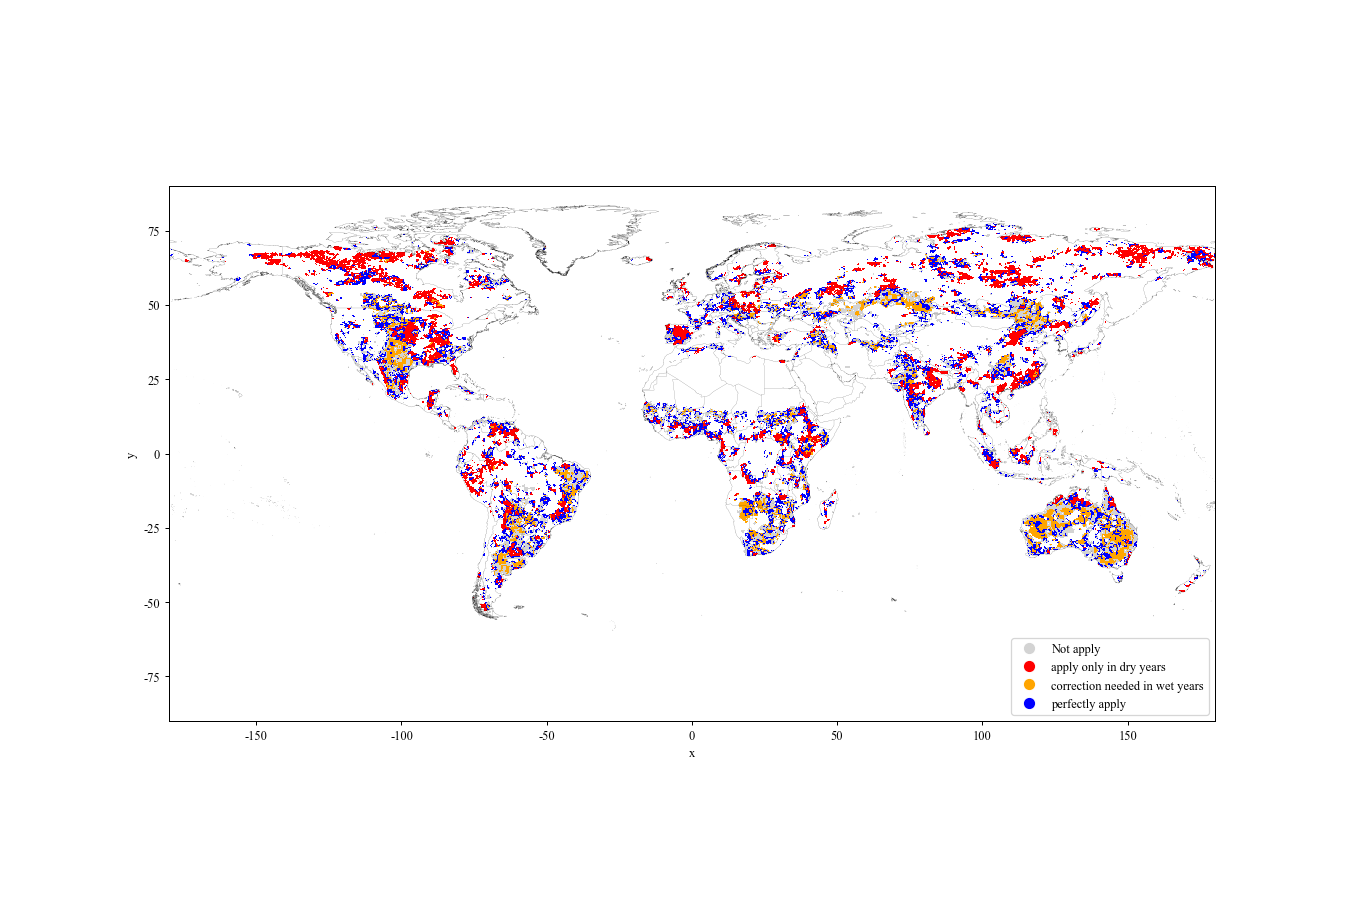

In [462]:
print("VCI适用性评价")
#这是一段未竟之事，对于VCI指标是有评价意义的，但是目前并没有做的很好，仍需要转换到月尺度去做下去
# 创建一个新数组，用于标记原始数组的情况
marked_array = np.zeros(AI_slope_CRU_025_8.shape, dtype=int)

# 使用np.where进行条件判断和标记
marked_array = np.where(np.isnan(AI_slope_CRU_025_8), 1, marked_array)  # 原始数组的值为NaN，标记为1
marked_array = np.where(AI_slope_CRU_025_8 == -1, 2, marked_array)  # 原始数组的值为-1，标记为2
marked_array = np.where((np.abs(AI_slope_CRU_025_8) >= 0.1) & (np.abs(array) <= 1), 3, marked_array)  # 原始数组的值的绝对值在0.1到1之间，标记为3
marked_array = np.where(np.abs(AI_slope_CRU_025_8) < 0.1, 4, marked_array)  # 原始数组的值的绝对值小于0.1，标记为4


cnm1= np.arange(-180, 0 , 0.25)
cnm2= np.arange( 0.25 , 180.25,0.25)
cnmd=np.concatenate((cnm1,cnm2))
cnm11= np.arange(90, 0 , -0.25)
cnm22= np.arange(- 0.25 , -90.25,-0.25)
cnmdd=np.concatenate((cnm11,cnm22))
VCI_shiyixing = xr.DataArray(marked_array, dims=['y','x'], coords=[cnmdd,cnmd])

# 创建颜色映射,1代表空值,完全不适用(白色),2代表仅干旱年适用(用红色),3代表湿润年需要校正(橙色),4代表完全适用(蓝色)
cmap = mcolors.ListedColormap(['#D3D3D3', 'white', 'red', 'orange','blue'])
bounds = [-0.5,0.5, 1.2, 2.5, 3.5, 4.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(15, 10))
world = gpd.read_file('D:/JYQ_data/JYQ/世界地图/world_line/new_world_line.shp')
world.plot(ax=ax,color='black', linewidth=0.1)
VCI_shiyixing.plot(ax=ax, cmap=cmap, norm=norm,add_colorbar=False)
# 添加图例
legend_labels = {1: 'Not apply', 2: 'apply only in dry years', 3: 'correction needed in wet years', 4: 'perfectly apply'}
legend_colors = {1: '#D3D3D3', 2: 'red', 3: 'orange', 4: 'blue'}
patches = [plt.Line2D([0], [0], marker='o', color='w', label=legend_labels[k], markersize=10, markerfacecolor=v) for k, v in legend_colors.items()]
plt.legend(handles=patches, loc='lower right')
# plt.savefig(r'D:\BaiduSyncdisk\结果\照片\VCI适宜性评价.png', dpi=1500, bbox_inches='tight')
plt.show()